# Utils

In [1]:
import os
import pandas as pd
from datetime import datetime
import numpy as np

RESULTS_FILE = "model_results_log.csv"

# generated by chatgpt
def log_result(
    model_name,
    params,
    mean_score,
    std_score=None,
    notes=None
):
    """
    Append a single experiment result to a CSV log.
    """
    row = {
        "timestamp": datetime.now().isoformat(timespec="seconds"),
        "model": model_name,
        "params": str(params),
        "mean_f1_macro": mean_score,
        "std_f1_macro": std_score,
        "notes": notes
    }

    df_row = pd.DataFrame([row])

    if os.path.exists(RESULTS_FILE):
        df_row.to_csv(RESULTS_FILE, mode="a", header=False, index=False)
    else:
        df_row.to_csv(RESULTS_FILE, mode="w", header=True, index=False)

    print(f"✔ Logged result for {model_name}")

# Data Rules

In [2]:
def apply_rules(y_pred_probs, X_subset, classes):
    """
    Rule:
    - If patient expired (discharge_disposition_id in {11,19,20,21}),
      override prediction to 'NO'.

    X_subset: the feature DataFrame for the same rows as y_pred_probs
              (used to read one-hot discharge columns).
    classes: model.classes_ (order of columns in predict_proba)
    """
    y_pred_probs_adjusted = y_pred_probs.copy()

    # expired one-hot columns (safe if some are missing)
    EXPIRED_OHE_COLS = [
        "discharge_disposition_id_11",
        "discharge_disposition_id_19",
        "discharge_disposition_id_20",
        "discharge_disposition_id_21", 
    ]
    is_expired = (
        X_subset.reindex(columns=EXPIRED_OHE_COLS, fill_value=0)
                .sum(axis=1)
                .to_numpy()
                .astype(bool)
    )

    # find which column corresponds to label "NO"
    classes = np.array(classes)
    no_idx = np.where(classes == "NO")[0][0]

    # force NO prob = 1.0 for expired rows
    y_pred_probs_adjusted[is_expired] = 0.0
    y_pred_probs_adjusted[is_expired, no_idx] = 1.0

    return y_pred_probs_adjusted


def apply_rules_labels(y_pred, X_subset):
    """
    Same rule as apply_rules, but works on predicted labels.
    """
    y_pred = np.array(y_pred, dtype=object).copy()

    EXPIRED_OHE_COLS = [
        "discharge_disposition_id_11",
        "discharge_disposition_id_19",
        "discharge_disposition_id_20",
        "discharge_disposition_id_21",
    ]
    is_expired = (
        X_subset.reindex(columns=EXPIRED_OHE_COLS, fill_value=0)
                .sum(axis=1)
                .to_numpy()
                .astype(bool)
    )
    y_pred[is_expired] = "NO"
    return y_pred

In [3]:
from sklearn.base import clone
from sklearn.metrics import f1_score, balanced_accuracy_score
from sklearn.model_selection import StratifiedGroupKFold


def cross_validate_with_rules(model, X, y_str, groups, scoring, return_train_score=False, n_splits=10, random_state=42):
    """
    Like cross_validate, but applies apply_rules(...) on predict_proba outputs.
    Uses StratifiedGroupKFold to ensure same patient doesn't appear in train and test.
    Works with both regular models and Pipeline objects.
    
    Parameters:
    -----------
    model : estimator or Pipeline
        The model/pipeline to train
    X : DataFrame
        Features (should NOT contain patient_nbr or target column)
    y_str : Series
        Target variable ('readmitted' column)
    groups : array-like
        Patient identifiers (patient_nbr) for grouping
    scoring : dict
        Dictionary of scoring metrics
    return_train_score : bool, default=False
        Whether to compute training scores
    n_splits : int, default=10
        Number of folds for StratifiedGroupKFold
    random_state : int, default=42
        Random state for reproducibility
    """
    # Create StratifiedGroupKFold with 10 folds
    cv = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    
    results = {f"test_{k}": [] for k in scoring.keys()}
    if return_train_score:
        results.update({f"train_{k}": [] for k in scoring.keys()})

    for train_idx, test_idx in cv.split(X, y_str, groups=groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y_str.iloc[train_idx], y_str.iloc[test_idx]

        m = clone(model)
        m.fit(X_train, y_train)

        # ---- TEST ----
        if hasattr(m, "predict_proba"):
            y_pred_probs_test = m.predict_proba(X_test)
            y_pred_probs_test_adj = apply_rules(y_pred_probs_test, X_test, m.classes_)
            y_pred_test = m.classes_[np.argmax(y_pred_probs_test_adj, axis=1)]
        else:
            y_pred_test = m.predict(X_test)
            y_pred_test = apply_rules_labels(y_pred_test, X_test)

        # compute test metrics
        for name, scorer in scoring.items():
            if scorer == "accuracy":
                results[f"test_{name}"].append((y_pred_test == y_test.to_numpy()).mean())
            else:
                if name == "balanced_accuracy":
                    results[f"test_{name}"].append(balanced_accuracy_score(y_test, y_pred_test))
                elif name == "f1_macro":
                    results[f"test_{name}"].append(f1_score(y_test, y_pred_test, average="macro"))
                elif name == "f1_weighted":
                    results[f"test_{name}"].append(f1_score(y_test, y_pred_test, average="weighted"))
                else:
                    raise ValueError(f"Unsupported scoring key: {name}")
        
        if return_train_score:
            if hasattr(m, "predict_proba"):
                y_pred_probs_train = m.predict_proba(X_train)
                y_pred_probs_train_adj = apply_rules(y_pred_probs_train, X_train, m.classes_)
                y_pred_train = m.classes_[np.argmax(y_pred_probs_train_adj, axis=1)]
            else:
                y_pred_train = m.predict(X_train)
                y_pred_train = apply_rules_labels(y_pred_train, X_train)

            for name, scorer in scoring.items():
                if scorer == "accuracy":
                    results[f"train_{name}"].append((y_pred_train == y_train.to_numpy()).mean())
                else:
                    if name == "balanced_accuracy":
                        results[f"train_{name}"].append(balanced_accuracy_score(y_train, y_pred_train))
                    elif name == "f1_macro":
                        results[f"train_{name}"].append(f1_score(y_train, y_pred_train, average="macro"))
                    elif name == "f1_weighted":
                        results[f"train_{name}"].append(f1_score(y_train, y_pred_train, average="weighted"))
                    else:
                        raise ValueError(f"Unsupported scoring key: {name}")

    # convert to numpy arrays
    for k in list(results.keys()):
        results[k] = np.array(results[k], dtype=float)

    return results

# 1 Cleaning Data

#### NOTE: We will not load test data here yet to prevent any accidental leakage

In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
data_path = "../dataset/diabetic_data_training.csv"
train_df=pd.read_csv(data_path)

print("training data shape:", train_df.shape)

print("training data")
display(train_df.head())


training data shape: (91589, 50)
training data


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed,readmitted
0,149190,55629189,Caucasian,Female,[10-20),?,1,1,7,3,...,No,Up,No,No,No,No,No,Ch,Yes,>30
1,64410,86047875,AfricanAmerican,Female,[20-30),?,1,1,7,2,...,No,No,No,No,No,No,No,No,Yes,NO
2,500364,82442376,Caucasian,Male,[30-40),?,1,1,7,2,...,No,Up,No,No,No,No,No,Ch,Yes,NO
3,16680,42519267,Caucasian,Male,[40-50),?,1,1,7,1,...,No,Steady,No,No,No,No,No,Ch,Yes,NO
4,35754,82637451,Caucasian,Male,[50-60),?,2,1,2,3,...,No,Steady,No,No,No,No,No,No,Yes,>30


## 1.1 Checking Target Distribution Balance

In [5]:
less_than_30 = 0
more_than_30 = 0
not_readmitted = 0
for _, row in train_df.iterrows():
    if row["readmitted"] == "NO":
        not_readmitted += 1
    elif row["readmitted"] == ">30":
        more_than_30 += 1
    else:
        less_than_30 += 1
print("<30:", less_than_30)
print(">30:", more_than_30)
print("NO:", not_readmitted)

<30: 10245
>30: 31989
NO: 49355


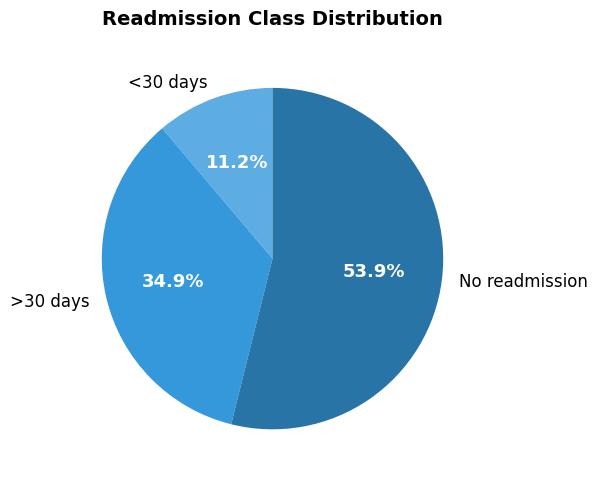

In [6]:
import matplotlib.pyplot as plt

# gpt generated

class_counts = train_df['readmitted'].value_counts().sort_index()
labels = ['<30 days', '>30 days', 'No readmission']  
values = class_counts.values

colors = ['#5dade2', '#3498db', '#2874a6'] 

fig, ax = plt.subplots(figsize=(6, 6))

wedges, texts, autotexts = ax.pie(
    values, 
    labels=labels, 
    colors=colors, 
    autopct='%1.1f%%',
    startangle=90,
    textprops={'fontsize': 12}
)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(13)
ax.set_title('Readmission Class Distribution', fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.savefig('class_distribution.pdf', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

#### This means we an have uneven split of 1 : 3 : 5 and we have moderate class imbalance. This means we must be careful to make a balanced train - validation split. Also, when testing the performance of models, we must make sure to check for recall of the "<30" class to see if the model is catching that.

## 1.2. Train - Validation Split

#### We use the stratify option to ensure that the target variable distributions are the same in the train and val sets. We will use k-folds so nothing becessary to be done here yet

## 1.3. Missing Values

#### Some columns have a lot of values missing. For those, with missing values >70%, we could drop them as they are likely noise (and we can't really fill the values in with median / mode). However, what could potentially better is that we use a binary indicator, as a presence of a measurement can be a signal.

In [7]:
train_df = train_df.replace('?', np.nan)

missing_column_fraction = (train_df.isnull().sum() / len(train_df))

very_high_missing = missing_column_fraction[missing_column_fraction > 0.7].index.tolist()
high_missing = missing_column_fraction[(missing_column_fraction > 0.2) & (missing_column_fraction <= 0.7)].index.tolist()
low_missing = missing_column_fraction[(missing_column_fraction > 0) & (missing_column_fraction <= 0.2)].index.tolist()
no_missing = missing_column_fraction[missing_column_fraction == 0].index.tolist()

print("Very high missing (>0.7)", very_high_missing)
print("High missing (0.7 > x > 0.2)", high_missing)
print("Low missing (0.2 > x > 0)", low_missing)
print("No missing", no_missing)

Very high missing (>0.7) ['weight', 'max_glu_serum', 'A1Cresult']
High missing (0.7 > x > 0.2) ['payer_code', 'medical_specialty']
Low missing (0.2 > x > 0) ['race', 'diag_1', 'diag_2', 'diag_3']
No missing ['encounter_id', 'patient_nbr', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed', 'readmitted']


In [8]:
# Because A1Cresult and max_glu_serum have significant medical relevance, we will keep the values even though a lot are missing. Explained in section 3.1.3
very_high_missing.remove("A1Cresult")
very_high_missing.remove("max_glu_serum")

train_df['A1Cresult_not_recorded'] = train_df['A1Cresult'].isna().astype(int)
train_df['max_glu_serum_not_recorded'] = train_df['max_glu_serum'].isna().astype(int)

mapping_A1C = {
    'Norm': 1,
    '>7': 2,
    '>8': 3
}

mapping_glu = {
    'Norm': 1,
    '>200': 2,
    '>300': 3
}

train_df['A1Cresult_recorded'] = train_df['A1Cresult'].map(mapping_A1C).fillna(0).astype(int)
train_df['max_glu_serum_recorded'] = train_df['max_glu_serum'].map(mapping_glu).fillna(0).astype(int)
train_df.drop(columns=["A1Cresult"], inplace=True)
train_df.drop(columns=["max_glu_serum"], inplace=True)

In [9]:
# For Very High Missing we create a binary column, whether the value has been recorded or not

for col in very_high_missing:
    train_df[col] = 1 - train_df[col].isnull().astype(int)
    train_df = train_df.rename(columns={col: f"is_{col}_recorded"})


# For High Missing we can create a new class of "Unknown", we don't need to create a seperate column to flag this is weird, as it will be
# correlated
for col in high_missing:
    train_df[col] = train_df[col].fillna("Unknown")


# For Low Missing we can reaplce with a median for numerical values, mode for non-numerical. For race, mode is reasonable because there 
# aren't many options, however, for daignoses we could do a new category unknown to not distort the distribution too much. 
for col in ["diag_1", "diag_2", "diag_3"]:
    train_df[col] = train_df[col].fillna("Unknown")

train_df[f'is_{col}_interpolated'] = train_df[col].isnull().astype(int)
train_df["race"] = train_df["race"].fillna(train_df["race"].mode()[0])


## 1.4. Making sense of the Data

In [10]:
# We can drop columns like encounter_id - we can see in the feature table that they are not classified as features. patient_nbr should not be
# dropped, as it will be used for grouping folds (some patients come to the hospital more times and we need them in the same fold to avoid leakage) 
# dropped as it 
train_df = train_df.drop("encounter_id", axis=1)

In [11]:
# Since age is actually an ordered column we will take the midpoint value 
def age_parser(age_string):
    bounds = age_string.strip("[]()").split("-")
    return (int(bounds[0]) + int(bounds[1])) // 2
train_df["age"] = train_df["age"].apply(lambda x: age_parser(x))


In [12]:
# If we check the IDS_mapping file we can see that the data in columns admission_type_id, discharge_disposition_id, admission_source_id
# shouldn't be ordered integers but strings - so we change them to strings and then do one-hot encoding
train_df["admission_type_id"] = train_df["admission_type_id"].astype(str)
train_df["admission_source_id"] = train_df["admission_source_id"].astype(str)
train_df["discharge_disposition_id"] = train_df["discharge_disposition_id"].astype(str)

In [13]:
int_cols = train_df.select_dtypes(include=['int', 'int64', 'int32']).columns.tolist()
print(int_cols)

['patient_nbr', 'age', 'is_weight_recorded', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'A1Cresult_not_recorded', 'max_glu_serum_not_recorded', 'A1Cresult_recorded', 'max_glu_serum_recorded', 'is_diag_3_interpolated']


## 1.5. Encoding into Numerical Values

#### Most models need numerical values so for columns with multiple options we can encode as binaries. However, we have to make sure we don't get an explosion of features. Hence we will use top N version of One-Hot-Encoding -> we will only do binary flags for most common N options

In [14]:
column_values = {}
for column in train_df.columns:
    unique_values = set(train_df[column])
    column_values[column] = unique_values
column_values

{'patient_nbr': {33947649,
  92667906,
  83623941,
  128319494,
  40763403,
  2752524,
  72351756,
  89391123,
  87031827,
  86507541,
  43515927,
  16121880,
  41287707,
  24117282,
  39583782,
  7471143,
  152698919,
  32899113,
  85196844,
  82968624,
  36438066,
  121372727,
  4849722,
  60031035,
  53870652,
  2621502,
  41287743,
  92274750,
  1835073,
  41680962,
  185991233,
  90701892,
  786501,
  57147462,
  64618560,
  24772680,
  95551560,
  87162957,
  88080462,
  44171343,
  38535246,
  67240017,
  43515990,
  9961560,
  61997148,
  112197726,
  111018078,
  59113566,
  5898339,
  112197735,
  23199849,
  47710314,
  24772716,
  21889134,
  96600177,
  2359413,
  20447352,
  102498426,
  524412,
  92536965,
  19136646,
  135,
  22937733,
  84410505,
  97648776,
  23724171,
  102236301,
  76021902,
  110231694,
  45613197,
  43909263,
  70254738,
  36044946,
  44957844,
  69992595,
  42074262,
  67633299,
  38011032,
  48758931,
  13107357,
  91357344,
  52297893,
  432554

In [15]:
# We first check whether columns are actually consistent - like having a column with 99% integers, 1% unknown or something would be annoying 
# in processing

result = []

for col in train_df.columns:
    series = train_df[col]
    total = len(series)
    numeric_count = series.apply(lambda x: isinstance(x, (int, float, np.integer, np.floating)) and not pd.isnull(x)).sum()
    string_count = series.apply(lambda x: isinstance(x, str)).sum()

    result.append({
        'Column': col,
        'Total': total,
        'Numeric': numeric_count,
        'String': string_count,
        'Type Breakdown': f"Strings: {string_count}, Numerics: {numeric_count}"
    })

breakdown_df = pd.DataFrame(result)
print(breakdown_df)


                        Column  Total  Numeric  String  \
0                  patient_nbr  91589    91589       0   
1                         race  91589        0   91589   
2                       gender  91589        0   91589   
3                          age  91589    91589       0   
4           is_weight_recorded  91589    91589       0   
5            admission_type_id  91589        0   91589   
6     discharge_disposition_id  91589        0   91589   
7          admission_source_id  91589        0   91589   
8             time_in_hospital  91589    91589       0   
9                   payer_code  91589        0   91589   
10           medical_specialty  91589        0   91589   
11          num_lab_procedures  91589    91589       0   
12              num_procedures  91589    91589       0   
13             num_medications  91589    91589       0   
14           number_outpatient  91589    91589       0   
15            number_emergency  91589    91589       0   
16            

In [16]:
# Now we see that we have consistent - either all-strings or all-integer columns. Now we can do the top N encoding where necessary.
# We just the value that would capture 90% of the data, 10% is "Other"

for col in train_df.columns:
    if train_df[col].dtype == 'object':
        freq_dict = train_df[col].value_counts().nlargest(500).to_dict()
        if len(freq_dict) > 10:
            print(f"Column: {col}")
            print(freq_dict)
            print("\n")

Column: discharge_disposition_id
{'1': 54187, '3': 12607, '6': 11589, '18': 3341, '2': 1893, '22': 1791, '11': 1475, '5': 1071, '25': 882, '4': 738, '7': 557, '23': 380, '13': 346, '14': 341, '28': 130, '8': 98, '15': 59, '24': 42, '9': 19, '17': 12, '16': 9, '19': 7, '10': 6, '27': 4, '12': 3, '20': 2}


Column: admission_source_id
{'7': 51839, '1': 26563, '17': 6099, '4': 2837, '6': 2035, '2': 982, '5': 759, '3': 172, '20': 147, '9': 115, '8': 15, '22': 12, '10': 8, '14': 2, '25': 2, '11': 1, '13': 1}


Column: payer_code
{'Unknown': 36247, 'MC': 29160, 'HM': 5658, 'SP': 4522, 'BC': 4167, 'MD': 3193, 'CP': 2281, 'UN': 2209, 'CM': 1737, 'OG': 930, 'PO': 530, 'DM': 490, 'CH': 132, 'WC': 126, 'OT': 83, 'MP': 70, 'SI': 53, 'FR': 1}


Column: medical_specialty
{'Unknown': 44992, 'InternalMedicine': 13191, 'Emergency/Trauma': 6808, 'Family/GeneralPractice': 6711, 'Cardiology': 4776, 'Surgery-General': 2783, 'Nephrology': 1445, 'Orthopedics': 1287, 'Orthopedics-Reconstructive': 1109, 'Radio

#### Domain Useful Knowledge

In [17]:
# ICD - diagnosis IDs - our idea was to just use the most common ones and the rest into other bucket (top N encoding)
# But then we also found in literature https://pmc.ncbi.nlm.nih.gov/articles/PMC3996476/pdf/BMRI2014-781670.pdf that
# we can group the diagnoses into 9 seperate groups - also by looking at the actual meaning od ICD
# Circulatory 390–459, 785 
# Respiratory 460–519, 786 
# Digestive 520–579, 787 
# Diabetes 250.xx 5,747 
# Injury 800–999 4,697 
# Musculoskeletal 710–739 
# Genitourinary 580–629, 788 
# Neoplasms 140–239 
# Other

In [18]:
diag_dict = (
    {a: "Circulatory" for a in range(390, 460)} |
    {785: "Circulatory"} |
    {b: "Respiratory" for b in range(460, 520)} |
    {786: "Respiratory"} |
    {c: "Digestive" for c in range(520, 580)} |
    {787: "Digestive"} |
    {250: "Diabetes"} |
    {d: "Injury" for d in range(800, 1000)} |
    {e: "Musculoskeletal" for e in range(710, 740)} |
    {f: "Genitourinary" for f in range(580, 630)} |
    {788: "Genitourinary"} |
    {g: "Neoplasms" for g in range(140, 240)} |
    {0: "Other"}
)

In [19]:
def is_int_convertible(string):
    try:
        int(string)
        return True
    except (ValueError, TypeError):
        return False

def diag_funct(diag_code):
    if is_int_convertible(diag_code):
        return int(diag_code)
    else:
        return 0

def map_funct(int_code):
    if int_code in diag_dict.keys():
        return diag_dict[int_code]
    else:
        return diag_dict[0]

train_df['diag_1'] = train_df['diag_1'].apply(diag_funct)
train_df['diag_2'] = train_df['diag_2'].apply(diag_funct)
train_df['diag_3'] = train_df['diag_3'].apply(diag_funct)

train_df['diag_1'] = train_df['diag_1'].apply(map_funct)
train_df['diag_2'] = train_df['diag_2'].apply(map_funct)
train_df['diag_3'] = train_df['diag_3'].apply(map_funct)

In [20]:
# Discharge disposition ID and Admission_source_ID are clinically important - we can see in the feature table they have meaning,
# here certain minority classes mean that, for example, the patient is deceased. As such we use all of them. Similar reasoning was also
# employed in a paper conducting a similar investigation to ours (10.21037/jmai-24-70)

In [21]:
# Function to take first N so that captures X% of the data, however, some will have all encodings (discharge_disposition_id, admission_source_id)
ENCODE_ALL = ['diag_1', 'diag_2', 'diag_3', 'discharge_disposition_id', 'admission_source_id']
def get_top_n_to_cover_required_fraction(series, coverage=0.91):
    value_counts = series.value_counts()
    cumulative_frac = value_counts.cumsum() / len(series)
    top_categories = cumulative_frac[cumulative_frac <= coverage].index.tolist()
    
    return top_categories


for col in train_df.columns:
    if train_df[col].dtype == 'object' and col != "readmitted":
        if col in ENCODE_ALL:
            top_categories = train_df[col].unique().tolist()
        elif train_df[col].nunique() <= 10:
            top_categories = train_df[col].unique().tolist()
        else: 
            top_categories = get_top_n_to_cover_required_fraction(train_df[col], coverage=0.90)
            
        for value in top_categories:
            value_name = col + "_" + str(value)
            train_df[value_name] = (train_df[col] == value).astype(int)
        
        # If we have some left over, we make the Other column, meaning if we have more than 10
        if len(top_categories) < train_df[col].nunique():
            train_df[f"{col}_Other"] = (~train_df[col].isin(top_categories)).astype(int)

        # Also dropping the original not-numerical column
        train_df = train_df.drop(col, axis=1)

# We have to check if "Other" is even needed - can drop it if not
empty_cols = []
for col in train_df.columns:
    if (train_df[col] == 0).all():
        empty_cols.append(col)

train_df = train_df.drop(columns=empty_cols)  

# Also moving the target variable to the end for structure
cols = [col for col in train_df.columns if col != 'readmitted'] + ['readmitted']
train_df = train_df[cols]

/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_25815/3653311609.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[value_name] = (train_df[col] == value).astype(int)
/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_25815/3653311609.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  train_df[value_name] = (train_df[col] == value).astype(int)
/var/folders/qr/9xd6tq253fd131999hbk5ztc0000gn/T/ipykernel_25815/3653311609.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the 

In [22]:
data_path="diabetic_data_training.csv"
train_df.to_csv("clean_train_df.csv", index=False)

# 2. Feature Engineering

In [23]:
train_df = pd.read_csv("clean_train_df.csv")

### 2.0. Linear Feature Engineering + Glucose-related features

In [24]:
DIABETES_DRUG_COLS = [
    "metformin", "repaglinide", "nateglinide", "chlorpropamide", "glimepiride",
    "acetohexamide", "glipizide", "glyburide", "tolbutamide", "pioglitazone",
    "rosiglitazone", "acarbose", "miglitol", "troglitazone", "tolazamide",
    "examide", "citoglipton", "insulin", "glyburide-metformin",
    "glipizide-metformin", "glimepiride-pioglitazone", "metformin-rosiglitazone",
    "metformin-pioglitazone"
]

drug_up_cols = [col for col in train_df.columns if col.endswith('_Up') and 
                any(drug in col for drug in DIABETES_DRUG_COLS)]
drug_steady_cols = [col for col in train_df.columns if col.endswith('_Steady') and 
                any(drug in col for drug in DIABETES_DRUG_COLS)]



In [25]:
drug_interesting_cols = drug_steady_cols + drug_up_cols

### 2.1 Ablation Testing for Glucose-Related Features - Initial, nontuned implementations of logistic regression and neural nets

In [26]:
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import numpy as np

X = train_df.drop(columns=["readmitted", 'patient_nbr'])
y = LabelEncoder().fit_transform(train_df["readmitted"])

groups = train_df["patient_nbr"]
a1c_cols = [col for col in X.columns if 'A1C' in col or 'a1c' in col.lower()] # This can be changed to just leave one of the two columns in


X_with_a1c = X
X_without_a1c = X.drop(columns=a1c_cols)

lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(C=1.0, max_iter=1000,class_weight='balanced', random_state=42)) 
])

nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nn', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True))
])

# We use the 10-fold validation, stratified and grouped
gkf = StratifiedGroupKFold(n_splits=10)


print("="*60)
print("LOGISTIC REGRESSION - 10-Fold CV (Macro F1)")
print("="*60)
lr_with = cross_val_score(lr_pipeline, X_with_a1c, y, groups=groups, cv=gkf, scoring='f1_macro')
lr_without = cross_val_score(lr_pipeline, X_without_a1c, y, groups=groups, cv=gkf, scoring='f1_macro')

print(f"With A1C:    {lr_with.mean():.4f} (+/- {lr_with.std():.4f})")
print(f"Without A1C: {lr_without.mean():.4f} (+/- {lr_without.std():.4f})")
print(f"Difference:  {lr_with.mean() - lr_without.mean():.4f}\n")


print("="*60)
print("NEURAL NETWORK - 10-Fold CV (Macro F1)")
print("="*60)
nn_with = cross_val_score(nn_pipeline, X_with_a1c, y, groups=groups, cv=gkf, scoring='f1_macro')
nn_without = cross_val_score(nn_pipeline, X_without_a1c, y, groups=groups, cv=gkf, scoring='f1_macro')

print(f"With A1C:    {nn_with.mean():.4f} (+/- {nn_with.std():.4f})")
print(f"Without A1C: {nn_without.mean():.4f} (+/- {nn_without.std():.4f})")
print(f"Difference:  {nn_with.mean() - nn_without.mean():.4f}\n")

LOGISTIC REGRESSION - 10-Fold CV (Macro F1)


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

With A1C:    0.4431 (+/- 0.0045)
Without A1C: 0.4431 (+/- 0.0046)
Difference:  -0.0000

NEURAL NETWORK - 10-Fold CV (Macro F1)


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  

With A1C:    0.4075 (+/- 0.0060)
Without A1C: 0.4040 (+/- 0.0088)
Difference:  0.0035



/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  

### 2.2 Correlation of Features with Target Variable

In [27]:
## Correlation of features with each target class 
from sklearn.preprocessing import LabelEncoder

X = train_df.drop(columns=["readmitted", 'patient_nbr'])

le = LabelEncoder()
y = le.fit_transform(train_df["readmitted"])

class_names = {i: label for i, label in enumerate(le.classes_)}

# Create correlation for each class
for class_label in [0, 1, 2]:
    binary_target = (y == class_label).astype(int)
    correlations = X.corrwith(pd.Series(binary_target, index=X.index))
    
    # Sort by absolute correlation and print top 10
    top_10 = correlations.abs().sort_values(ascending=False).head(10)
    top_10_with_sign = correlations[top_10.index]
    
    print(f"\n{'='*60}")
    print(f"Top 10 Features Correlated with Readmission Class: {class_names[class_label]}")
    print(f"{'='*60}")
    print(top_10_with_sign.to_frame(name='Correlation'))


Top 10 Features Correlated with Readmission Class: <30
                             Correlation
number_inpatient                0.167601
discharge_disposition_id_22     0.074718
discharge_disposition_id_1     -0.071973
number_emergency                0.060865
number_diagnoses                0.049593
discharge_disposition_id_11    -0.045404
time_in_hospital                0.044815
discharge_disposition_id_3      0.043515
num_medications                 0.039098
discharge_disposition_id_5      0.034865

Top 10 Features Correlated with Readmission Class: >30
                             Correlation
number_inpatient                0.115931
discharge_disposition_id_11    -0.093730
number_diagnoses                0.086344
number_outpatient               0.073728
number_emergency                0.066742
admission_source_id_7           0.065587
admission_source_id_6          -0.055433
discharge_disposition_id_6      0.053895
admission_source_id_4          -0.051537
medical_specialty_Other    

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/nump

### 2.3. Multicollinearity

In [28]:
#Drop features with correlation >= 0.95. Our one-hot encoding produces collinear features, especially if the class is binary

X = train_df.drop(columns=["readmitted"])
corr_matrix = X.corr()

threshold = 0.95
to_drop = set()

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) >= threshold:
            # Drop the second feature in the pair
            to_drop.add(corr_matrix.columns[j])

print(f"Features to drop (|r| >= {threshold}): {len(to_drop)}")
print(f"\nFeatures being removed:")
for feat in sorted(to_drop):
    print(f"  - {feat}")

train_df_clean = train_df.drop(columns=list(to_drop))

print(f"\nOriginal features: {len(X.columns)}")
print(f"After removing multicollinear features: {len(train_df_clean.columns) - 1}")  # -1 for target
print(f"Features removed: {len(to_drop)}")

# Save the cleaned dataframe
train_df = train_df_clean


Features to drop (|r| >= 0.95): 16

Features being removed:
  - acarbose_Steady
  - acetohexamide_Steady
  - change_No
  - chlorpropamide_Steady
  - diabetesMed_No
  - gender_Male
  - glipizide-metformin_Steady
  - glyburide-metformin_Steady
  - metformin-pioglitazone_Steady
  - metformin-rosiglitazone_Steady
  - nateglinide_Steady
  - pioglitazone_Steady
  - rosiglitazone_Steady
  - tolazamide_Steady
  - tolbutamide_Steady
  - troglitazone_Steady

Original features: 188
After removing multicollinear features: 172
Features removed: 16


In [29]:
list(train_df.columns)

['patient_nbr',
 'age',
 'is_weight_recorded',
 'time_in_hospital',
 'num_lab_procedures',
 'num_procedures',
 'num_medications',
 'number_outpatient',
 'number_emergency',
 'number_inpatient',
 'number_diagnoses',
 'A1Cresult_not_recorded',
 'max_glu_serum_not_recorded',
 'A1Cresult_recorded',
 'max_glu_serum_recorded',
 'race_Caucasian',
 'race_AfricanAmerican',
 'race_Other',
 'race_Hispanic',
 'race_Asian',
 'gender_Female',
 'gender_Unknown/Invalid',
 'admission_type_id_1',
 'admission_type_id_2',
 'admission_type_id_3',
 'admission_type_id_6',
 'admission_type_id_4',
 'admission_type_id_5',
 'admission_type_id_8',
 'admission_type_id_7',
 'discharge_disposition_id_1',
 'discharge_disposition_id_3',
 'discharge_disposition_id_6',
 'discharge_disposition_id_2',
 'discharge_disposition_id_5',
 'discharge_disposition_id_11',
 'discharge_disposition_id_7',
 'discharge_disposition_id_25',
 'discharge_disposition_id_10',
 'discharge_disposition_id_4',
 'discharge_disposition_id_14',
 'd

### 2.4. Non-Linear Feature Engineering

In [30]:
# We do non-linear transformations on some of the best (most correlated to target) continuous features to see if they would have relevance.
# Motivation (more in report)

In [31]:
selected_features = ["age", 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_emergency', 'number_inpatient', 'number_diagnoses']

In [ ]:
## Feature Engineering: Non-linear Transformations (using correlation)
## helped generated with gpt

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import cross_val_score, StratifiedGroupKFold
from sklearn.pipeline import Pipeline
import numpy as np
import pandas as pd


selected_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 
                     'num_medications', 'number_emergency', 'number_inpatient', 'number_diagnoses']

# Create a copy of train_df to add transformed features
train_df_transformed = train_df.copy()


new_features = []
for feat in selected_features:
    train_df_transformed[f'{feat}_log'] = np.log1p(train_df_transformed[feat])
    new_features.append(f'{feat}_log')
    
    train_df_transformed[f'{feat}_sqrt'] = np.sqrt(train_df_transformed[feat])
    new_features.append(f'{feat}_sqrt')

# Prepare data
X_all = train_df_transformed.drop(columns=["readmitted", "patient_nbr"])
le = LabelEncoder()
y = le.fit_transform(train_df_transformed["readmitted"])
groups = train_df_transformed['patient_nbr']  # Group by patient
class_names = {i: label for i, label in enumerate(le.classes_)}

print("Computing correlations with target classes...")

# Compute correlation for each class (one-vs-rest)
improvements = []

for orig_feat in selected_features:
    # Get max absolute correlation across all classes for original feature
    orig_corrs = []
    for class_label in [0, 1, 2]:
        binary_target = (y == class_label).astype(int)
        corr = train_df_transformed[orig_feat].corr(pd.Series(binary_target, index=train_df_transformed.index))
        orig_corrs.append(abs(corr))
    max_orig_corr = max(orig_corrs)
    
    # Check transformations (only log and sqrt)
    transforms = [f'{orig_feat}_log', f'{orig_feat}_sqrt']
    for trans_feat in transforms:
        trans_corrs = []
        for class_label in [0, 1, 2]:
            binary_target = (y == class_label).astype(int)
            corr = train_df_transformed[trans_feat].corr(pd.Series(binary_target, index=train_df_transformed.index))
            trans_corrs.append(abs(corr))
        max_trans_corr = max(trans_corrs)
        
        improvement = max_trans_corr - max_orig_corr
        improvements.append({
            'original': orig_feat,
            'transformed': trans_feat,
            'original_max_corr': max_orig_corr,
            'transformed_max_corr': max_trans_corr,
            'improvement': improvement
        })

improvements_df = pd.DataFrame(improvements).sort_values('improvement', ascending=False)
beneficial_transforms = improvements_df[improvements_df['improvement'] > 0]['transformed'].tolist()

# Prepare feature sets (patient_nbr is dropped - used only for grouping)
X_baseline = train_df.drop(columns=["readmitted", "patient_nbr"])
groups_baseline = train_df['patient_nbr']

features_to_add = beneficial_transforms[:10]
X_with_transforms = train_df_transformed.drop(columns=["readmitted", "patient_nbr"])[list(X_baseline.columns) + features_to_add]
groups_transforms = train_df_transformed['patient_nbr']

# Models with scaling and class weighting
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('lr', LogisticRegression(
        C=1.0, 
        max_iter=1000, 
        class_weight='balanced',  # Added to handle class imbalance
        random_state=42
    ))
])

nn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('nn', MLPClassifier(
        hidden_layer_sizes=(64, 32), 
        max_iter=500, 
        random_state=42, 
        early_stopping=True
    ))
])

# Use StratifiedGroupKFold to prevent data leakage AND maintain class balance
stratified_group_kfold = StratifiedGroupKFold(n_splits=10)

# Run cross-validation with stratification and grouping
print("Running 10-fold STRATIFIED GROUP cross-validation...")
print(f"  - Prevents patient leakage (same patient in one fold only)")
print(f"  - Maintains class balance across folds")
print(f"Unique patients: {train_df['patient_nbr'].nunique()}")
print(f"Total visits: {len(train_df)}")

lr_baseline = cross_val_score(
    lr_pipeline, X_baseline, y, 
    groups=groups_baseline, 
    cv=stratified_group_kfold, 
    scoring='f1_macro'
)

lr_transforms = cross_val_score(
    lr_pipeline, X_with_transforms, y, 
    groups=groups_transforms, 
    cv=stratified_group_kfold, 
    scoring='f1_macro'
)

nn_baseline = cross_val_score(
    nn_pipeline, X_baseline, y, 
    groups=groups_baseline, 
    cv=stratified_group_kfold, 
    scoring='f1_macro'
)

nn_transforms = cross_val_score(
    nn_pipeline, X_with_transforms, y, 
    groups=groups_transforms, 
    cv=stratified_group_kfold, 
    scoring='f1_macro'
)

# Print comprehensive summary
print("\n" + "="*70)
print("FEATURE ENGINEERING SUMMARY: NON-LINEAR TRANSFORMATIONS")
print("="*70)

print("\n1. TRANSFORMATIONS CREATED:")
print(f"   - Selected {len(selected_features)} features for transformation")
print(f"   - Generated {len(new_features)} transformed features (log, sqrt)")
print(f"   - {len(beneficial_transforms)} showed positive correlation improvement")

print("\n2. TOP 10 TRANSFORMATIONS BY CORRELATION IMPROVEMENT:")
print(improvements_df.head(10).to_string(index=False))

print(f"\n3. FEATURES ADDED TO DATASET:")
print(f"   Baseline: {X_baseline.shape[1]} features")
print(f"   Enhanced: {X_with_transforms.shape[1]} features (+{len(features_to_add)})")
print(f"   Added features: {features_to_add}")

print("\n4. ABLATION TEST RESULTS (10-Fold Stratified Group CV, Macro F1):")
print("-" * 70)
print("LOGISTIC REGRESSION (with class_weight='balanced'):")
print(f"   Baseline:        {lr_baseline.mean():.4f} (± {lr_baseline.std():.4f})")
print(f"   With transforms: {lr_transforms.mean():.4f} (± {lr_transforms.std():.4f})")
print(f"   Improvement:     {(lr_transforms.mean() - lr_baseline.mean()):.4f} ({(lr_transforms.mean() - lr_baseline.mean())*100:+.2f}%)")

print("\nNEURAL NETWORK:")
print(f"   Baseline:        {nn_baseline.mean():.4f} (± {nn_baseline.std():.4f})")
print(f"   With transforms: {nn_transforms.mean():.4f} (± {nn_transforms.std():.4f})")
print(f"   Improvement:     {(nn_transforms.mean() - nn_baseline.mean()):.4f} ({(nn_transforms.mean() - nn_baseline.mean())*100:+.2f}%)")

print("\n" + "="*70)
print("5. RECOMMENDATION:")
print("="*70)
if (lr_transforms.mean() - lr_baseline.mean()) > 0.004 or (nn_transforms.mean() - nn_baseline.mean()) > 0.004:
    print("✅ KEEP transformed features (meaningful improvement ≥ 0.5%)")
    print(f"\nNext step: Add these features to your final training dataset:")
    print(f"   {features_to_add}")
else:
    print("❌ SKIP transformed features (negligible improvement < 0.5%)")
    print("\nConclusion: Neural networks and kernel methods can learn these")
    print("non-linearities automatically. Not worth the added complexity.")
print("="*70)

Computing correlations with target classes...
Running 10-fold STRATIFIED GROUP cross-validation...
  - Prevents patient leakage (same patient in one fold only)
  - Maintains class balance across folds
Unique patients: 65932
Total visits: 91589


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


FEATURE ENGINEERING SUMMARY: NON-LINEAR TRANSFORMATIONS

1. TRANSFORMATIONS CREATED:
   - Selected 7 features for transformation
   - Generated 14 transformed features (log, sqrt)
   - 10 showed positive correlation improvement

2. TOP 10 TRANSFORMATIONS BY CORRELATION IMPROVEMENT:
        original           transformed  original_max_corr  transformed_max_corr  improvement
number_emergency  number_emergency_log           0.102315              0.132426     0.030111
number_emergency number_emergency_sqrt           0.102315              0.131681     0.029366
 num_medications   num_medications_log           0.047183              0.071369     0.024185
number_inpatient  number_inpatient_log           0.216847              0.236077     0.019230
number_inpatient number_inpatient_sqrt           0.216847              0.235809     0.018962
 num_medications  num_medications_sqrt           0.047183              0.061415     0.014232
time_in_hospital  time_in_hospital_log           0.052789        

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


In [33]:
beneficial_features = ['number_emergency_log', 'number_emergency_sqrt', 'num_medications_log', 
                       'number_inpatient_log', 'number_inpatient_sqrt', 'num_medications_sqrt', 
                       'time_in_hospital_log', 'time_in_hospital_sqrt', 'num_procedures_log', 
                       'num_procedures_sqrt']

# Create only the beneficial transformed features
for feat in beneficial_features:
    if '_log' in feat:
        orig_feat = feat.replace('_log', '')
        train_df[feat] = np.log1p(train_df[orig_feat])
    elif '_sqrt' in feat:
        orig_feat = feat.replace('_sqrt', '')
        train_df[feat] = np.sqrt(train_df[orig_feat])

In [34]:
train_df

,patient_nbr,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,number_emergency_log,number_emergency_sqrt,num_medications_log,number_inpatient_log,number_inpatient_sqrt,num_medications_sqrt,time_in_hospital_log,time_in_hospital_sqrt,num_procedures_log,num_procedures_sqrt
0,55629189,15,0,3,59,0,18,0,0,0,...,0.0,0.0,2.944439,0.000000,0.0,4.242641,1.386294,1.732051,0.000000,0.000000
1,86047875,25,0,2,11,5,13,2,0,1,...,0.0,0.0,2.639057,0.693147,1.0,3.605551,1.098612,1.414214,1.791759,2.236068
2,82442376,35,0,2,44,1,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.098612,1.414214,0.693147,1.000000
3,42519267,45,0,1,51,0,8,0,0,0,...,0.0,0.0,2.197225,0.000000,0.0,2.828427,0.693147,1.000000,0.000000,0.000000
4,82637451,55,0,3,31,6,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,1.945910,2.449490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,100162476,75,0,3,51,0,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,0.000000,0.000000
91585,74694222,85,0,5,33,3,18,0,0,1,...,0.0,0.0,2.944439,0.693147,1.0,4.242641,1.791759,2.236068,1.386294,1.732051
91586,41088789,75,0,1,53,0,9,1,0,0,...,0.0,0.0,2.302585,0.000000,0.0,3.000000,0.693147,1.000000,0.000000,0.000000
91587,31693671,85,0,10,45,2,21,0,0,1,...,0.0,0.0,3.091042,0.693147,1.0,4.582576,2.397895,3.162278,1.098612,1.414214


### 2.5 Looking at which features might have very clear patterns with a specific prediction class (like disposition_id_11 always means NO)

In [35]:
## Exploratory Analysis: Find ONLY 100% Deterministic Patterns
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Prepare data
X = train_df.drop(columns=["readmitted", "patient_nbr"])
y_labels = train_df["readmitted"]
le = LabelEncoder()
y = le.fit_transform(y_labels)
class_names = {i: label for i, label in enumerate(le.classes_)}

print("="*70)
print("FINDING 100% DETERMINISTIC PATTERNS ONLY")
print("="*70)

deterministic_patterns = []

for col in X.columns:
    if X[col].dtype in ['int64', 'float64']:
        unique_vals = X[col].unique()
        
        for val in unique_vals:
            mask = (X[col] == val)
            if mask.sum() >= 5:  # At least 10 instances
                classes_for_val = y_labels[mask].unique()
                
                # Only keep if 100% deterministic (always same class)
                if len(classes_for_val) == 1:
                    count = mask.sum()
                    deterministic_patterns.append({
                        'feature': col,
                        'value': val,
                        'always_predicts': classes_for_val[0],
                        'count': count,
                        'percentage_of_dataset': count / len(X) * 100
                    })

print(f"\nFound {len(deterministic_patterns)} 100% deterministic patterns:\n")

if deterministic_patterns:
    det_df = pd.DataFrame(deterministic_patterns).sort_values('count', ascending=False)
    print(det_df.to_string(index=False))
    
    print("\n" + "="*70)
    print("SUMMARY")
    print("="*70)
    print(f"Total patterns where feature=value → ALWAYS same class: {len(deterministic_patterns)}")
    print("\nThese are candidates for rule-based overrides if clinically justified.")
else:
    print("No 100% deterministic patterns found.")

FINDING 100% DETERMINISTIC PATTERNS ONLY

Found 6 100% deterministic patterns:

                    feature     value always_predicts  count  percentage_of_dataset
discharge_disposition_id_11  1.000000              NO   1475               1.610455
        admission_type_id_7  1.000000              NO     18               0.019653
           number_inpatient 15.000000             <30      9               0.009827
       number_inpatient_log  2.772589             <30      9               0.009827
      number_inpatient_sqrt  3.872983             <30      9               0.009827
discharge_disposition_id_19  1.000000              NO      7               0.007643

SUMMARY
Total patterns where feature=value → ALWAYS same class: 6

These are candidates for rule-based overrides if clinically justified.


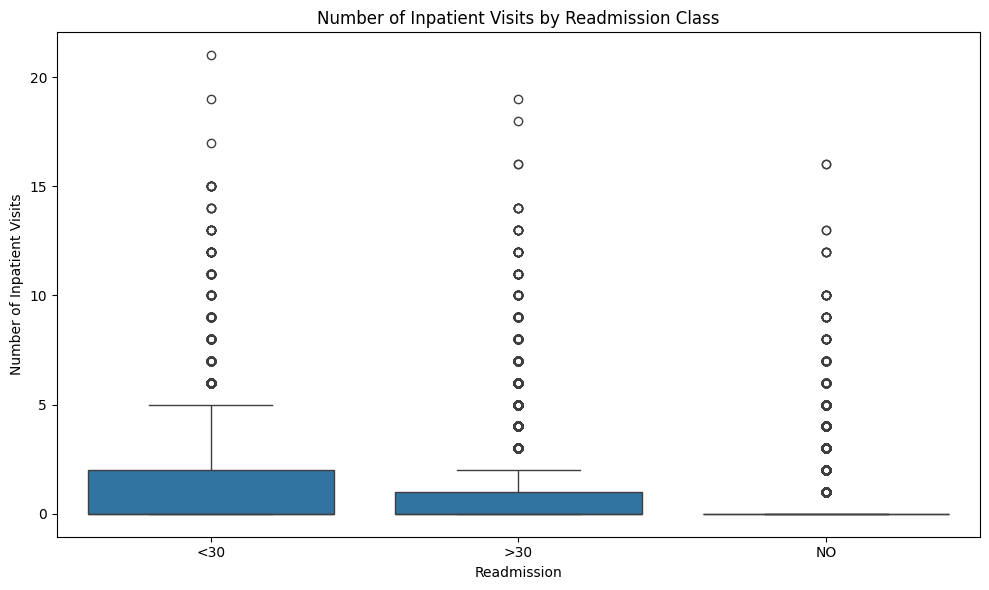

Readmission for patients with high inpatient visits:

>= 10 visits (178 patients):
readmitted
<30    98
>30    63
NO     17
Name: count, dtype: int64

>= 11 visits (122 patients):
readmitted
<30    73
>30    41
NO      8
Name: count, dtype: int64

>= 12 visits (76 patients):
readmitted
<30    41
>30    27
NO      8
Name: count, dtype: int64

>= 13 visits (45 patients):
readmitted
<30    25
>30    16
NO      4
Name: count, dtype: int64

>= 14 visits (27 patients):
readmitted
<30    16
>30     9
NO      2
Name: count, dtype: int64

>= 15 visits (18 patients):
readmitted
<30    12
>30     4
NO      2
Name: count, dtype: int64


In [36]:
# Plot number_inpatient by readmission class
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(data=train_df, x='readmitted', y='number_inpatient', order=['<30', '>30', 'NO'])
plt.title('Number of Inpatient Visits by Readmission Class')
plt.xlabel('Readmission')
plt.ylabel('Number of Inpatient Visits')
plt.tight_layout()
plt.show()

# Also show value counts for high inpatient visits
print("Readmission for patients with high inpatient visits:")
for val in [10, 11, 12, 13, 14, 15]:
    mask = train_df['number_inpatient'] >= val
    if mask.sum() > 0:
        print(f"\n>= {val} visits ({mask.sum()} patients):")
        print(train_df[mask]['readmitted'].value_counts())

### 2.6. Final Feature Selection

In [37]:
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import LabelEncoder
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

X = train_df.drop(columns=["readmitted", "patient_nbr"])
y = LabelEncoder().fit_transform(train_df["readmitted"])

print("="*70)
print("ZERO-VARIANCE FEATURES")
print("="*70)
print(f"\nTotal features: {X.shape[1]}")

var_selector = VarianceThreshold(threshold=0)
var_selector.fit(X)

zero_variance_features = X.columns[~var_selector.get_support()]

print(f"\nZero-variance features found: {len(zero_variance_features)}")
print("\nFeatures to remove:")
for feat in zero_variance_features:
    print(f"  - {feat}")

ZERO-VARIANCE FEATURES

Total features: 181

Zero-variance features found: 3

Features to remove:
  - examide_No
  - citoglipton_No
  - glimepiride-pioglitazone_No


In [38]:
train_df

,patient_nbr,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,number_emergency_log,number_emergency_sqrt,num_medications_log,number_inpatient_log,number_inpatient_sqrt,num_medications_sqrt,time_in_hospital_log,time_in_hospital_sqrt,num_procedures_log,num_procedures_sqrt
0,55629189,15,0,3,59,0,18,0,0,0,...,0.0,0.0,2.944439,0.000000,0.0,4.242641,1.386294,1.732051,0.000000,0.000000
1,86047875,25,0,2,11,5,13,2,0,1,...,0.0,0.0,2.639057,0.693147,1.0,3.605551,1.098612,1.414214,1.791759,2.236068
2,82442376,35,0,2,44,1,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.098612,1.414214,0.693147,1.000000
3,42519267,45,0,1,51,0,8,0,0,0,...,0.0,0.0,2.197225,0.000000,0.0,2.828427,0.693147,1.000000,0.000000,0.000000
4,82637451,55,0,3,31,6,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,1.945910,2.449490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,100162476,75,0,3,51,0,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,0.000000,0.000000
91585,74694222,85,0,5,33,3,18,0,0,1,...,0.0,0.0,2.944439,0.693147,1.0,4.242641,1.791759,2.236068,1.386294,1.732051
91586,41088789,75,0,1,53,0,9,1,0,0,...,0.0,0.0,2.302585,0.000000,0.0,3.000000,0.693147,1.000000,0.000000,0.000000
91587,31693671,85,0,10,45,2,21,0,0,1,...,0.0,0.0,3.091042,0.693147,1.0,4.582576,2.397895,3.162278,1.098612,1.414214


In [39]:
final_clean_train_df = train_df.drop(columns=zero_variance_features)

In [40]:
final_clean_train_df

,patient_nbr,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,number_emergency_log,number_emergency_sqrt,num_medications_log,number_inpatient_log,number_inpatient_sqrt,num_medications_sqrt,time_in_hospital_log,time_in_hospital_sqrt,num_procedures_log,num_procedures_sqrt
0,55629189,15,0,3,59,0,18,0,0,0,...,0.0,0.0,2.944439,0.000000,0.0,4.242641,1.386294,1.732051,0.000000,0.000000
1,86047875,25,0,2,11,5,13,2,0,1,...,0.0,0.0,2.639057,0.693147,1.0,3.605551,1.098612,1.414214,1.791759,2.236068
2,82442376,35,0,2,44,1,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.098612,1.414214,0.693147,1.000000
3,42519267,45,0,1,51,0,8,0,0,0,...,0.0,0.0,2.197225,0.000000,0.0,2.828427,0.693147,1.000000,0.000000,0.000000
4,82637451,55,0,3,31,6,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,1.945910,2.449490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,100162476,75,0,3,51,0,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,0.000000,0.000000
91585,74694222,85,0,5,33,3,18,0,0,1,...,0.0,0.0,2.944439,0.693147,1.0,4.242641,1.791759,2.236068,1.386294,1.732051
91586,41088789,75,0,1,53,0,9,1,0,0,...,0.0,0.0,2.302585,0.000000,0.0,3.000000,0.693147,1.000000,0.000000,0.000000
91587,31693671,85,0,10,45,2,21,0,0,1,...,0.0,0.0,3.091042,0.693147,1.0,4.582576,2.397895,3.162278,1.098612,1.414214


In [41]:
final_clean_train_df.to_csv("final_clean_train_df.csv", index=False)

# Resampling?

In [42]:
final_clean_train_df = pd.read_csv("final_clean_train_df.csv")

In [43]:
final_clean_train_df

,patient_nbr,age,is_weight_recorded,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,number_emergency,number_inpatient,...,number_emergency_log,number_emergency_sqrt,num_medications_log,number_inpatient_log,number_inpatient_sqrt,num_medications_sqrt,time_in_hospital_log,time_in_hospital_sqrt,num_procedures_log,num_procedures_sqrt
0,55629189,15,0,3,59,0,18,0,0,0,...,0.0,0.0,2.944439,0.000000,0.0,4.242641,1.386294,1.732051,0.000000,0.000000
1,86047875,25,0,2,11,5,13,2,0,1,...,0.0,0.0,2.639057,0.693147,1.0,3.605551,1.098612,1.414214,1.791759,2.236068
2,82442376,35,0,2,44,1,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.098612,1.414214,0.693147,1.000000
3,42519267,45,0,1,51,0,8,0,0,0,...,0.0,0.0,2.197225,0.000000,0.0,2.828427,0.693147,1.000000,0.000000,0.000000
4,82637451,55,0,3,31,6,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,1.945910,2.449490
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
91584,100162476,75,0,3,51,0,16,0,0,0,...,0.0,0.0,2.833213,0.000000,0.0,4.000000,1.386294,1.732051,0.000000,0.000000
91585,74694222,85,0,5,33,3,18,0,0,1,...,0.0,0.0,2.944439,0.693147,1.0,4.242641,1.791759,2.236068,1.386294,1.732051
91586,41088789,75,0,1,53,0,9,1,0,0,...,0.0,0.0,2.302585,0.000000,0.0,3.000000,0.693147,1.000000,0.000000,0.000000
91587,31693671,85,0,10,45,2,21,0,0,1,...,0.0,0.0,3.091042,0.693147,1.0,4.582576,2.397895,3.162278,1.098612,1.414214


CLASS DISTRIBUTION
  <30  :  10245 (11.19%)
  >30  :  31989 (34.93%)
  NO   :  49355 (53.89%)

RUNNING EXPERIMENTS...

Logistic Regression:
  Testing none... Done (F1: 0.4471)
  Testing moderate... Done (F1: 0.4449)
  Testing aggressive... Done (F1: 0.4449)

Neural Network:
  Testing none... Done (F1: 0.4075)
  Testing moderate... Done (F1: 0.4110)
  Testing aggressive... Done (F1: 0.4110)

CONFUSION MATRICES

Saved confusion matrices to 'resampling_confusion_matrices_expanded.png'

PER-CLASS METRICS COMPARISON

Logistic Regression:
----------------------------------------------------------------------

  Class: <30
  Strategy  Precision   Recall  F1-Score
      none   0.202778 0.408980  0.271127
  moderate   0.200019 0.407028  0.268228
aggressive   0.200019 0.407028  0.268228

  Class: >30
  Strategy  Precision   Recall  F1-Score
      none   0.468505 0.398981  0.430957
  moderate   0.466101 0.399950  0.430499
aggressive   0.466101 0.399950  0.430499

  Class: NO
  Strategy  Precision

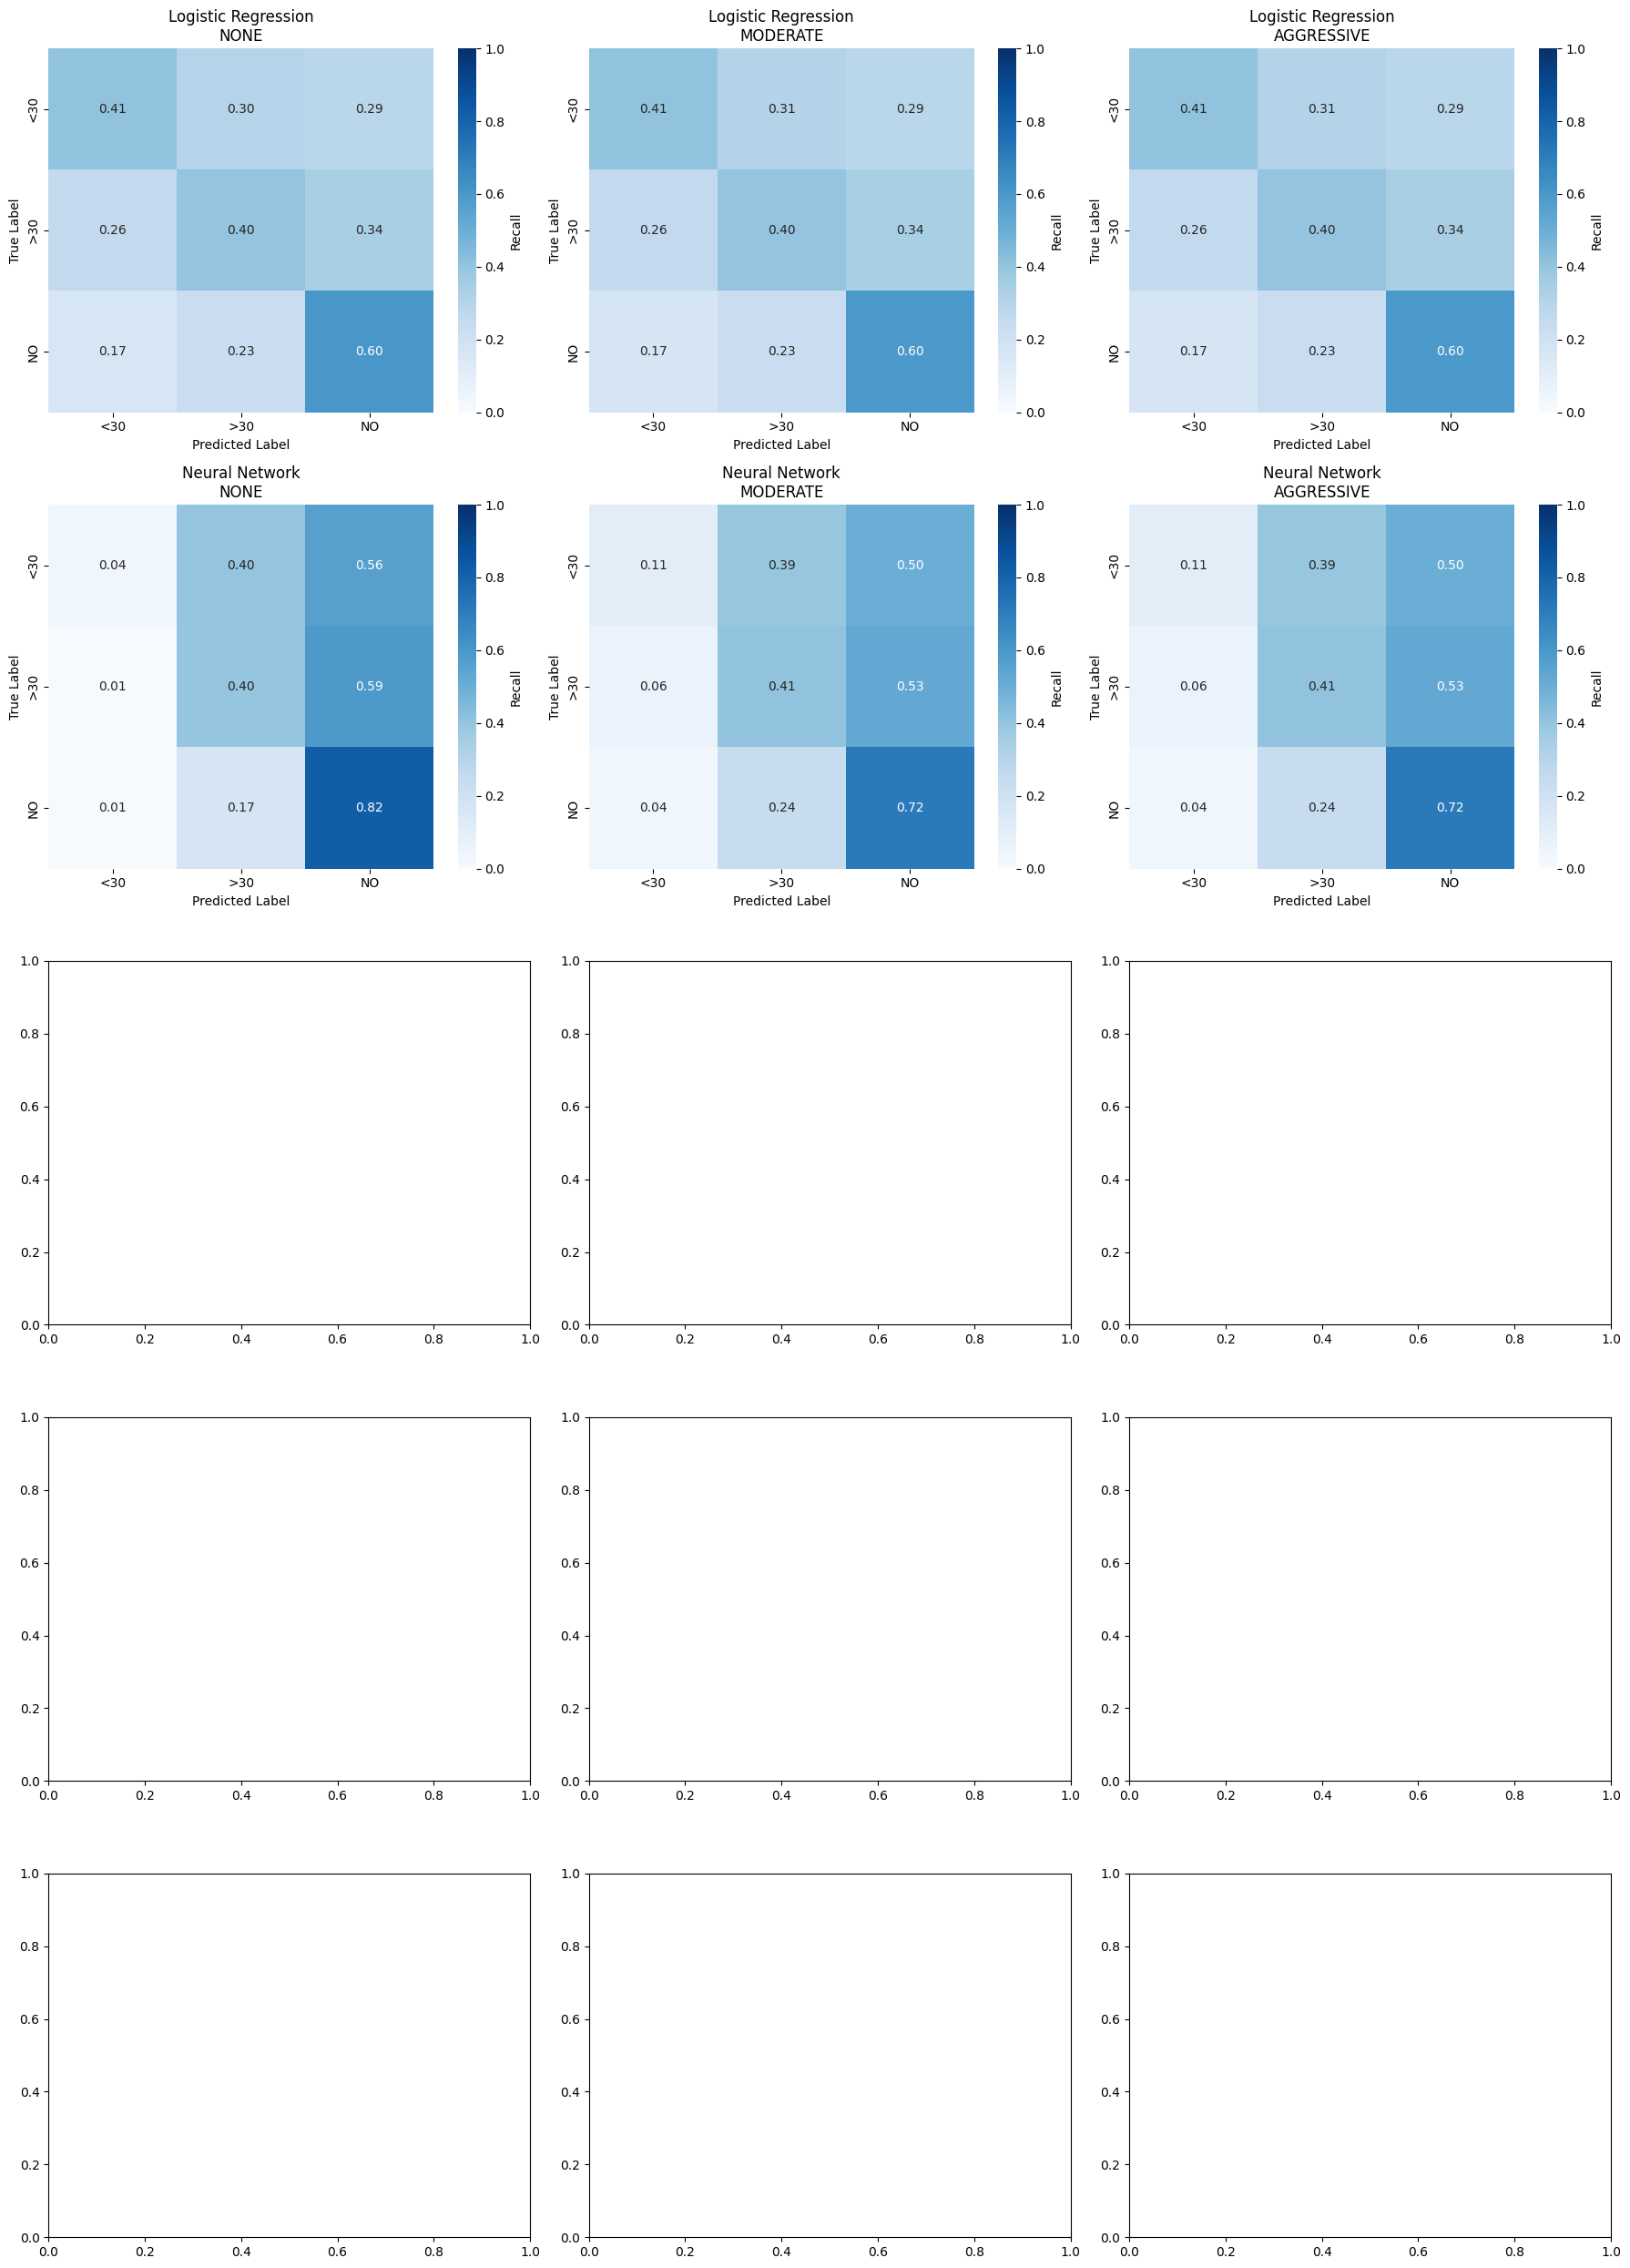

In [44]:
## Resampling Experiment with Confusion Matrices and Per-Class Metrics (Expanded)
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC, SVC
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.utils import resample
from sklearn.metrics import f1_score, confusion_matrix, classification_report
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Prepare data
X = final_clean_train_df.drop(columns=["readmitted", "patient_nbr"])
y = LabelEncoder().fit_transform(final_clean_train_df["readmitted"])
groups = final_clean_train_df['patient_nbr']

le = LabelEncoder().fit(final_clean_train_df["readmitted"])
class_names = {i: label for i, label in enumerate(le.classes_)}

print("="*70)
print("CLASS DISTRIBUTION")
print("="*70)
for i, name in class_names.items():
    count = (y == i).sum()
    pct = count / len(y) * 100
    print(f"  {name:5s}: {count:6d} ({pct:5.2f}%)")

# Function to cross-validate and collect confusion matrices
def cross_val_with_metrics(model, X, y, groups, resampling_strategy='none', n_splits=10):
    skf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=42)
    all_y_true = []
    all_y_pred = []
    
    for train_idx, val_idx in skf.split(X, y, groups):
        X_train_fold = X.iloc[train_idx].copy()
        y_train_fold = y[train_idx].copy()
        X_val_fold = X.iloc[val_idx]
        y_val_fold = y[val_idx]
        
        # Apply resampling
        if resampling_strategy != 'none':
            train_data = X_train_fold.copy()
            train_data['target'] = y_train_fold
            
            class_0 = train_data[train_data['target'] == 0]
            class_1 = train_data[train_data['target'] == 1]
            class_2 = train_data[train_data['target'] == 2]
            
            max_size = max(len(class_0), len(class_1), len(class_2))
            
            if resampling_strategy == 'moderate':
                target_size = int(max_size * 0.7)
            elif resampling_strategy == 'aggressive':
                target_size = max_size
            
            class_0_resampled = resample(class_0, n_samples=min(target_size, len(class_0)) if len(class_0) < max_size else len(class_0), 
                                         random_state=42, replace=True)
            class_1_resampled = resample(class_1, n_samples=min(target_size, len(class_1)) if len(class_1) < max_size else len(class_1), 
                                         random_state=42, replace=True)
            class_2_resampled = resample(class_2, n_samples=min(target_size, len(class_2)) if len(class_2) < max_size else len(class_2), 
                                         random_state=42, replace=True)
            
            train_resampled = pd.concat([class_0_resampled, class_1_resampled, class_2_resampled])
            X_train_fold = train_resampled.drop(columns=['target'])
            y_train_fold = train_resampled['target'].values
        
        # Scale and train
        scaler = StandardScaler()
        X_train_scaled = scaler.fit_transform(X_train_fold)
        X_val_scaled = scaler.transform(X_val_fold)
        
        model_clone = model.__class__(**model.get_params())
        model_clone.fit(X_train_scaled, y_train_fold)
        y_pred = model_clone.predict(X_val_scaled)
        
        all_y_true.extend(y_val_fold)
        all_y_pred.extend(y_pred)
    
    return np.array(all_y_true), np.array(all_y_pred)

# Models
models = [
    ('Logistic Regression', LogisticRegression(C=1.0, max_iter=1000,class_weight="balanced", random_state=42)),
    ('Neural Network', MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42, early_stopping=True))
]

strategies = ['none', 'moderate', 'aggressive']

print("\n" + "="*70)
print("RUNNING EXPERIMENTS...")
print("="*70)

# Store results
all_results = {}

for model_name, model in models:
    print(f"\n{model_name}:")
    all_results[model_name] = {}
    
    for strategy in strategies:
        print(f"  Testing {strategy}...", end=" ")
        y_true, y_pred = cross_val_with_metrics(model, X, y, groups, strategy)
        
        cm = confusion_matrix(y_true, y_pred)
        report = classification_report(y_true, y_pred, target_names=[class_names[i] for i in range(3)], 
                                       output_dict=True, zero_division=0)
        macro_f1 = f1_score(y_true, y_pred, average='macro')
        
        all_results[model_name][strategy] = {
            'cm': cm,
            'report': report,
            'macro_f1': macro_f1
        }
        print(f"Done (F1: {macro_f1:.4f})")

# Visualize confusion matrices
print("\n" + "="*70)
print("CONFUSION MATRICES")
print("="*70)

fig, axes = plt.subplots(5, 3, figsize=(18, 25))

for model_idx, (model_name, _) in enumerate(models):
    for strat_idx, strategy in enumerate(strategies):
        ax = axes[model_idx, strat_idx]
        cm = all_results[model_name][strategy]['cm']
        
        # Normalize by true labels (row-wise) to get recall
        cm_norm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
        
        sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues', ax=ax,
                   xticklabels=[class_names[i] for i in range(3)],
                   yticklabels=[class_names[i] for i in range(3)],
                   vmin=0, vmax=1, cbar_kws={'label': 'Recall'})
        
        ax.set_title(f'{model_name}\n{strategy.upper()}')
        ax.set_ylabel('True Label')
        ax.set_xlabel('Predicted Label')

plt.tight_layout()
plt.savefig('resampling_confusion_matrices_expanded.png', dpi=300, bbox_inches='tight')
print("\nSaved confusion matrices to 'resampling_confusion_matrices_expanded.png'")

# Print detailed per-class metrics
print("\n" + "="*70)
print("PER-CLASS METRICS COMPARISON")
print("="*70)

for model_name, _ in models:
    print(f"\n{model_name}:")
    print("-" * 70)
    
    # Create comparison table
    comparison = []
    for strategy in strategies:
        report = all_results[model_name][strategy]['report']
        for class_idx in range(3):
            class_label = class_names[class_idx]
            comparison.append({
                'Strategy': strategy,
                'Class': class_label,
                'Precision': report[class_label]['precision'],
                'Recall': report[class_label]['recall'],
                'F1-Score': report[class_label]['f1-score'],
                'Support': int(report[class_label]['support'])
            })
    
    comp_df = pd.DataFrame(comparison)
    
    # Show side-by-side for each class
    for class_label in ['<30', '>30', 'NO']:
        print(f"\n  Class: {class_label}")
        class_data = comp_df[comp_df['Class'] == class_label][['Strategy', 'Precision', 'Recall', 'F1-Score']]
        print(class_data.to_string(index=False))

# Summary: Focus on minority class recall
print("\n" + "="*70)
print("MINORITY CLASS RECALL IMPROVEMENT")
print("="*70)

for model_name, _ in models:
    print(f"\n{model_name}:")
    baseline_report = all_results[model_name]['none']['report']
    
    for strategy in ['moderate', 'aggressive']:
        strategy_report = all_results[model_name][strategy]['report']
        
        print(f"\n  {strategy.upper()} vs NONE:")
        for class_label in ['<30', '>30']:  # Minority classes
            baseline_recall = baseline_report[class_label]['recall']
            strategy_recall = strategy_report[class_label]['recall']
            diff = strategy_recall - baseline_recall
            
            print(f"    {class_label:5s} recall: {baseline_recall:.4f} → {strategy_recall:.4f} ({diff:+.4f})")

# Model comparison summary
print("\n" + "="*70)
print("MODEL COMPARISON - MACRO F1 SCORES")
print("="*70)

summary_data = []
for model_name, _ in models:
    for strategy in strategies:
        summary_data.append({
            'Model': model_name,
            'Strategy': strategy,
            'Macro F1': all_results[model_name][strategy]['macro_f1']
        })

summary_df = pd.DataFrame(summary_data)
summary_pivot = summary_df.pivot(index='Model', columns='Strategy', values='Macro F1')
print(summary_pivot.to_string())

# Find best configuration
best_config = summary_df.loc[summary_df['Macro F1'].idxmax()]
print(f"\nBest Configuration:")
print(f"  Model: {best_config['Model']}")
print(f"  Strategy: {best_config['Strategy']}")
print(f"  Macro F1: {best_config['Macro F1']:.4f}")

print("\n" + "="*70)
print("RECOMMENDATION")
print("="*70)
print("Check if minority class recall improved significantly (>5% gain).")
print("Even if overall F1 is similar, better recall on <30 and >30 may be valuable.")
print("Consider both macro F1 and minority class recall when selecting final model.")

# 3. Logistic Regression

In [4]:
import pandas as pd

In [5]:
df = pd.read_csv("final_clean_train_df.csv")

### Experiment 1  - Logistic with Scaling and L2
### Experiment 2  - Remove low variance features (in pipeline)
### Experiment 3 - PCA


### Note: To run a specific experiment, the correct lines in the Pipeline have to be commented out

In [9]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Prepare data
y = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

# Create Logistic Regression model
model = Pipeline(steps=[           # pipeline chains preprocessing + model into one object.
    # ("low_var", VarianceThreshold(0.01)) # to remove low-variance features  - CAN BE COMMENTED OUT FOR EXPERIMENT 1
    ("scaler", StandardScaler()),  # step 1: standardises each feature to mean 0, std 1.
    #("pca", PCA(n_components=0.95)),
    ("clf", LogisticRegression(    # step 2: train logistic regression (the classifier) on the scaled data
            solver="lbfgs",              # optimisation method (default) to find best coefficients for multinomial + L2 regularisation
            max_iter=500,                # enough iterations for convergence in a high-dimensional dataset
            class_weight="balanced",     # increases the penalty for misclassifying minority classes (reweights classes inversely proportional to their frequency)
            n_jobs=None                  # lbfgs ignores n_jobs; OK to leave
            )
    )
])

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

# Run cross-validation with business rules
print("Running 10-Fold Stratified Group Cross-Validation with Rules...")
results = cross_validate_with_rules(
    model=model,
    X=X,
    y_str=y,
    groups=patient_groups,
    scoring=scoring,
    return_train_score=True,
    n_splits=10,
    random_state=42
)

# Display results
print("\n" + "="*60)
print("LOGISTIC REGRESSION - CROSS-VALIDATION RESULTS")
print("="*60)

for metric in scoring.keys():
    test_scores = results[f'test_{metric}']
    train_scores = results[f'train_{metric}']
    
    print(f"\n{metric.upper().replace('_', ' ')}:")
    print(f"  Test:  {test_scores.mean():.4f} ± {test_scores.std():.4f}")
    print(f"  Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"  Fold scores (test): {test_scores}")

print("\n" + "="*60)



# Confusion Matrix
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
all_y_true = []
all_y_pred = []

for train_idx, test_idx in cv.split(X, y, groups=patient_groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    m = clone(model)
    m.fit(X_train, y_train)
    
    y_pred_probs = m.predict_proba(X_test)
    y_pred_probs_adj = apply_rules(y_pred_probs, X_test, m.classes_)
    y_pred = m.classes_[np.argmax(y_pred_probs_adj, axis=1)]
    
    all_y_true.extend(y_test.to_numpy())
    all_y_pred.extend(y_pred)

print("\nConfusion Matrix:")
print(confusion_matrix(np.array(all_y_true), np.array(all_y_pred)))
print("\nClassification Report:")
print(classification_report(np.array(all_y_true), np.array(all_y_pred)))

Running 10-Fold Stratified Group Cross-Validation with Rules...


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


LOGISTIC REGRESSION - CROSS-VALIDATION RESULTS

ACCURACY:
  Test:  0.5098 ± 0.0038
  Train: 0.5129 ± 0.0008
  Fold scores (test): [0.50630385 0.50871905 0.50499946 0.5104178  0.51684665 0.51698197
 0.5091922  0.50731762 0.50864745 0.50838112]

BALANCED ACCURACY:
  Test:  0.4701 ± 0.0047
  Train: 0.4746 ± 0.0004
  Fold scores (test): [0.47180497 0.4678239  0.47105315 0.47889503 0.47543963 0.47376812
 0.46334038 0.46562133 0.46558176 0.46775821]

F1 MACRO:
  Test:  0.4470 ± 0.0038
  Train: 0.4508 ± 0.0005
  Fold scores (test): [0.44684581 0.44516323 0.44691718 0.44995163 0.4540852  0.45202655
 0.44208291 0.44222186 0.44418727 0.44683746]

F1 WEIGHTED:
  Test:  0.5253 ± 0.0037
  Train: 0.5283 ± 0.0006
  Fold scores (test): [0.52207039 0.52572297 0.52075411 0.52614369 0.53240851 0.53103091
 0.52561874 0.52134729 0.52399133 0.5238484 ]



/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


Confusion Matrix:
[[ 4190  3085  2970]
 [ 8248 12763 10978]
 [ 8225 11394 29736]]

Classification Report:
              precision    recall  f1-score   support

         <30       0.20      0.41      0.27     10245
         >30       0.47      0.40      0.43     31989
          NO       0.68      0.60      0.64     49355

    accuracy                           0.51     91589
   macro avg       0.45      0.47      0.45     91589
weighted avg       0.55      0.51      0.53     91589



/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### Experiment 4  - Testing for Multicollinearity?

In [ ]:
### If decide yes, then run this before the pipeline and add that line into the scaler

In [ ]:
from sklearn.base import BaseEstimator, TransformerMixin

class CorrelationFilter(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.9):
        self.threshold = threshold

    def fit(self, X, y=None):
        corr = X.corr().abs()
        upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
        self.to_drop_ = [
            col for col in upper.columns
            if any(upper[col] > self.threshold)
        ]
        return self

    def transform(self, X):
        return X.drop(columns=self.to_drop_, errors="ignore")


In [ ]:
("corr_filter", CorrelationFilter(0.9)),  

# 3. Logistic Regression with Polynomial Features

In [ ]:
df = pd.read_csv("final_clean_train_df.csv")

In [ ]:
# Same code as for logistic, just with an additional preprocessor step - we will try

In [15]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.decomposition import PCA
from sklearn.compose import ColumnTransformer
from sklearn.feature_selection import VarianceThreshold

# Prepare data
y = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

var_threshold = VarianceThreshold(threshold=0.01)
X_high_var = var_threshold.fit_transform(X)

high_var_columns = X.columns[var_threshold.get_support()].tolist()
X_filtered = X[high_var_columns]  # THIS is what we'll use!

### Testing Which Features are not one-hot encoded
unique_counts = X_filtered.nunique()
not_one_hot = unique_counts[unique_counts >= 3]
not_one_hot_columns = not_one_hot.index.tolist()
one_hot_columns = [col for col in X_filtered.columns if col not in not_one_hot_columns]

print(f"Total features: {len(X_filtered.columns)}")
print(f"Non-one-hot features: {len(not_one_hot_columns)}")
print(f"One-hot features: {len(one_hot_columns)}")

# Create preprocessing with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('poly', PolynomialFeatures(degree=3, include_bias=False), not_one_hot_columns),  # FIX: use the list
        ('passthrough', 'passthrough', one_hot_columns)
    ],
    remainder='drop'
)

# Create Logistic Regression model with polynomial features
model = Pipeline(steps=[
    ("poly_features", preprocessor),
    ("scaler", StandardScaler()),
    #("pca", PCA(n_components=0.95)),
    ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=500,
            class_weight="balanced",
            n_jobs=None
            )
    )
])

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

# Run cross-validation with rules
print("Running 10-Fold Stratified Group Cross-Validation with Polynomial Features...")
results = cross_validate_with_rules(
    model=model,
    X=X_filtered,  # FIX: use X_filtered, not X!
    y_str=y,
    groups=patient_groups,
    scoring=scoring,
    return_train_score=True,
    n_splits=10,
    random_state=42
)

# Display results
print("\n" + "="*60)
print("LOGISTIC REGRESSION WITH POLYNOMIAL FEATURES - CROSS-VALIDATION RESULTS")
print("="*60)

for metric in scoring.keys():
    test_scores = results[f'test_{metric}']
    train_scores = results[f'train_{metric}']
    
    print(f"\n{metric.upper().replace('_', ' ')}:")
    print(f"  Test:  {test_scores.mean():.4f} ± {test_scores.std():.4f}")
    print(f"  Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"  Fold scores (test): {test_scores}")

print("\n" + "="*60)

# Confusion Matrix
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
all_y_true = []
all_y_pred = []

for train_idx, test_idx in cv.split(X_filtered, y, groups=patient_groups):  # FIX: use X_filtered
    X_train, X_test = X_filtered.iloc[train_idx], X_filtered.iloc[test_idx]  # FIX: use X_filtered
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    m = clone(model)
    m.fit(X_train, y_train)
    
    y_pred_probs = m.predict_proba(X_test)
    y_pred_probs_adj = apply_rules(y_pred_probs, X_test, m.classes_)
    y_pred = m.classes_[np.argmax(y_pred_probs_adj, axis=1)]
    
    all_y_true.extend(y_test.to_numpy())
    all_y_pred.extend(y_pred)

print("\nConfusion Matrix:")
print(confusion_matrix(np.array(all_y_true), np.array(all_y_pred)))
print("\nClassification Report:")
print(classification_report(np.array(all_y_true), np.array(all_y_pred)))

Total features: 108
Non-one-hot features: 21
One-hot features: 87
Running 10-Fold Stratified Group Cross-Validation with Polynomial Features...


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


LOGISTIC REGRESSION WITH POLYNOMIAL FEATURES - CROSS-VALIDATION RESULTS

ACCURACY:
  Test:  0.5010 ± 0.0031
  Train: 0.5142 ± 0.0008
  Fold scores (test): [0.4959025  0.50721206 0.49973121 0.50070907 0.50345572 0.50359553
 0.4978273  0.50061446 0.50232816 0.49878694]

BALANCED ACCURACY:
  Test:  0.4656 ± 0.0042
  Train: 0.4875 ± 0.0007
  Fold scores (test): [0.46579684 0.47227258 0.46622146 0.47296808 0.46111574 0.46163859
 0.46041657 0.46394294 0.46815187 0.46304176]

F1 MACRO:
  Test:  0.4415 ± 0.0026
  Train: 0.4584 ± 0.0007
  Fold scores (test): [0.43974813 0.44674454 0.44270897 0.44317241 0.44187752 0.44035493
 0.43657951 0.43955549 0.44328334 0.44081199]

F1 WEIGHTED:
  Test:  0.5203 ± 0.0030
  Train: 0.5325 ± 0.0007
  Fold scores (test): [0.51638335 0.52739437 0.5187352  0.51895752 0.52287339 0.5221106
 0.51925021 0.51921708 0.52089117 0.51712761]



/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


Confusion Matrix:
[[ 4183  3252  2810]
 [ 8695 13034 10260]
 [ 9080 11605 28670]]

Classification Report:
              precision    recall  f1-score   support

         <30       0.19      0.41      0.26     10245
         >30       0.47      0.41      0.44     31989
          NO       0.69      0.58      0.63     49355

    accuracy                           0.50     91589
   macro avg       0.45      0.47      0.44     91589
weighted avg       0.55      0.50      0.52     91589



# Kernel Methods

In [ ]:
import pandas as pd
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC, LinearSVC
from sklearn.kernel_approximation import Nystroem
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone

# Load clean data
df = pd.read_csv("final_clean_train_df.csv")

y = df["readmitted"]
patient_groups = df["patient_nbr"]
X = df.drop(columns=["readmitted", "patient_nbr"])

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "f1_macro": "f1_macro",
    "f1_weighted": "f1_weighted",
}

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

PCA_KEEP = 0.8  # keep 80% variance

svm_variants = [
    ("SVM_Linear_PCA", Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=20, random_state=42)),
        ("clf", LinearSVC(class_weight="balanced", max_iter=5000))
    ])),
    ("SVM_RBF_Approx", Pipeline([
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=20, random_state=42)),   # increase a bit; 20 is very tight
        ("rbf_feat", Nystroem(kernel="rbf", gamma=0.05, n_components=500, random_state=42)),
        ("clf", LinearSVC(class_weight="balanced", C=1.0, max_iter=10000))
    ])),
]

for name, model in svm_variants:
    print("\n" + "="*70)
    print(f"{name} - 5-Fold Stratified Group CV with Rules")
    print("="*70)

    results = cross_validate_with_rules(
        model=model,
        X=X,
        y_str=y,
        groups=patient_groups,
        scoring=scoring,
        return_train_score=True,
        n_splits=5,
        random_state=42
    )

    log_result(
        model_name=name,
        params=model.get_params(),
        mean_score=float(results["test_f1_macro"].mean()),
        std_score=float(results["test_f1_macro"].std()),
        notes=f"5-fold StratifiedGroupKFold + apply_rules; scaler -> PCA({PCA_KEEP}) -> SVC(probability=True)"
    )

    for metric in scoring.keys():
        test_scores = results[f"test_{metric}"]
        train_scores = results[f"train_{metric}"]
        print(f"\n{metric.upper().replace('_', ' ')}:")
        print(f"  Test:  {test_scores.mean():.4f} ± {test_scores.std():.4f}")
        print(f"  Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")

    # Confusion matrix + report (OOF-style aggregation)
    all_y_true, all_y_pred = [], []
    for train_idx, test_idx in cv.split(X, y, groups=patient_groups):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        m = clone(model)
        m.fit(X_train, y_train)

        if hasattr(m, "predict_proba"):
            y_pred_probs = m.predict_proba(X_test)
            y_pred_probs_adj = apply_rules(y_pred_probs, X_test, m.classes_)
            y_pred = m.classes_[np.argmax(y_pred_probs_adj, axis=1)]
        else:
            y_pred = apply_rules_labels(m.predict(X_test), X_test)

        all_y_true.extend(y_test.to_numpy())
        all_y_pred.extend(y_pred)

    print("\nConfusion Matrix:")
    print(confusion_matrix(np.array(all_y_true), np.array(all_y_pred)))

    print("\nClassification Report:")
    print(classification_report(np.array(all_y_true), np.array(all_y_pred)))


SVM_Linear_PCA - 10-Fold Stratified Group CV with Rules
✔ Logged result for SVM_Linear_PCA

ACCURACY:
  Test:  0.5633 ± 0.0063
  Train: 0.5636 ± 0.0016

BALANCED ACCURACY:
  Test:  0.4140 ± 0.0058
  Train: 0.4145 ± 0.0011

F1 MACRO:
  Test:  0.4093 ± 0.0066
  Train: 0.4100 ± 0.0012

F1 WEIGHTED:
  Test:  0.5267 ± 0.0063
  Train: 0.5269 ± 0.0016

Confusion Matrix:
[[ 1154  3344  5747]
 [ 2190  9773 20026]
 [ 1886  6805 40664]]

Classification Report:
              precision    recall  f1-score   support

         <30       0.22      0.11      0.15     10245
         >30       0.49      0.31      0.38     31989
          NO       0.61      0.82      0.70     49355

    accuracy                           0.56     91589
   macro avg       0.44      0.41      0.41     91589
weighted avg       0.53      0.56      0.53     91589


SVM_RBF_Approx - 10-Fold Stratified Group CV with Rules
✔ Logged result for SVM_RBF_Approx

ACCURACY:
  Test:  0.5590 ± 0.0037
  Train: 0.5701 ± 0.0011

BALANCED A

### Neural Nets

In [36]:
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score, balanced_accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone

# Prepare data
y_str = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_str)
y = pd.Series(y_encoded, index=y_str.index)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {len(label_encoder.classes_)}")

# ========================
# FINAL CONFIGURATION (approximated for sklearn)
# ========================

final_config = {
    "hidden_units": (256, 128),
    "activation": "relu",
    "alpha": 1e-4,                    # L2 regularization (equivalent to l2)
    "learning_rate_init": 0.0003,     # Learning rate (equivalent to lr)
    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "random_state": 42                # Single seed - no cherry-picking!
}

print("\n" + "="*70)
print("FINAL CONFIGURATION (sklearn approximation)")
print("="*70)
print(f"Architecture: {final_config['hidden_units']}")
print(f"Activation: {final_config['activation']}")
print(f"L2 regularization: {final_config['alpha']}")
print(f"Learning rate: {final_config['learning_rate_init']}")
print(f"Batch size: {final_config['batch_size']}")
print(f"Max epochs: {final_config['max_epochs']}")
print(f"Patience: {final_config['patience']}")
print(f"Random seed: {final_config['random_state']}")
print("\nNOTE: sklearn MLPClassifier limitations:")
print("  - No batch normalization support (batchnorm not available)")
print("  - No dropout parameter (not directly supported)")
print("  - Uses Adam optimizer (AdamW not available in sklearn)")
print("  - Weight initialization is automatic (He normal not explicitly set)")
print("="*70)

# ========================
# APPLY RULES WRAPPER
# ========================

def apply_rules_with_encoding(y_pred_probs, X_test, classes_encoded, label_encoder):
    """
    Wrapper to convert encoded classes to string labels for apply_rules.
    """
    classes_str = label_encoder.inverse_transform(classes_encoded)
    y_pred_probs_adj = apply_rules(y_pred_probs, X_test, classes_str)
    return y_pred_probs_adj

# ========================
# CREATE MODEL
# ========================

model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=final_config['hidden_units'],
        activation=final_config['activation'],
        solver='adam',                                      # sklearn doesn't have adamw
        alpha=final_config['alpha'],                        # L2 regularization
        batch_size=final_config['batch_size'],
        learning_rate='adaptive',                           # Adaptive learning rate scheduling
        learning_rate_init=final_config['learning_rate_init'],
        max_iter=final_config['max_epochs'],
        early_stopping=True,                                # Enable early stopping
        validation_fraction=0.1,                            # 10% validation set
        n_iter_no_change=final_config['patience'],          # Patience for early stopping
        random_state=final_config['random_state'],
        shuffle=True,
        verbose=False
    ))
])

# ========================
# RUN K-FOLD CROSS-VALIDATION
# ========================

print("\n" + "="*70)
print("RUNNING 10-FOLD STRATIFIED GROUP CROSS-VALIDATION")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=final_config['random_state'])

results = {
    'train_f1_macro': [],
    'test_f1_macro': [],
    'train_f1_weighted': [],
    'test_f1_weighted': [],
    'train_accuracy': [],
    'test_accuracy': [],
    'train_balanced_accuracy': [],
    'test_balanced_accuracy': [],
}

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=patient_groups)):
    print(f"\nFold {fold_idx + 1}/10")
    print("-" * 50)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    # Clone and train model
    m = clone(model)
    m.fit(X_train, y_train)
    
    # ===== TRAINING SET EVALUATION =====
    y_train_pred_probs = m.predict_proba(X_train)
    y_train_pred_probs_adj = apply_rules_with_encoding(y_train_pred_probs, X_train, m.classes_, label_encoder)
    y_train_pred = m.classes_[np.argmax(y_train_pred_probs_adj, axis=1)]
    
    train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
    train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_balanced_accuracy = balanced_accuracy_score(y_train, y_train_pred)
    
    results['train_f1_macro'].append(train_f1_macro)
    results['train_f1_weighted'].append(train_f1_weighted)
    results['train_accuracy'].append(train_accuracy)
    results['train_balanced_accuracy'].append(train_balanced_accuracy)
    
    # ===== TEST SET EVALUATION =====
    y_test_pred_probs = m.predict_proba(X_test)
    y_test_pred_probs_adj = apply_rules_with_encoding(y_test_pred_probs, X_test, m.classes_, label_encoder)
    y_test_pred = m.classes_[np.argmax(y_test_pred_probs_adj, axis=1)]
    
    test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
    test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_balanced_accuracy = balanced_accuracy_score(y_test, y_test_pred)
    
    results['test_f1_macro'].append(test_f1_macro)
    results['test_f1_weighted'].append(test_f1_weighted)
    results['test_accuracy'].append(test_accuracy)
    results['test_balanced_accuracy'].append(test_balanced_accuracy)
    
    print(f"  Train F1 (macro):    {train_f1_macro:.4f}")
    print(f"  Test F1 (macro):     {test_f1_macro:.4f}")
    print(f"  Overfitting gap:     {train_f1_macro - test_f1_macro:.4f}")

# Convert to numpy arrays
for key in results:
    results[key] = np.array(results[key])

# ========================
# DISPLAY RESULTS
# ========================

print("\n" + "="*70)
print("MULTI-LAYER PERCEPTRON - FINAL RESULTS")
print("="*70)

print("\nF1 MACRO:")
print(f"  Test:  {results['test_f1_macro'].mean():.4f} ± {results['test_f1_macro'].std():.4f}")
print(f"  Train: {results['train_f1_macro'].mean():.4f} ± {results['train_f1_macro'].std():.4f}")
print(f"  Overfitting gap: {results['train_f1_macro'].mean() - results['test_f1_macro'].mean():.4f}")

print("\nF1 WEIGHTED:")
print(f"  Test:  {results['test_f1_weighted'].mean():.4f} ± {results['test_f1_weighted'].std():.4f}")
print(f"  Train: {results['train_f1_weighted'].mean():.4f} ± {results['train_f1_weighted'].std():.4f}")
print(f"  Overfitting gap: {results['train_f1_weighted'].mean() - results['test_f1_weighted'].mean():.4f}")

print("\nACCURACY:")
print(f"  Test:  {results['test_accuracy'].mean():.4f} ± {results['test_accuracy'].std():.4f}")
print(f"  Train: {results['train_accuracy'].mean():.4f} ± {results['train_accuracy'].std():.4f}")
print(f"  Overfitting gap: {results['train_accuracy'].mean() - results['test_accuracy'].mean():.4f}")

print("\nBALANCED ACCURACY:")
print(f"  Test:  {results['test_balanced_accuracy'].mean():.4f} ± {results['test_balanced_accuracy'].std():.4f}")
print(f"  Train: {results['train_balanced_accuracy'].mean():.4f} ± {results['train_balanced_accuracy'].std():.4f}")
print(f"  Overfitting gap: {results['train_balanced_accuracy'].mean() - results['test_balanced_accuracy'].mean():.4f}")

# ========================
# DETAILED F1 SCORES PER FOLD
# ========================

print("\n" + "="*70)
print("DETAILED F1 SCORES PER FOLD")
print("="*70)
print(f"{'Fold':<6} {'Train F1 (macro)':<18} {'Test F1 (macro)':<18} {'Gap':<10}")
print("-" * 70)

for i in range(10):
    train_f1 = results['train_f1_macro'][i]
    test_f1 = results['test_f1_macro'][i]
    gap = train_f1 - test_f1
    print(f"{i+1:<6} {train_f1:<18.4f} {test_f1:<18.4f} {gap:<10.4f}")

print("-" * 70)
print(f"{'MEAN':<6} {results['train_f1_macro'].mean():<18.4f} {results['test_f1_macro'].mean():<18.4f} {results['train_f1_macro'].mean() - results['test_f1_macro'].mean():<10.4f}")

# ========================
# CONFUSION MATRIX
# ========================

print("\n" + "="*70)
print("CONFUSION MATRIX & CLASSIFICATION REPORT")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=final_config['random_state'])
all_y_true = []
all_y_pred = []

for train_idx, test_idx in cv.split(X, y, groups=patient_groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    
    m = clone(model)
    m.fit(X_train, y_train)
    
    y_pred_probs = m.predict_proba(X_test)
    y_pred_probs_adj = apply_rules_with_encoding(y_pred_probs, X_test, m.classes_, label_encoder)
    y_pred = m.classes_[np.argmax(y_pred_probs_adj, axis=1)]
    
    all_y_true.extend(y_test.to_numpy())
    all_y_pred.extend(y_pred)

# Convert to string labels
all_y_true_str = label_encoder.inverse_transform(all_y_true)
all_y_pred_str = label_encoder.inverse_transform(all_y_pred)

print("\nConfusion Matrix:")
cm = confusion_matrix(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_)
print(cm)
print(f"\nLabels: {label_encoder.classes_}")

print("\nClassification Report:")
print(classification_report(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_))

print("\n" + "="*70)
print("OVERFITTING ANALYSIS")
print("="*70)
gap = results['train_f1_macro'].mean() - results['test_f1_macro'].mean()
print(f"Overfitting Gap: {gap:.4f}")
if gap < 0.05:
    print("✓ Good generalization - minimal overfitting")
elif gap < 0.10:
    print("⚠ Moderate overfitting - consider more regularization")
else:
    print("✗ Significant overfitting - model is memorizing training data")
print("="*70)

Classes: ['<30' '>30' 'NO']
Number of features: 178
Number of samples: 91589
Number of classes: 3

FINAL CONFIGURATION (sklearn approximation)
Architecture: (256, 128)
Activation: relu
L2 regularization: 0.0001
Learning rate: 0.0003
Batch size: 256
Max epochs: 150
Patience: 12
Random seed: 42

NOTE: sklearn MLPClassifier limitations:
  - No batch normalization support (batchnorm not available)
  - No dropout parameter (not directly supported)
  - Uses Adam optimizer (AdamW not available in sklearn)
  - Weight initialization is automatic (He normal not explicitly set)

RUNNING 10-FOLD STRATIFIED GROUP CROSS-VALIDATION

Fold 1/10
--------------------------------------------------


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  

  Train F1 (macro):    0.4221
  Test F1 (macro):     0.3999
  Overfitting gap:     0.0223

Fold 2/10
--------------------------------------------------


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  

  Train F1 (macro):    0.4594
  Test F1 (macro):     0.4150
  Overfitting gap:     0.0444

Fold 3/10
--------------------------------------------------


...

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  

  Train F1 (macro):    0.4535
  Test F1 (macro):     0.4071
  Overfitting gap:     0.0464

MULTI-LAYER PERCEPTRON - FINAL RESULTS

F1 MACRO:
  Test:  0.4093 ± 0.0095
  Train: 0.4393 ± 0.0175
  Overfitting gap: 0.0300

F1 WEIGHTED:
  Test:  0.5452 ± 0.0074
  Train: 0.5742 ± 0.0134
  Overfitting gap: 0.0290

ACCURACY:
  Test:  0.5865 ± 0.0039
  Train: 0.6142 ± 0.0094
  Overfitting gap: 0.0277

BALANCED ACCURACY:
  Test:  0.4212 ± 0.0060
  Train: 0.4467 ± 0.0133
  Overfitting gap: 0.0255

DETAILED F1 SCORES PER FOLD
Fold   Train F1 (macro)   Test F1 (macro)    Gap       
----------------------------------------------------------------------
1      0.4221             0.3999             0.0223    
2      0.4594             0.4150             0.0444    
3      0.4764             0.4294             0.0470    
4      0.4401             0.4212             0.0188    
5      0.4278             0.4061             0.0217    
6      0.4203             0.3968             0.0235    
7      0.4379     

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  


Confusion Matrix:
[[  421  4074  5750]
 [  323 12948 18718]
 [  204  8804 40347]]

Labels: ['<30' '>30' 'NO']

Classification Report:
              precision    recall  f1-score   support

         <30       0.44      0.04      0.08     10245
         >30       0.50      0.40      0.45     31989
          NO       0.62      0.82      0.71     49355

    accuracy                           0.59     91589
   macro avg       0.52      0.42      0.41     91589
weighted avg       0.56      0.59      0.55     91589


OVERFITTING ANALYSIS
Overfitting Gap: 0.0300
✓ Good generalization - minimal overfitting


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b


### Hybrid Test Initial

In [21]:
df = pd.read_csv("final_clean_train_df.csv")

In [25]:
!pip install tensorflow

### Baseline Neural Net

In [37]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Prepare data
y_str = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_str)
y = pd.Series(y_encoded, index=y_str.index)

# One-hot encode for neural network
n_classes = len(label_encoder.classes_)
y_onehot = tf.keras.utils.to_categorical(y_encoded, num_classes=n_classes)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {n_classes}")

# ========================
# FINAL CONFIGURATION
# ========================

final_config = {
    "hidden_units": (256, 128),
    "activation": "relu",
    "dropout": 0.3,
    "batchnorm": True,
    "l2": 1e-4,
    
    "optimizer": "adamw",
    "lr": 0.0003,
    "weight_decay": 1e-4,
    
    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

print("\n" + "="*70)
print("FINAL CONFIGURATION (TensorFlow/Keras)")
print("="*70)
for key, value in final_config.items():
    print(f"  {key}: {value}")
print("="*70)

# ========================
# MODEL BUILDING FUNCTION
# ========================

def build_model(input_dim, n_classes, config):
    """
    Build a neural network with the specified configuration.
    """
    model = keras.Sequential()
    
    # Input layer
    model.add(layers.Input(shape=(input_dim,)))
    
    # Hidden layers
    for i, units in enumerate(config['hidden_units']):
        # Dense layer with L2 regularization
        model.add(layers.Dense(
            units, 
            kernel_regularizer=regularizers.l2(config['l2']),
            kernel_initializer=config['init']
        ))
        
        # Batch normalization (before activation)
        if config['batchnorm']:
            model.add(layers.BatchNormalization())
        
        # Activation
        if config['activation'] == 'relu':
            model.add(layers.Activation('relu'))
        elif config['activation'] == 'leaky_relu':
            model.add(layers.LeakyReLU(alpha=0.01))
        
        # Dropout
        if config['dropout'] > 0:
            model.add(layers.Dropout(config['dropout']))
    
    # Output layer
    model.add(layers.Dense(n_classes, activation='softmax'))
    
    # Compile model
    if config['optimizer'] == 'adamw':
        optimizer = tf.keras.optimizers.AdamW(
            learning_rate=config['lr'],
            weight_decay=config['weight_decay']
        )
    elif config['optimizer'] == 'adam':
        optimizer = tf.keras.optimizers.Adam(learning_rate=config['lr'])
    else:
        raise ValueError(f"Unknown optimizer: {config['optimizer']}")
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# ========================
# APPLY RULES WRAPPER
# ========================

def apply_rules_with_encoding(y_pred_probs, X_test, label_encoder):
    """
    Wrapper to apply business rules with string labels.
    """
    classes_str = label_encoder.classes_
    y_pred_probs_adj = apply_rules(y_pred_probs, X_test, classes_str)
    return y_pred_probs_adj

# ========================
# RUN K-FOLD CROSS-VALIDATION
# ========================

print("\n" + "="*70)
print("RUNNING 10-FOLD STRATIFIED GROUP CROSS-VALIDATION")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

results = {
    'train_f1_macro': [],
    'test_f1_macro': [],
    'train_f1_weighted': [],
    'test_f1_weighted': [],
    'train_accuracy': [],
    'test_accuracy': [],
    'train_balanced_accuracy': [],
    'test_balanced_accuracy': [],
}

scaler = StandardScaler()

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=patient_groups)):
    print(f"\nFold {fold_idx + 1}/10")
    print("-" * 50)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    y_train_onehot = y_onehot[train_idx]
    y_test_onehot = y_onehot[test_idx]
    
    # Standardize features
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Build model
    model = build_model(
        input_dim=X_train_scaled.shape[1],
        n_classes=n_classes,
        config=final_config
    )
    
    # Early stopping callback
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=final_config['patience'],
        restore_best_weights=True,
        verbose=0
    )
    
    # Train model
    history = model.fit(
        X_train_scaled, y_train_onehot,
        batch_size=final_config['batch_size'],
        epochs=final_config['max_epochs'],
        validation_split=0.1,  # 10% for validation during training
        callbacks=[early_stop],
        verbose=0
    )
    
    # ===== TRAINING SET EVALUATION =====
    y_train_pred_probs = model.predict(X_train_scaled, verbose=0)
    y_train_pred_probs_adj = apply_rules_with_encoding(y_train_pred_probs, X_train, label_encoder)
    y_train_pred = np.argmax(y_train_pred_probs_adj, axis=1)
    
    train_f1_macro = f1_score(y_train, y_train_pred, average='macro')
    train_f1_weighted = f1_score(y_train, y_train_pred, average='weighted')
    train_accuracy = accuracy_score(y_train, y_train_pred)
    train_balanced_accuracy = balanced_accuracy_score(y_train, y_train_pred)
    
    results['train_f1_macro'].append(train_f1_macro)
    results['train_f1_weighted'].append(train_f1_weighted)
    results['train_accuracy'].append(train_accuracy)
    results['train_balanced_accuracy'].append(train_balanced_accuracy)
    
    # ===== TEST SET EVALUATION =====
    y_test_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_test_pred_probs_adj = apply_rules_with_encoding(y_test_pred_probs, X_test, label_encoder)
    y_test_pred = np.argmax(y_test_pred_probs_adj, axis=1)
    
    test_f1_macro = f1_score(y_test, y_test_pred, average='macro')
    test_f1_weighted = f1_score(y_test, y_test_pred, average='weighted')
    test_accuracy = accuracy_score(y_test, y_test_pred)
    test_balanced_accuracy = balanced_accuracy_score(y_test, y_test_pred)
    
    results['test_f1_macro'].append(test_f1_macro)
    results['test_f1_weighted'].append(test_f1_weighted)
    results['test_accuracy'].append(test_accuracy)
    results['test_balanced_accuracy'].append(test_balanced_accuracy)
    
    print(f"  Epochs trained: {len(history.history['loss'])}")
    print(f"  Train F1 (macro):    {train_f1_macro:.4f}")
    print(f"  Test F1 (macro):     {test_f1_macro:.4f}")
    print(f"  Overfitting gap:     {train_f1_macro - test_f1_macro:.4f}")
    
    # Clear session to free memory
    keras.backend.clear_session()

# Convert to numpy arrays
for key in results:
    results[key] = np.array(results[key])

# ========================
# DISPLAY RESULTS
# ========================

print("\n" + "="*70)
print("MULTI-LAYER PERCEPTRON (TensorFlow) - FINAL RESULTS")
print("="*70)

print("\nF1 MACRO:")
print(f"  Test:  {results['test_f1_macro'].mean():.4f} ± {results['test_f1_macro'].std():.4f}")
print(f"  Train: {results['train_f1_macro'].mean():.4f} ± {results['train_f1_macro'].std():.4f}")
print(f"  Overfitting gap: {results['train_f1_macro'].mean() - results['test_f1_macro'].mean():.4f}")

print("\nF1 WEIGHTED:")
print(f"  Test:  {results['test_f1_weighted'].mean():.4f} ± {results['test_f1_weighted'].std():.4f}")
print(f"  Train: {results['train_f1_weighted'].mean():.4f} ± {results['train_f1_weighted'].std():.4f}")
print(f"  Overfitting gap: {results['train_f1_weighted'].mean() - results['test_f1_weighted'].mean():.4f}")

print("\nACCURACY:")
print(f"  Test:  {results['test_accuracy'].mean():.4f} ± {results['test_accuracy'].std():.4f}")
print(f"  Train: {results['train_accuracy'].mean():.4f} ± {results['train_accuracy'].std():.4f}")
print(f"  Overfitting gap: {results['train_accuracy'].mean() - results['test_accuracy'].mean():.4f}")

print("\nBALANCED ACCURACY:")
print(f"  Test:  {results['test_balanced_accuracy'].mean():.4f} ± {results['test_balanced_accuracy'].std():.4f}")
print(f"  Train: {results['train_balanced_accuracy'].mean():.4f} ± {results['train_balanced_accuracy'].std():.4f}")
print(f"  Overfitting gap: {results['train_balanced_accuracy'].mean() - results['test_balanced_accuracy'].mean():.4f}")

# ========================
# DETAILED F1 SCORES PER FOLD
# ========================

print("\n" + "="*70)
print("DETAILED F1 SCORES PER FOLD")
print("="*70)
print(f"{'Fold':<6} {'Train F1 (macro)':<18} {'Test F1 (macro)':<18} {'Gap':<10}")
print("-" * 70)

for i in range(10):
    train_f1 = results['train_f1_macro'][i]
    test_f1 = results['test_f1_macro'][i]
    gap = train_f1 - test_f1
    print(f"{i+1:<6} {train_f1:<18.4f} {test_f1:<18.4f} {gap:<10.4f}")

print("-" * 70)
print(f"{'MEAN':<6} {results['train_f1_macro'].mean():<18.4f} {results['test_f1_macro'].mean():<18.4f} {results['train_f1_macro'].mean() - results['test_f1_macro'].mean():<10.4f}")

# ========================
# CONFUSION MATRIX
# ========================

print("\n" + "="*70)
print("CONFUSION MATRIX & CLASSIFICATION REPORT")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
all_y_true = []
all_y_pred = []

for train_idx, test_idx in cv.split(X, y, groups=patient_groups):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    y_train_onehot = y_onehot[train_idx]
    
    # Standardize
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Build and train model
    model = build_model(X_train_scaled.shape[1], n_classes, final_config)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=final_config['patience'],
        restore_best_weights=True,
        verbose=0
    )
    
    model.fit(
        X_train_scaled, y_train_onehot,
        batch_size=final_config['batch_size'],
        epochs=final_config['max_epochs'],
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    
    # Predict
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    y_pred_probs_adj = apply_rules_with_encoding(y_pred_probs, X_test, label_encoder)
    y_pred = np.argmax(y_pred_probs_adj, axis=1)
    
    all_y_true.extend(y_test.to_numpy())
    all_y_pred.extend(y_pred)
    
    keras.backend.clear_session()

# Convert to string labels
all_y_true_str = label_encoder.inverse_transform(all_y_true)
all_y_pred_str = label_encoder.inverse_transform(all_y_pred)

print("\nConfusion Matrix:")
cm = confusion_matrix(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_)
print(cm)
print(f"\nLabels: {label_encoder.classes_}")

print("\nClassification Report:")
print(classification_report(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_))

print("\n" + "="*70)
print("OVERFITTING ANALYSIS")
print("="*70)
gap = results['train_f1_macro'].mean() - results['test_f1_macro'].mean()
print(f"Overfitting Gap: {gap:.4f}")
if gap < 0.05:
    print("✓ Good generalization - minimal overfitting")
elif gap < 0.10:
    print("⚠ Moderate overfitting - consider more regularization")
else:
    print("✗ Significant overfitting - model is memorizing training data")
print("="*70)

Classes: ['<30' '>30' 'NO']
Number of features: 178
Number of samples: 91589
Number of classes: 3

FINAL CONFIGURATION (TensorFlow/Keras)
  hidden_units: (256, 128)
  activation: relu
  dropout: 0.3
  batchnorm: True
  l2: 0.0001
  optimizer: adamw
  lr: 0.0003
  weight_decay: 0.0001
  batch_size: 256
  max_epochs: 150
  patience: 12
  init: he_normal

RUNNING 10-FOLD STRATIFIED GROUP CROSS-VALIDATION

Fold 1/10
--------------------------------------------------
  Epochs trained: 51
  Train F1 (macro):    0.4698
  Test F1 (macro):     0.4281
  Overfitting gap:     0.0418

Fold 2/10
--------------------------------------------------
  Epochs trained: 49
  Train F1 (macro):    0.4689
  Test F1 (macro):     0.4229
  Overfitting gap:     0.0459

Fold 3/10
--------------------------------------------------
  Epochs trained: 46
  Train F1 (macro):    0.4683
  Test F1 (macro):     0.4348
  Overfitting gap:     0.0334

Fold 4/10
--------------------------------------------------
  Epochs train

### Hybrid Strategies Comparison

In [39]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Prepare data
y_str = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_str)
y = pd.Series(y_encoded, index=y_str.index)

# One-hot encode for neural network
n_classes = len(label_encoder.classes_)
y_onehot = tf.keras.utils.to_categorical(y_encoded, num_classes=n_classes)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {n_classes}")

# ========================
# NEURAL NETWORK CONFIG
# ========================

nn_config = {
    "hidden_units": (256, 128),
    "activation": "relu",
    "dropout": 0.3,
    "batchnorm": True,
    "l2": 1e-4,
    "optimizer": "adamw",
    "lr": 0.0003,
    "weight_decay": 1e-4,
    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

# ========================
# BUILD NEURAL NETWORK
# ========================

def build_model(input_dim, n_classes, config):
    """Build a neural network with the specified configuration."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    for i, units in enumerate(config['hidden_units']):
        model.add(layers.Dense(
            units, 
            kernel_regularizer=regularizers.l2(config['l2']),
            kernel_initializer=config['init']
        ))
        if config['batchnorm']:
            model.add(layers.BatchNormalization())
        if config['activation'] == 'relu':
            model.add(layers.Activation('relu'))
        if config['dropout'] > 0:
            model.add(layers.Dropout(config['dropout']))
    
    model.add(layers.Dense(n_classes, activation='softmax'))
    
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=config['lr'],
        weight_decay=config['weight_decay']
    )
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# ========================
# BUILD LOGISTIC REGRESSION
# ========================

def build_logistic_regression():
    """Build logistic regression model."""
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=500,
            class_weight="balanced",
            random_state=RANDOM_SEED
        ))
    ])

# ========================
# APPLY RULES WRAPPER
# ========================

def apply_rules_with_encoding(y_pred_probs, X_test, label_encoder):
    """Wrapper to apply business rules with string labels."""
    classes_str = label_encoder.classes_
    y_pred_probs_adj = apply_rules(y_pred_probs, X_test, classes_str)
    return y_pred_probs_adj

# ========================
# ENSEMBLE WEIGHTING STRATEGIES
# ========================

def combine_predictions(lr_probs, nn_probs, strategy='equal', label_encoder=None):
    """
    Combine predictions from two models using different weighting strategies.
    
    Parameters:
    - lr_probs: Logistic regression probabilities (n_samples, n_classes)
    - nn_probs: Neural network probabilities (n_samples, n_classes)
    - strategy: Weighting strategy
    - label_encoder: For class-specific strategies
    
    Returns:
    - combined_probs: Weighted combination of probabilities
    """
    
    if strategy == 'equal':
        # Simple average: 50% LR + 50% NN
        return 0.5 * lr_probs + 0.5 * nn_probs
    
    elif strategy == 'lr_heavy':
        # LR-heavy: 70% LR + 30% NN (since LR is better overall)
        return 0.7 * lr_probs + 0.3 * nn_probs
    
    elif strategy == 'nn_heavy':
        # NN-heavy: 30% LR + 70% NN
        return 0.3 * lr_probs + 0.7 * nn_probs
    
    elif strategy == 'class_specific':
        # Class-specific: Use LR more for <30, NN for others
        # This is more sophisticated - weight by class
        combined = np.zeros_like(lr_probs)
        
        # Find class indices
        class_to_idx = {cls: i for i, cls in enumerate(label_encoder.classes_)}
        
        # For each sample, weight differently by predicted class
        for i in range(lr_probs.shape[0]):
            # Default weights
            lr_weight = 0.5
            nn_weight = 0.5
            
            # If either model predicts <30 with high confidence, use LR more
            if '<30' in label_encoder.classes_:
                less30_idx = class_to_idx['<30']
                if lr_probs[i, less30_idx] > 0.3 or nn_probs[i, less30_idx] > 0.3:
                    lr_weight = 0.75  # Use LR more for <30 class
                    nn_weight = 0.25
            
            combined[i] = lr_weight * lr_probs[i] + nn_weight * nn_probs[i]
        
        return combined
    
    elif strategy == 'adaptive':
        # Adaptive: 60% LR + 40% NN (balanced compromise)
        return 0.6 * lr_probs + 0.4 * nn_probs
    
    else:
        raise ValueError(f"Unknown strategy: {strategy}")

# ========================
# ENSEMBLE STRATEGIES TO TEST
# ========================

ensemble_strategies = {
    'equal': 'Equal weight (50% LR + 50% NN)',
    'lr_heavy': 'LR-heavy (70% LR + 30% NN) - Since LR better overall',
    'adaptive': 'Adaptive (60% LR + 40% NN) - Balanced compromise',
    'class_specific': 'Class-specific (75% LR for <30, 50% for others)',
    'nn_heavy': 'NN-heavy (30% LR + 70% NN) - For comparison'
}

print("\n" + "="*70)
print("ENSEMBLE STRATEGIES TO TEST")
print("="*70)
for key, desc in ensemble_strategies.items():
    print(f"  {key}: {desc}")
print("="*70)

# ========================
# RUN ENSEMBLE CROSS-VALIDATION
# ========================

print("\n" + "="*70)
print("RUNNING ENSEMBLE 10-FOLD CROSS-VALIDATION")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

# Store results for each strategy
all_results = {strategy: {
    'train_f1_macro': [],
    'test_f1_macro': [],
    'train_f1_weighted': [],
    'test_f1_weighted': [],
    'train_accuracy': [],
    'test_accuracy': [],
    'train_balanced_accuracy': [],
    'test_balanced_accuracy': []
} for strategy in ensemble_strategies.keys()}

# Also store individual model results
all_results['lr_only'] = {
    'train_f1_macro': [], 'test_f1_macro': [],
    'train_f1_weighted': [], 'test_f1_weighted': [],
    'train_accuracy': [], 'test_accuracy': [],
    'train_balanced_accuracy': [], 'test_balanced_accuracy': []
}
all_results['nn_only'] = {
    'train_f1_macro': [], 'test_f1_macro': [],
    'train_f1_weighted': [], 'test_f1_weighted': [],
    'train_accuracy': [], 'test_accuracy': [],
    'train_balanced_accuracy': [], 'test_balanced_accuracy': []
}

scaler_nn = StandardScaler()

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=patient_groups)):
    print(f"\nFold {fold_idx + 1}/10")
    print("-" * 50)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    y_train_str = y_str.iloc[train_idx]
    y_train_onehot = y_onehot[train_idx]
    
    # ===== TRAIN LOGISTIC REGRESSION =====
    lr_model = build_logistic_regression()
    lr_model.fit(X_train, y_train_str)
    
    # Get LR probabilities
    lr_train_probs = lr_model.predict_proba(X_train)
    lr_test_probs = lr_model.predict_proba(X_test)
    
    # ===== TRAIN NEURAL NETWORK =====
    X_train_scaled = scaler_nn.fit_transform(X_train)
    X_test_scaled = scaler_nn.transform(X_test)
    
    nn_model = build_model(X_train_scaled.shape[1], n_classes, nn_config)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=nn_config['patience'],
        restore_best_weights=True,
        verbose=0
    )
    
    nn_model.fit(
        X_train_scaled, y_train_onehot,
        batch_size=nn_config['batch_size'],
        epochs=nn_config['max_epochs'],
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    
    # Get NN probabilities
    nn_train_probs = nn_model.predict(X_train_scaled, verbose=0)
    nn_test_probs = nn_model.predict(X_test_scaled, verbose=0)
    
    # ===== EVALUATE EACH STRATEGY =====
    for strategy_name in ensemble_strategies.keys():
        # Combine predictions
        train_combined_probs = combine_predictions(
            lr_train_probs, nn_train_probs, strategy_name, label_encoder
        )
        test_combined_probs = combine_predictions(
            lr_test_probs, nn_test_probs, strategy_name, label_encoder
        )
        
        # Apply business rules
        train_combined_probs_adj = apply_rules_with_encoding(
            train_combined_probs, X_train, label_encoder
        )
        test_combined_probs_adj = apply_rules_with_encoding(
            test_combined_probs, X_test, label_encoder
        )
        
        # Get predictions
        train_pred = np.argmax(train_combined_probs_adj, axis=1)
        test_pred = np.argmax(test_combined_probs_adj, axis=1)
        
        # Calculate metrics
        all_results[strategy_name]['train_f1_macro'].append(
            f1_score(y_train, train_pred, average='macro')
        )
        all_results[strategy_name]['test_f1_macro'].append(
            f1_score(y_test, test_pred, average='macro')
        )
        all_results[strategy_name]['train_f1_weighted'].append(
            f1_score(y_train, train_pred, average='weighted')
        )
        all_results[strategy_name]['test_f1_weighted'].append(
            f1_score(y_test, test_pred, average='weighted')
        )
        all_results[strategy_name]['train_accuracy'].append(
            accuracy_score(y_train, train_pred)
        )
        all_results[strategy_name]['test_accuracy'].append(
            accuracy_score(y_test, test_pred)
        )
        all_results[strategy_name]['train_balanced_accuracy'].append(
            balanced_accuracy_score(y_train, train_pred)
        )
        all_results[strategy_name]['test_balanced_accuracy'].append(
            balanced_accuracy_score(y_test, test_pred)
        )
    
    # ===== ALSO EVALUATE INDIVIDUAL MODELS =====
    # LR only
    lr_train_probs_adj = apply_rules_with_encoding(lr_train_probs, X_train, label_encoder)
    lr_test_probs_adj = apply_rules_with_encoding(lr_test_probs, X_test, label_encoder)
    lr_train_pred = np.argmax(lr_train_probs_adj, axis=1)
    lr_test_pred = np.argmax(lr_test_probs_adj, axis=1)
    
    all_results['lr_only']['train_f1_macro'].append(f1_score(y_train, lr_train_pred, average='macro'))
    all_results['lr_only']['test_f1_macro'].append(f1_score(y_test, lr_test_pred, average='macro'))
    
    # NN only
    nn_train_probs_adj = apply_rules_with_encoding(nn_train_probs, X_train, label_encoder)
    nn_test_probs_adj = apply_rules_with_encoding(nn_test_probs, X_test, label_encoder)
    nn_train_pred = np.argmax(nn_train_probs_adj, axis=1)
    nn_test_pred = np.argmax(nn_test_probs_adj, axis=1)
    
    all_results['nn_only']['train_f1_macro'].append(f1_score(y_train, nn_train_pred, average='macro'))
    all_results['nn_only']['test_f1_macro'].append(f1_score(y_test, nn_test_pred, average='macro'))
    
    print(f"  LR only - Test F1 (macro):       {all_results['lr_only']['test_f1_macro'][-1]:.4f}")
    print(f"  NN only - Test F1 (macro):       {all_results['nn_only']['test_f1_macro'][-1]:.4f}")
    print(f"  Best ensemble so far:            {max([all_results[s]['test_f1_macro'][-1] for s in ensemble_strategies.keys()]):.4f}")
    
    keras.backend.clear_session()

# Convert to numpy arrays
for model_name in all_results.keys():
    for metric in all_results[model_name].keys():
        all_results[model_name][metric] = np.array(all_results[model_name][metric])

# ========================
# DISPLAY COMPARISON RESULTS
# ========================

print("\n" + "="*70)
print("ENSEMBLE COMPARISON - TEST F1 MACRO SCORES")
print("="*70)
print(f"{'Model/Strategy':<40} {'Mean F1':<12} {'Std':<10} {'vs LR':<10} {'vs NN':<10}")
print("-" * 70)

lr_mean = all_results['lr_only']['test_f1_macro'].mean()
nn_mean = all_results['nn_only']['test_f1_macro'].mean()

print(f"{'Logistic Regression (baseline)':<40} {lr_mean:<12.4f} {all_results['lr_only']['test_f1_macro'].std():<10.4f} {'-':<10} {lr_mean - nn_mean:+.4f}")
print(f"{'Neural Network (baseline)':<40} {nn_mean:<12.4f} {all_results['nn_only']['test_f1_macro'].std():<10.4f} {nn_mean - lr_mean:+.4f} {'-':<10}")
print("-" * 70)

for strategy_name, strategy_desc in ensemble_strategies.items():
    mean_f1 = all_results[strategy_name]['test_f1_macro'].mean()
    std_f1 = all_results[strategy_name]['test_f1_macro'].std()
    vs_lr = mean_f1 - lr_mean
    vs_nn = mean_f1 - nn_mean
    
    print(f"{strategy_name:<40} {mean_f1:<12.4f} {std_f1:<10.4f} {vs_lr:+.4f}    {vs_nn:+.4f}")

# ========================
# DETAILED RESULTS FOR BEST STRATEGY
# ========================

# Find best strategy
best_strategy = max(ensemble_strategies.keys(), 
                   key=lambda s: all_results[s]['test_f1_macro'].mean())

print("\n" + "="*70)
print(f"BEST ENSEMBLE STRATEGY: {best_strategy.upper()}")
print(f"{ensemble_strategies[best_strategy]}")
print("="*70)

best_results = all_results[best_strategy]

print("\nF1 MACRO:")
print(f"  Test:  {best_results['test_f1_macro'].mean():.4f} ± {best_results['test_f1_macro'].std():.4f}")
print(f"  Train: {best_results['train_f1_macro'].mean():.4f} ± {best_results['train_f1_macro'].std():.4f}")
print(f"  Overfitting gap: {best_results['train_f1_macro'].mean() - best_results['test_f1_macro'].mean():.4f}")

print("\nF1 WEIGHTED:")
print(f"  Test:  {best_results['test_f1_weighted'].mean():.4f} ± {best_results['test_f1_weighted'].std():.4f}")
print(f"  Train: {best_results['train_f1_weighted'].mean():.4f} ± {best_results['train_f1_weighted'].std():.4f}")

print("\nACCURACY:")
print(f"  Test:  {best_results['test_accuracy'].mean():.4f} ± {best_results['test_accuracy'].std():.4f}")
print(f"  Train: {best_results['train_accuracy'].mean():.4f} ± {best_results['train_accuracy'].std():.4f}")

print("\nBALANCED ACCURACY:")
print(f"  Test:  {best_results['test_balanced_accuracy'].mean():.4f} ± {best_results['test_balanced_accuracy'].std():.4f}")
print(f"  Train: {best_results['train_balanced_accuracy'].mean():.4f} ± {best_results['train_balanced_accuracy'].std():.4f}")

# ========================
# CONFUSION MATRIX FOR BEST STRATEGY
# ========================

print("\n" + "="*70)
print(f"CONFUSION MATRIX - {best_strategy.upper()} ENSEMBLE")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
all_y_true = []
all_y_pred = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=patient_groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    y_train_str = y_str.iloc[train_idx]
    y_train_onehot = y_onehot[train_idx]
    
    # Train LR
    lr_model = build_logistic_regression()
    lr_model.fit(X_train, y_train_str)
    lr_test_probs = lr_model.predict_proba(X_test)
    
    # Train NN
    X_train_scaled = scaler_nn.fit_transform(X_train)
    X_test_scaled = scaler_nn.transform(X_test)
    
    nn_model = build_model(X_train_scaled.shape[1], n_classes, nn_config)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=nn_config['patience'],
        restore_best_weights=True, verbose=0
    )
    nn_model.fit(X_train_scaled, y_train_onehot,
                batch_size=nn_config['batch_size'],
                epochs=nn_config['max_epochs'],
                validation_split=0.1, callbacks=[early_stop], verbose=0)
    nn_test_probs = nn_model.predict(X_test_scaled, verbose=0)
    
    # Combine with best strategy
    combined_probs = combine_predictions(lr_test_probs, nn_test_probs, 
                                        best_strategy, label_encoder)
    combined_probs_adj = apply_rules_with_encoding(combined_probs, X_test, label_encoder)
    y_pred = np.argmax(combined_probs_adj, axis=1)
    
    all_y_true.extend(y_test.to_numpy())
    all_y_pred.extend(y_pred)
    
    keras.backend.clear_session()

all_y_true_str = label_encoder.inverse_transform(all_y_true)
all_y_pred_str = label_encoder.inverse_transform(all_y_pred)

print("\nConfusion Matrix:")
cm = confusion_matrix(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_)
print(cm)
print(f"\nLabels: {label_encoder.classes_}")

print("\nClassification Report:")
print(classification_report(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_))

print("\n" + "="*70)
print("RECOMMENDATION")
print("="*70)
print(f"Best strategy: {best_strategy}")
print(f"Description: {ensemble_strategies[best_strategy]}")
print(f"\nImprovement over LR: +{all_results[best_strategy]['test_f1_macro'].mean() - lr_mean:.4f}")
print(f"Improvement over NN: +{all_results[best_strategy]['test_f1_macro'].mean() - nn_mean:.4f}")
print("="*70)

Classes: ['<30' '>30' 'NO']
Number of features: 178
Number of samples: 91589
Number of classes: 3

ENSEMBLE STRATEGIES TO TEST
  equal: Equal weight (50% LR + 50% NN)
  lr_heavy: LR-heavy (70% LR + 30% NN) - Since LR better overall
  adaptive: Adaptive (60% LR + 40% NN) - Balanced compromise
  class_specific: Class-specific (75% LR for <30, 50% for others)
  nn_heavy: NN-heavy (30% LR + 70% NN) - For comparison

RUNNING ENSEMBLE 10-FOLD CROSS-VALIDATION

Fold 1/10
--------------------------------------------------


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

  LR only - Test F1 (macro):       0.4468
  NN only - Test F1 (macro):       0.4227
  Best ensemble so far:            0.4736

Fold 2/10
--------------------------------------------------


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

  LR only - Test F1 (macro):       0.4452
  NN only - Test F1 (macro):       0.4283
  Best ensemble so far:            0.4661

Fold 3/10
--------------------------------------------------


...

  LR only - Test F1 (macro):       0.4442
  NN only - Test F1 (macro):       0.4217
  Best ensemble so far:            0.4644

Fold 10/10
--------------------------------------------------


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

  LR only - Test F1 (macro):       0.4468
  NN only - Test F1 (macro):       0.4229
  Best ensemble so far:            0.4685

ENSEMBLE COMPARISON - TEST F1 MACRO SCORES
Model/Strategy                           Mean F1      Std        vs LR      vs NN     
----------------------------------------------------------------------
Logistic Regression (baseline)           0.4470       0.0038     -          +0.0176
Neural Network (baseline)                0.4295       0.0070     -0.0176 -         
----------------------------------------------------------------------
equal                                    0.4650       0.0055     +0.0180    +0.0355
lr_heavy                                 0.4679       0.0037     +0.0209    +0.0385
adaptive                                 0.4679       0.0051     +0.0209    +0.0385
class_specific                           0.4660       0.0055     +0.0190    +0.0366
nn_heavy                                 0.4516       0.0063     +0.0045    +0.0221

BEST ENSEMBL

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


Confusion Matrix:
[[ 2670  3795  3780]
 [ 4057 14596 13336]
 [ 3801 11560 33994]]

Labels: ['<30' '>30' 'NO']

Classification Report:
              precision    recall  f1-score   support

         <30       0.25      0.26      0.26     10245
         >30       0.49      0.46      0.47     31989
          NO       0.67      0.69      0.68     49355

    accuracy                           0.56     91589
   macro avg       0.47      0.47      0.47     91589
weighted avg       0.56      0.56      0.56     91589


RECOMMENDATION
Best strategy: lr_heavy
Description: LR-heavy (70% LR + 30% NN) - Since LR better overall

Improvement over LR: +0.0209
Improvement over NN: +0.0385


### LR-Heavy Ensemble

In [40]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Prepare data
y_str = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_str)
y = pd.Series(y_encoded, index=y_str.index)

# One-hot encode for neural network
n_classes = len(label_encoder.classes_)
y_onehot = tf.keras.utils.to_categorical(y_encoded, num_classes=n_classes)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {n_classes}")

# ========================
# NEURAL NETWORK CONFIG
# ========================

nn_config = {
    "hidden_units": (256, 128),
    "activation": "relu",
    "dropout": 0.3,
    "batchnorm": True,
    "l2": 1e-4,
    "optimizer": "adamw",
    "lr": 0.0003,
    "weight_decay": 1e-4,
    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

# ========================
# ENSEMBLE CONFIG
# ========================

ENSEMBLE_LR_WEIGHT = 0.7  # 70% Logistic Regression
ENSEMBLE_NN_WEIGHT = 0.3  # 30% Neural Network

print("\n" + "="*70)
print("ENSEMBLE CONFIGURATION")
print("="*70)
print(f"Strategy: LR-Heavy Ensemble")
print(f"  Logistic Regression weight: {ENSEMBLE_LR_WEIGHT * 100:.0f}%")
print(f"  Neural Network weight: {ENSEMBLE_NN_WEIGHT * 100:.0f}%")
print("="*70)

# ========================
# BUILD NEURAL NETWORK
# ========================

def build_model(input_dim, n_classes, config):
    """Build a neural network with the specified configuration."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    for i, units in enumerate(config['hidden_units']):
        model.add(layers.Dense(
            units, 
            kernel_regularizer=regularizers.l2(config['l2']),
            kernel_initializer=config['init']
        ))
        if config['batchnorm']:
            model.add(layers.BatchNormalization())
        if config['activation'] == 'relu':
            model.add(layers.Activation('relu'))
        if config['dropout'] > 0:
            model.add(layers.Dropout(config['dropout']))
    
    model.add(layers.Dense(n_classes, activation='softmax'))
    
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=config['lr'],
        weight_decay=config['weight_decay']
    )
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# ========================
# BUILD LOGISTIC REGRESSION
# ========================

def build_logistic_regression():
    """Build logistic regression model."""
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=500,
            class_weight="balanced",
            random_state=RANDOM_SEED
        ))
    ])

# ========================
# APPLY RULES WRAPPER
# ========================

def apply_rules_with_encoding(y_pred_probs, X_test, label_encoder):
    """Wrapper to apply business rules with string labels."""
    classes_str = label_encoder.classes_
    y_pred_probs_adj = apply_rules(y_pred_probs, X_test, classes_str)
    return y_pred_probs_adj

# ========================
# ENSEMBLE COMBINATION
# ========================

def combine_predictions_lr_heavy(lr_probs, nn_probs):
    """
    Combine predictions: 70% LR + 30% NN
    """
    return ENSEMBLE_LR_WEIGHT * lr_probs + ENSEMBLE_NN_WEIGHT * nn_probs

# ========================
# RUN ENSEMBLE CROSS-VALIDATION
# ========================

print("\n" + "="*70)
print("RUNNING LR-HEAVY ENSEMBLE 10-FOLD CROSS-VALIDATION")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

results = {
    'train_f1_macro': [],
    'test_f1_macro': [],
    'train_f1_weighted': [],
    'test_f1_weighted': [],
    'train_accuracy': [],
    'test_accuracy': [],
    'train_balanced_accuracy': [],
    'test_balanced_accuracy': []
}

# Also track individual models for comparison
lr_results = {'test_f1_macro': []}
nn_results = {'test_f1_macro': []}

scaler_nn = StandardScaler()

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=patient_groups)):
    print(f"\nFold {fold_idx + 1}/10")
    print("-" * 50)
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    y_train_str = y_str.iloc[train_idx]
    y_train_onehot = y_onehot[train_idx]
    
    # ===== TRAIN LOGISTIC REGRESSION =====
    lr_model = build_logistic_regression()
    lr_model.fit(X_train, y_train_str)
    
    # Get LR probabilities
    lr_train_probs = lr_model.predict_proba(X_train)
    lr_test_probs = lr_model.predict_proba(X_test)
    
    # ===== TRAIN NEURAL NETWORK =====
    X_train_scaled = scaler_nn.fit_transform(X_train)
    X_test_scaled = scaler_nn.transform(X_test)
    
    nn_model = build_model(X_train_scaled.shape[1], n_classes, nn_config)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=nn_config['patience'],
        restore_best_weights=True,
        verbose=0
    )
    
    nn_model.fit(
        X_train_scaled, y_train_onehot,
        batch_size=nn_config['batch_size'],
        epochs=nn_config['max_epochs'],
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    
    # Get NN probabilities
    nn_train_probs = nn_model.predict(X_train_scaled, verbose=0)
    nn_test_probs = nn_model.predict(X_test_scaled, verbose=0)
    
    # ===== COMBINE PREDICTIONS (70% LR + 30% NN) =====
    train_combined_probs = combine_predictions_lr_heavy(lr_train_probs, nn_train_probs)
    test_combined_probs = combine_predictions_lr_heavy(lr_test_probs, nn_test_probs)
    
    # Apply business rules
    train_combined_probs_adj = apply_rules_with_encoding(
        train_combined_probs, X_train, label_encoder
    )
    test_combined_probs_adj = apply_rules_with_encoding(
        test_combined_probs, X_test, label_encoder
    )
    
    # Get predictions
    train_pred = np.argmax(train_combined_probs_adj, axis=1)
    test_pred = np.argmax(test_combined_probs_adj, axis=1)
    
    # Calculate metrics
    train_f1_macro = f1_score(y_train, train_pred, average='macro')
    test_f1_macro = f1_score(y_test, test_pred, average='macro')
    
    results['train_f1_macro'].append(train_f1_macro)
    results['test_f1_macro'].append(test_f1_macro)
    results['train_f1_weighted'].append(f1_score(y_train, train_pred, average='weighted'))
    results['test_f1_weighted'].append(f1_score(y_test, test_pred, average='weighted'))
    results['train_accuracy'].append(accuracy_score(y_train, train_pred))
    results['test_accuracy'].append(accuracy_score(y_test, test_pred))
    results['train_balanced_accuracy'].append(balanced_accuracy_score(y_train, train_pred))
    results['test_balanced_accuracy'].append(balanced_accuracy_score(y_test, test_pred))
    
    # Track individual models for comparison
    lr_test_probs_adj = apply_rules_with_encoding(lr_test_probs, X_test, label_encoder)
    nn_test_probs_adj = apply_rules_with_encoding(nn_test_probs, X_test, label_encoder)
    lr_test_pred = np.argmax(lr_test_probs_adj, axis=1)
    nn_test_pred = np.argmax(nn_test_probs_adj, axis=1)
    
    lr_f1 = f1_score(y_test, lr_test_pred, average='macro')
    nn_f1 = f1_score(y_test, nn_test_pred, average='macro')
    
    lr_results['test_f1_macro'].append(lr_f1)
    nn_results['test_f1_macro'].append(nn_f1)
    
    print(f"  LR only F1 (macro):       {lr_f1:.4f}")
    print(f"  NN only F1 (macro):       {nn_f1:.4f}")
    print(f"  Ensemble F1 (macro):      {test_f1_macro:.4f}")
    print(f"  Improvement over LR:      {test_f1_macro - lr_f1:+.4f}")
    print(f"  Improvement over NN:      {test_f1_macro - nn_f1:+.4f}")
    
    keras.backend.clear_session()

# Convert to numpy arrays
for key in results:
    results[key] = np.array(results[key])
for key in lr_results:
    lr_results[key] = np.array(lr_results[key])
for key in nn_results:
    nn_results[key] = np.array(nn_results[key])

# ========================
# DISPLAY RESULTS
# ========================

print("\n" + "="*70)
print("LR-HEAVY ENSEMBLE (70% LR + 30% NN) - FINAL RESULTS")
print("="*70)

print("\n" + "-" * 70)
print("COMPARISON: ENSEMBLE vs INDIVIDUAL MODELS")
print("-" * 70)
print(f"{'Model':<30} {'Test F1 (macro)':<20} {'Improvement':<15}")
print("-" * 70)
print(f"{'Logistic Regression':<30} {lr_results['test_f1_macro'].mean():.4f} ± {lr_results['test_f1_macro'].std():.4f} {'(baseline)':<15}")
print(f"{'Neural Network':<30} {nn_results['test_f1_macro'].mean():.4f} ± {nn_results['test_f1_macro'].std():.4f} {nn_results['test_f1_macro'].mean() - lr_results['test_f1_macro'].mean():+.4f}")
print(f"{'LR-Heavy Ensemble':<30} {results['test_f1_macro'].mean():.4f} ± {results['test_f1_macro'].std():.4f} {results['test_f1_macro'].mean() - lr_results['test_f1_macro'].mean():+.4f}")
print("-" * 70)

print("\nF1 MACRO:")
print(f"  Test:  {results['test_f1_macro'].mean():.4f} ± {results['test_f1_macro'].std():.4f}")
print(f"  Train: {results['train_f1_macro'].mean():.4f} ± {results['train_f1_macro'].std():.4f}")
print(f"  Overfitting gap: {results['train_f1_macro'].mean() - results['test_f1_macro'].mean():.4f}")

print("\nF1 WEIGHTED:")
print(f"  Test:  {results['test_f1_weighted'].mean():.4f} ± {results['test_f1_weighted'].std():.4f}")
print(f"  Train: {results['train_f1_weighted'].mean():.4f} ± {results['train_f1_weighted'].std():.4f}")
print(f"  Overfitting gap: {results['train_f1_weighted'].mean() - results['test_f1_weighted'].mean():.4f}")

print("\nACCURACY:")
print(f"  Test:  {results['test_accuracy'].mean():.4f} ± {results['test_accuracy'].std():.4f}")
print(f"  Train: {results['train_accuracy'].mean():.4f} ± {results['train_accuracy'].std():.4f}")
print(f"  Overfitting gap: {results['train_accuracy'].mean() - results['test_accuracy'].mean():.4f}")

print("\nBALANCED ACCURACY:")
print(f"  Test:  {results['test_balanced_accuracy'].mean():.4f} ± {results['test_balanced_accuracy'].std():.4f}")
print(f"  Train: {results['train_balanced_accuracy'].mean():.4f} ± {results['train_balanced_accuracy'].std():.4f}")
print(f"  Overfitting gap: {results['train_balanced_accuracy'].mean() - results['test_balanced_accuracy'].mean():.4f}")

# ========================
# DETAILED F1 SCORES PER FOLD
# ========================

print("\n" + "="*70)
print("DETAILED F1 SCORES PER FOLD")
print("="*70)
print(f"{'Fold':<6} {'Train F1':<12} {'Test F1':<12} {'Gap':<10} {'vs LR':<10} {'vs NN':<10}")
print("-" * 70)

for i in range(10):
    train_f1 = results['train_f1_macro'][i]
    test_f1 = results['test_f1_macro'][i]
    gap = train_f1 - test_f1
    vs_lr = test_f1 - lr_results['test_f1_macro'][i]
    vs_nn = test_f1 - nn_results['test_f1_macro'][i]
    
    print(f"{i+1:<6} {train_f1:<12.4f} {test_f1:<12.4f} {gap:<10.4f} {vs_lr:+.4f}    {vs_nn:+.4f}")

print("-" * 70)
print(f"{'MEAN':<6} {results['train_f1_macro'].mean():<12.4f} {results['test_f1_macro'].mean():<12.4f} "
      f"{results['train_f1_macro'].mean() - results['test_f1_macro'].mean():<10.4f} "
      f"{results['test_f1_macro'].mean() - lr_results['test_f1_macro'].mean():+.4f}    "
      f"{results['test_f1_macro'].mean() - nn_results['test_f1_macro'].mean():+.4f}")

# ========================
# CONFUSION MATRIX
# ========================

print("\n" + "="*70)
print("CONFUSION MATRIX & CLASSIFICATION REPORT")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
all_y_true = []
all_y_pred = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=patient_groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    y_train_str = y_str.iloc[train_idx]
    y_train_onehot = y_onehot[train_idx]
    
    # Train LR
    lr_model = build_logistic_regression()
    lr_model.fit(X_train, y_train_str)
    lr_test_probs = lr_model.predict_proba(X_test)
    
    # Train NN
    X_train_scaled = scaler_nn.fit_transform(X_train)
    X_test_scaled = scaler_nn.transform(X_test)
    
    nn_model = build_model(X_train_scaled.shape[1], n_classes, nn_config)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=nn_config['patience'],
        restore_best_weights=True, verbose=0
    )
    nn_model.fit(X_train_scaled, y_train_onehot,
                batch_size=nn_config['batch_size'],
                epochs=nn_config['max_epochs'],
                validation_split=0.1, callbacks=[early_stop], verbose=0)
    nn_test_probs = nn_model.predict(X_test_scaled, verbose=0)
    
    # Combine (70% LR + 30% NN)
    combined_probs = combine_predictions_lr_heavy(lr_test_probs, nn_test_probs)
    combined_probs_adj = apply_rules_with_encoding(combined_probs, X_test, label_encoder)
    y_pred = np.argmax(combined_probs_adj, axis=1)
    
    all_y_true.extend(y_test.to_numpy())
    all_y_pred.extend(y_pred)
    
    keras.backend.clear_session()

all_y_true_str = label_encoder.inverse_transform(all_y_true)
all_y_pred_str = label_encoder.inverse_transform(all_y_pred)

print("\nConfusion Matrix:")
cm = confusion_matrix(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_)
print(cm)
print(f"\nLabels: {label_encoder.classes_}")

print("\nClassification Report:")
print(classification_report(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_))

print("\n" + "="*70)
print("OVERFITTING ANALYSIS")
print("="*70)
gap = results['train_f1_macro'].mean() - results['test_f1_macro'].mean()
print(f"Overfitting Gap: {gap:.4f}")
if gap < 0.05:
    print("✓ Good generalization - minimal overfitting")
elif gap < 0.10:
    print("⚠ Moderate overfitting - consider more regularization")
else:
    print("✗ Significant overfitting - model is memorizing training data")
print("="*70)

Classes: ['<30' '>30' 'NO']
Number of features: 178
Number of samples: 91589
Number of classes: 3

ENSEMBLE CONFIGURATION
Strategy: LR-Heavy Ensemble
  Logistic Regression weight: 70%
  Neural Network weight: 30%

RUNNING LR-HEAVY ENSEMBLE 10-FOLD CROSS-VALIDATION

Fold 1/10
--------------------------------------------------


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

  LR only F1 (macro):       0.4468
  NN only F1 (macro):       0.4338
  Ensemble F1 (macro):      0.4723
  Improvement over LR:      +0.0254
  Improvement over NN:      +0.0385

Fold 2/10
--------------------------------------------------


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

  LR only F1 (macro):       0.4452
  NN only F1 (macro):       0.4201
  Ensemble F1 (macro):      0.4644
  Improvement over LR:      +0.0192
  Improvement over NN:      +0.0443

Fold 3/10
--------------------------------------------------


...

  LR only F1 (macro):       0.4442
  NN only F1 (macro):       0.4196
  Ensemble F1 (macro):      0.4617
  Improvement over LR:      +0.0175
  Improvement over NN:      +0.0421

Fold 10/10
--------------------------------------------------


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

  LR only F1 (macro):       0.4468
  NN only F1 (macro):       0.4326
  Ensemble F1 (macro):      0.4656
  Improvement over LR:      +0.0188
  Improvement over NN:      +0.0330

LR-HEAVY ENSEMBLE (70% LR + 30% NN) - FINAL RESULTS

----------------------------------------------------------------------
COMPARISON: ENSEMBLE vs INDIVIDUAL MODELS
----------------------------------------------------------------------
Model                          Test F1 (macro)      Improvement    
----------------------------------------------------------------------
Logistic Regression            0.4470 ± 0.0038 (baseline)     
Neural Network                 0.4306 ± 0.0061 -0.0165
LR-Heavy Ensemble              0.4677 ± 0.0045 +0.0206
----------------------------------------------------------------------

F1 MACRO:
  Test:  0.4677 ± 0.0045
  Train: 0.4887 ± 0.0029
  Overfitting gap: 0.0210

F1 WEIGHTED:
  Test:  0.5576 ± 0.0024
  Train: 0.5763 ± 0.0029
  Overfitting gap: 0.0187

ACCURACY:
  Test:  0.559

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


Confusion Matrix:
[[ 2660  3815  3770]
 [ 4063 14652 13274]
 [ 3827 11551 33977]]

Labels: ['<30' '>30' 'NO']

Classification Report:
              precision    recall  f1-score   support

         <30       0.25      0.26      0.26     10245
         >30       0.49      0.46      0.47     31989
          NO       0.67      0.69      0.68     49355

    accuracy                           0.56     91589
   macro avg       0.47      0.47      0.47     91589
weighted avg       0.56      0.56      0.56     91589


OVERFITTING ANALYSIS
Overfitting Gap: 0.0210
✓ Good generalization - minimal overfitting


### Final Class-Specific-Weights-Model that tries many options
#### Might finish by running a model that finetunes these weights

In [43]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import f1_score, accuracy_score, balanced_accuracy_score, confusion_matrix, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.base import clone

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

# Prepare data
y_str = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

# Encode target variable
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_str)
y = pd.Series(y_encoded, index=y_str.index)

# One-hot encode for neural network
n_classes = len(label_encoder.classes_)
y_onehot = tf.keras.utils.to_categorical(y_encoded, num_classes=n_classes)

print(f"Classes: {label_encoder.classes_}")
print(f"Number of features: {X.shape[1]}")
print(f"Number of samples: {X.shape[0]}")
print(f"Number of classes: {n_classes}")

# ========================
# NEURAL NETWORK CONFIG
# ========================

nn_config = {
    "hidden_units": (256, 128),
    "activation": "relu",
    "dropout": 0.3,
    "batchnorm": True,
    "l2": 1e-4,
    "optimizer": "adamw",
    "lr": 0.0003,
    "weight_decay": 1e-4,
    "batch_size": 256,
    "max_epochs": 150,
    "patience": 12,
    "init": "he_normal"
}

# ========================
# MULTIPLE CONFIGURATIONS TO TEST
# ========================

CONFIGURATIONS = {
    'uniform_70_30': {
        '<30': 0.80,
        'NO': 0.80,
        '>30': 0.80,
        'description': 'Uniform 70-30 (baseline)'
    },
    'config_1': {
        '<30': 0.90,  # Very high LR for <30 (NN terrible here)
        'NO': 0.70,   # Standard for NO
        '>30': 0.60,  # More balanced for >30
        'description': 'Aggressive <30 weighting'
    },
    'config_2': {
        '<30': 0.85,  # High LR for <30
        'NO': 0.68,   # Slightly lower for NO
        '>30': 0.62,  # Slightly more LR for >30
        'description': 'Balanced class-specific'
    },
    'config_3': {
        '<30': 0.95,  # Extremely high LR for <30
        'NO': 0.72,   # Slightly higher for NO
        '>30': 0.58,  # More NN influence for >30
        'description': 'Extreme <30 weighting'
    }
}

print("\n" + "="*70)
print("TESTING MULTIPLE CLASS-SPECIFIC CONFIGURATIONS")
print("="*70)
print("We'll test the following weight configurations:")
print()
for config_name, config in CONFIGURATIONS.items():
    print(f"{config_name}: {config['description']}")
    for class_name in ['<30', 'NO', '>30']:
        lr_w = config[class_name]
        nn_w = 1 - lr_w
        print(f"  {class_name:>5}: {lr_w*100:5.1f}% LR + {nn_w*100:5.1f}% NN")
    print()
print("="*70)

# ========================
# BUILD NEURAL NETWORK
# ========================

def build_model(input_dim, n_classes, config):
    """Build a neural network with the specified configuration."""
    model = keras.Sequential()
    model.add(layers.Input(shape=(input_dim,)))
    
    for i, units in enumerate(config['hidden_units']):
        model.add(layers.Dense(
            units, 
            kernel_regularizer=regularizers.l2(config['l2']),
            kernel_initializer=config['init']
        ))
        if config['batchnorm']:
            model.add(layers.BatchNormalization())
        if config['activation'] == 'relu':
            model.add(layers.Activation('relu'))
        if config['dropout'] > 0:
            model.add(layers.Dropout(config['dropout']))
    
    model.add(layers.Dense(n_classes, activation='softmax'))
    
    optimizer = tf.keras.optimizers.AdamW(
        learning_rate=config['lr'],
        weight_decay=config['weight_decay']
    )
    
    model.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    return model

# ========================
# BUILD LOGISTIC REGRESSION
# ========================

def build_logistic_regression():
    """Build logistic regression model."""
    return Pipeline(steps=[
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=500,
            class_weight="balanced",
            random_state=RANDOM_SEED
        ))
    ])

# ========================
# APPLY RULES WRAPPER
# ========================

def apply_rules_with_encoding(y_pred_probs, X_test, label_encoder):
    """Wrapper to apply business rules with string labels."""
    classes_str = label_encoder.classes_
    y_pred_probs_adj = apply_rules(y_pred_probs, X_test, classes_str)
    return y_pred_probs_adj

# ========================
# CLASS-SPECIFIC COMBINATION
# ========================

def combine_predictions_class_specific(lr_probs, nn_probs, label_encoder, class_weights):
    """Combine predictions with class-specific weights."""
    combined_probs = np.zeros_like(lr_probs)
    class_to_idx = {cls: i for i, cls in enumerate(label_encoder.classes_)}
    
    for class_name, lr_weight in class_weights.items():
        if class_name in ['description']:  # Skip metadata
            continue
        class_idx = class_to_idx[class_name]
        nn_weight = 1.0 - lr_weight
        
        combined_probs[:, class_idx] = (
            lr_weight * lr_probs[:, class_idx] + 
            nn_weight * nn_probs[:, class_idx]
        )
    
    # Renormalize
    combined_probs = combined_probs / combined_probs.sum(axis=1, keepdims=True)
    return combined_probs

# ========================
# RUN CV FOR ALL CONFIGURATIONS
# ========================

print("\n" + "="*70)
print("RUNNING 10-FOLD CV FOR ALL CONFIGURATIONS")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)

# Store results for all configurations
all_config_results = {config_name: {
    'test_f1_macro': [],
    'test_f1_weighted': [],
    'test_accuracy': [],
} for config_name in CONFIGURATIONS.keys()}

# Also track LR and NN individually
lr_results = {'test_f1_macro': []}
nn_results = {'test_f1_macro': []}

scaler_nn = StandardScaler()

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=patient_groups)):
    print(f"\n{'='*70}")
    print(f"FOLD {fold_idx + 1}/10")
    print(f"{'='*70}")
    
    # Split data
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    y_train_str = y_str.iloc[train_idx]
    y_train_onehot = y_onehot[train_idx]
    
    # ===== TRAIN LOGISTIC REGRESSION =====
    lr_model = build_logistic_regression()
    lr_model.fit(X_train, y_train_str)
    lr_test_probs = lr_model.predict_proba(X_test)
    
    # ===== TRAIN NEURAL NETWORK =====
    X_train_scaled = scaler_nn.fit_transform(X_train)
    X_test_scaled = scaler_nn.transform(X_test)
    
    nn_model = build_model(X_train_scaled.shape[1], n_classes, nn_config)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=nn_config['patience'],
        restore_best_weights=True,
        verbose=0
    )
    
    nn_model.fit(
        X_train_scaled, y_train_onehot,
        batch_size=nn_config['batch_size'],
        epochs=nn_config['max_epochs'],
        validation_split=0.1,
        callbacks=[early_stop],
        verbose=0
    )
    
    nn_test_probs = nn_model.predict(X_test_scaled, verbose=0)
    
    # ===== EVALUATE INDIVIDUAL MODELS =====
    lr_test_probs_adj = apply_rules_with_encoding(lr_test_probs, X_test, label_encoder)
    nn_test_probs_adj = apply_rules_with_encoding(nn_test_probs, X_test, label_encoder)
    
    lr_test_pred = np.argmax(lr_test_probs_adj, axis=1)
    nn_test_pred = np.argmax(nn_test_probs_adj, axis=1)
    
    lr_f1 = f1_score(y_test, lr_test_pred, average='macro')
    nn_f1 = f1_score(y_test, nn_test_pred, average='macro')
    
    lr_results['test_f1_macro'].append(lr_f1)
    nn_results['test_f1_macro'].append(nn_f1)
    
    print(f"LR only F1:  {lr_f1:.4f}")
    print(f"NN only F1:  {nn_f1:.4f}")
    print()
    
    # ===== EVALUATE ALL CONFIGURATIONS =====
    for config_name, config_weights in CONFIGURATIONS.items():
        # Combine predictions
        combined_probs = combine_predictions_class_specific(
            lr_test_probs, nn_test_probs, label_encoder, config_weights
        )
        combined_probs_adj = apply_rules_with_encoding(combined_probs, X_test, label_encoder)
        test_pred = np.argmax(combined_probs_adj, axis=1)
        
        # Calculate metrics
        test_f1_macro = f1_score(y_test, test_pred, average='macro')
        test_f1_weighted = f1_score(y_test, test_pred, average='weighted')
        test_accuracy = accuracy_score(y_test, test_pred)
        
        all_config_results[config_name]['test_f1_macro'].append(test_f1_macro)
        all_config_results[config_name]['test_f1_weighted'].append(test_f1_weighted)
        all_config_results[config_name]['test_accuracy'].append(test_accuracy)
        
        print(f"{config_name:20s}: F1 = {test_f1_macro:.4f}")
    
    keras.backend.clear_session()

# Convert to numpy arrays
for config_name in all_config_results:
    for metric in all_config_results[config_name]:
        all_config_results[config_name][metric] = np.array(all_config_results[config_name][metric])

for key in lr_results:
    lr_results[key] = np.array(lr_results[key])
for key in nn_results:
    nn_results[key] = np.array(nn_results[key])

# ========================
# COMPARE ALL CONFIGURATIONS
# ========================

print("\n" + "="*70)
print("FINAL COMPARISON: ALL CONFIGURATIONS")
print("="*70)
print(f"{'Configuration':<30} {'Mean F1':<12} {'Std F1':<10} {'vs Uniform':<12} {'Rank':<6}")
print("-" * 70)

# Get uniform baseline
uniform_mean = all_config_results['uniform_70_30']['test_f1_macro'].mean()

# Create ranking
config_scores = []
for config_name, results in all_config_results.items():
    mean_f1 = results['test_f1_macro'].mean()
    std_f1 = results['test_f1_macro'].std()
    vs_uniform = mean_f1 - uniform_mean
    config_scores.append((config_name, mean_f1, std_f1, vs_uniform))

# Sort by mean F1 (descending)
config_scores.sort(key=lambda x: x[1], reverse=True)

# Print results
for rank, (config_name, mean_f1, std_f1, vs_uniform) in enumerate(config_scores, 1):
    desc = CONFIGURATIONS[config_name]['description']
    marker = "👑" if rank == 1 else "  "
    print(f"{marker} {desc:<28} {mean_f1:.4f}      {std_f1:.4f}    {vs_uniform:+.4f}       #{rank}")

print("-" * 70)

# ========================
# BEST CONFIGURATION DETAILS
# ========================

best_config_name = config_scores[0][0]
best_results = all_config_results[best_config_name]
best_config = CONFIGURATIONS[best_config_name]

print("\n" + "="*70)
print(f"BEST CONFIGURATION: {best_config['description'].upper()}")
print("="*70)

print("\nWeights used:")
for class_name in ['<30', 'NO', '>30']:
    lr_w = best_config[class_name]
    nn_w = 1 - lr_w
    print(f"  {class_name:>5}: {lr_w*100:5.1f}% LR + {nn_w*100:5.1f}% NN")

print("\nPerformance:")
print(f"  F1 Macro:      {best_results['test_f1_macro'].mean():.4f} ± {best_results['test_f1_macro'].std():.4f}")
print(f"  F1 Weighted:   {best_results['test_f1_weighted'].mean():.4f} ± {best_results['test_f1_weighted'].std():.4f}")
print(f"  Accuracy:      {best_results['test_accuracy'].mean():.4f} ± {best_results['test_accuracy'].std():.4f}")

improvement = best_results['test_f1_macro'].mean() - uniform_mean
print(f"\nImprovement over uniform 70-30: {improvement:+.4f}")

# ========================
# PER-FOLD BREAKDOWN FOR BEST CONFIG
# ========================

print("\n" + "="*70)
print("PER-FOLD F1 SCORES FOR BEST CONFIGURATION")
print("="*70)
print(f"{'Fold':<6} {'LR':<10} {'NN':<10} {'Uniform':<10} {'Best':<10} {'Gain':<10}")
print("-" * 70)

uniform_results = all_config_results['uniform_70_30']

for i in range(10):
    lr_f1 = lr_results['test_f1_macro'][i]
    nn_f1 = nn_results['test_f1_macro'][i]
    uniform_f1 = uniform_results['test_f1_macro'][i]
    best_f1 = best_results['test_f1_macro'][i]
    gain = best_f1 - uniform_f1
    
    print(f"{i+1:<6} {lr_f1:<10.4f} {nn_f1:<10.4f} {uniform_f1:<10.4f} {best_f1:<10.4f} {gain:+.4f}")

print("-" * 70)
print(f"{'MEAN':<6} {lr_results['test_f1_macro'].mean():<10.4f} {nn_results['test_f1_macro'].mean():<10.4f} "
      f"{uniform_results['test_f1_macro'].mean():<10.4f} {best_results['test_f1_macro'].mean():<10.4f} "
      f"{improvement:+.4f}")

# ========================
# FINAL VERDICT
# ========================

print("\n" + "="*70)
print("FINAL VERDICT")
print("="*70)

if improvement > 0.002:
    print(f"✓ CLASS-SPECIFIC WEIGHTING WINS!")
    print(f"  Best config: {best_config['description']}")
    print(f"  Improvement: +{improvement:.4f} over uniform 70-30")
    print(f"\n  Recommendation: Use the {best_config_name} configuration")
elif improvement > -0.002:
    print(f"≈ ESSENTIALLY A TIE (difference: {improvement:+.4f})")
    print(f"  Class-specific weighting doesn't hurt, but adds complexity")
    print(f"\n  Recommendation: Use uniform 70-30 for simplicity")
else:
    print(f"✗ UNIFORM 70-30 IS BETTER (by {-improvement:.4f})")
    print(f"\n  Recommendation: Stick with uniform 70-30 weighting")

print("="*70)

# ========================
# CONFUSION MATRIX FOR BEST CONFIG
# ========================

print("\n" + "="*70)
print(f"CONFUSION MATRIX - {best_config['description'].upper()}")
print("="*70)

cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=RANDOM_SEED)
all_y_true = []
all_y_pred = []

for fold_idx, (train_idx, test_idx) in enumerate(cv.split(X, y, groups=patient_groups)):
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]
    y_train_str = y_str.iloc[train_idx]
    y_train_onehot = y_onehot[train_idx]
    
    # Train LR
    lr_model = build_logistic_regression()
    lr_model.fit(X_train, y_train_str)
    lr_test_probs = lr_model.predict_proba(X_test)
    
    # Train NN
    X_train_scaled = scaler_nn.fit_transform(X_train)
    X_test_scaled = scaler_nn.transform(X_test)
    
    nn_model = build_model(X_train_scaled.shape[1], n_classes, nn_config)
    early_stop = keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=nn_config['patience'],
        restore_best_weights=True, verbose=0
    )
    nn_model.fit(X_train_scaled, y_train_onehot,
                batch_size=nn_config['batch_size'],
                epochs=nn_config['max_epochs'],
                validation_split=0.1, callbacks=[early_stop], verbose=0)
    nn_test_probs = nn_model.predict(X_test_scaled, verbose=0)
    
    # Combine with best config weights
    combined_probs = combine_predictions_class_specific(
        lr_test_probs, nn_test_probs, label_encoder, best_config
    )
    combined_probs_adj = apply_rules_with_encoding(combined_probs, X_test, label_encoder)
    y_pred = np.argmax(combined_probs_adj, axis=1)
    
    all_y_true.extend(y_test.to_numpy())
    all_y_pred.extend(y_pred)
    
    keras.backend.clear_session()

all_y_true_str = label_encoder.inverse_transform(all_y_true)
all_y_pred_str = label_encoder.inverse_transform(all_y_pred)

print("\nConfusion Matrix:")
cm = confusion_matrix(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_)
print(cm)
print(f"\nLabels: {label_encoder.classes_}")

print("\nClassification Report:")
print(classification_report(all_y_true_str, all_y_pred_str, labels=label_encoder.classes_))

print("\n" + "="*70)

Classes: ['<30' '>30' 'NO']
Number of features: 178
Number of samples: 91589
Number of classes: 3

TESTING MULTIPLE CLASS-SPECIFIC CONFIGURATIONS
We'll test the following weight configurations:

uniform_70_30: Uniform 70-30 (baseline)
    <30:  70.0% LR +  30.0% NN
     NO:  70.0% LR +  30.0% NN
    >30:  70.0% LR +  30.0% NN

config_1: Aggressive <30 weighting
    <30:  90.0% LR +  10.0% NN
     NO:  70.0% LR +  30.0% NN
    >30:  60.0% LR +  40.0% NN

config_2: Balanced class-specific
    <30:  85.0% LR +  15.0% NN
     NO:  68.0% LR +  32.0% NN
    >30:  62.0% LR +  38.0% NN

config_3: Extreme <30 weighting
    <30:  95.0% LR +   5.0% NN
     NO:  72.0% LR +  28.0% NN
    >30:  58.0% LR +  42.0% NN


RUNNING 10-FOLD CV FOR ALL CONFIGURATIONS

FOLD 1/10


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

LR only F1:  0.4468
NN only F1:  0.4220

uniform_70_30       : F1 = 0.4725
config_1            : F1 = 0.4661
config_2            : F1 = 0.4656
config_3            : F1 = 0.4647

FOLD 2/10


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

LR only F1:  0.4452
NN only F1:  0.4207

uniform_70_30       : F1 = 0.4657
config_1            : F1 = 0.4625
config_2            : F1 = 0.4615
config_3            : F1 = 0.4625

FOLD 3/10


...

LR only F1:  0.4442
NN only F1:  0.4180

uniform_70_30       : F1 = 0.4634
config_1            : F1 = 0.4608
config_2            : F1 = 0.4619
config_3            : F1 = 0.4589

FOLD 10/10


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d

LR only F1:  0.4468
NN only F1:  0.4267

uniform_70_30       : F1 = 0.4634
config_1            : F1 = 0.4609
config_2            : F1 = 0.4623
config_3            : F1 = 0.4588

FINAL COMPARISON: ALL CONFIGURATIONS
Configuration                  Mean F1      Std F1     vs Uniform   Rank  
----------------------------------------------------------------------
👑 Uniform 70-30 (baseline)     0.4680      0.0041    +0.0000       #1
   Balanced class-specific      0.4653      0.0042    -0.0027       #2
   Aggressive <30 weighting     0.4641      0.0040    -0.0039       #3
   Extreme <30 weighting        0.4622      0.0033    -0.0058       #4
----------------------------------------------------------------------

BEST CONFIGURATION: UNIFORM 70-30 (BASELINE)

Weights used:
    <30:  70.0% LR +  30.0% NN
     NO:  70.0% LR +  30.0% NN
    >30:  70.0% LR +  30.0% NN

Performance:
  F1 Macro:      0.4680 ± 0.0041
  F1 Weighted:   0.5578 ± 0.0029
  Accuracy:      0.5593 ± 0.0028

Improvement over 

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


Confusion Matrix:
[[ 2641  3858  3746]
 [ 4036 14640 13313]
 [ 3796 11654 33905]]

Labels: ['<30' '>30' 'NO']

Classification Report:
              precision    recall  f1-score   support

         <30       0.25      0.26      0.25     10245
         >30       0.49      0.46      0.47     31989
          NO       0.67      0.69      0.68     49355

    accuracy                           0.56     91589
   macro avg       0.47      0.47      0.47     91589
weighted avg       0.56      0.56      0.56     91589




In [30]:
import numpy as np
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Prepare data
y = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Base Model 1: Neural Network
nn_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
        hidden_layer_sizes=(100, 50),
        activation='relu',
        solver='adam',
        max_iter=500,
        random_state=42,
        early_stopping=True,
        validation_fraction=0.1,
        n_iter_no_change=5,
        alpha=0.01
    ))
])

# Base Model 2: Logistic Regression
lr_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        max_iter=1000,
        random_state=42,
        class_weight='balanced',
        solver='lbfgs',
        multi_class='multinomial'
    ))
])

# Meta-Model: Logistic Regression
meta_model = LogisticRegression(max_iter=1000, random_state=42)

print("="*80)
print("HYBRID STACKING MODEL - F1 Macro Primary Metric")
print("="*80)

# Cross-validation setup
cv_outer = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)
cv_inner = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)

# Store results
results = {
    'nn': {f'test_{m}': [] for m in ['f1_macro', 'accuracy', 'balanced_accuracy', 'f1_weighted']},
    'lr': {f'test_{m}': [] for m in ['f1_macro', 'accuracy', 'balanced_accuracy', 'f1_weighted']},
    'hybrid': {f'test_{m}': [] for m in ['f1_macro', 'accuracy', 'balanced_accuracy', 'f1_weighted']}
}

all_y_true = []
all_y_pred_nn = []
all_y_pred_lr = []
all_y_pred_hybrid = []

# Outer CV loop
for fold, (train_idx, test_idx) in enumerate(cv_outer.split(X, y_encoded, groups=patient_groups)):
    print(f"\nFold {fold + 1}/10...")
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    train_groups = patient_groups.iloc[train_idx]
    
    # Get out-of-fold predictions for meta-model training
    meta_features_train = np.zeros((len(train_idx), 6))
    
    for inner_train_idx, inner_val_idx in cv_inner.split(X_train, y_train, groups=train_groups):
        X_inner_train = X_train.iloc[inner_train_idx]
        X_inner_val = X_train.iloc[inner_val_idx]
        y_inner_train = y_train[inner_train_idx]
        
        # Train temporary models
        nn_temp = clone(nn_model)
        lr_temp = clone(lr_model)
        nn_temp.fit(X_inner_train, y_inner_train)
        lr_temp.fit(X_inner_train, y_inner_train)
        
        # Get out-of-fold predictions
        meta_features_train[inner_val_idx, :3] = nn_temp.predict_proba(X_inner_val)
        meta_features_train[inner_val_idx, 3:] = lr_temp.predict_proba(X_inner_val)
    
    # Train meta-model
    meta_clone = clone(meta_model)
    meta_clone.fit(meta_features_train, y_train)
    
    # Train final base models on full training data
    nn_clone = clone(nn_model)
    lr_clone = clone(lr_model)
    nn_clone.fit(X_train, y_train)
    lr_clone.fit(X_train, y_train)
    
    # Get test predictions
    nn_probs_test = nn_clone.predict_proba(X_test)
    lr_probs_test = lr_clone.predict_proba(X_test)
    
    # Apply business rules if needed
    # nn_probs_test = apply_rules(nn_probs_test, X_test, label_encoder.classes_)
    # lr_probs_test = apply_rules(lr_probs_test, X_test, label_encoder.classes_)
    
    meta_features_test = np.hstack([nn_probs_test, lr_probs_test])
    
    y_pred_nn = np.argmax(nn_probs_test, axis=1)
    y_pred_lr = np.argmax(lr_probs_test, axis=1)
    y_pred_hybrid = meta_clone.predict(meta_features_test)
    
    # Store predictions
    all_y_true.extend(y_test)
    all_y_pred_nn.extend(y_pred_nn)
    all_y_pred_lr.extend(y_pred_lr)
    all_y_pred_hybrid.extend(y_pred_hybrid)
    
    # Calculate metrics (F1 macro first)
    for model_name, y_pred in [('nn', y_pred_nn), ('lr', y_pred_lr), ('hybrid', y_pred_hybrid)]:
        results[model_name]['test_f1_macro'].append(f1_score(y_test, y_pred, average='macro'))
        results[model_name]['test_accuracy'].append(accuracy_score(y_test, y_pred))
        results[model_name]['test_balanced_accuracy'].append(balanced_accuracy_score(y_test, y_pred))
        results[model_name]['test_f1_weighted'].append(f1_score(y_test, y_pred, average='weighted'))

# Display results
print("\n" + "="*80)
print("CROSS-VALIDATION RESULTS")
print("="*80)

metrics = ['f1_macro', 'accuracy', 'balanced_accuracy', 'f1_weighted']
model_names = {'nn': 'Neural Network', 'lr': 'Logistic Regression', 'hybrid': '★ HYBRID ★'}

for metric in metrics:
    print(f"\n{metric.upper().replace('_', ' ')}:")
    print("-" * 80)
    
    scores_dict = {}
    for model_key, model_label in model_names.items():
        scores = np.array(results[model_key][f'test_{metric}'])
        scores_dict[model_key] = scores.mean()
        marker = "★" if model_key == 'hybrid' else " "
        print(f"  {marker} {model_label:20s}: {scores.mean():.4f} ± {scores.std():.4f}")
    
    best_base = max(scores_dict['nn'], scores_dict['lr'])
    improvement = scores_dict['hybrid'] - best_base
    print(f"    → Improvement: {improvement:+.4f}")

# Confusion matrices
print("\n" + "="*80)
print("CONFUSION MATRICES")
print("="*80)

all_y_true = np.array(all_y_true)
all_y_pred_nn = np.array(all_y_pred_nn)
all_y_pred_lr = np.array(all_y_pred_lr)
all_y_pred_hybrid = np.array(all_y_pred_hybrid)

for model_label, preds in [('Neural Network', all_y_pred_nn), 
                           ('Logistic Regression', all_y_pred_lr), 
                           ('HYBRID', all_y_pred_hybrid)]:
    print(f"\n{model_label}:")
    print(confusion_matrix(all_y_true, preds))

print("\n" + "="*80)
print("CLASSIFICATION REPORTS")
print("="*80)

for model_label, preds in [('Neural Network', all_y_pred_nn), 
                           ('Logistic Regression', all_y_pred_lr), 
                           ('HYBRID', all_y_pred_hybrid)]:
    print(f"\n{model_label}:")
    print(classification_report(all_y_true, preds, target_names=label_encoder.classes_))

HYBRID STACKING MODEL - F1 Macro Primary Metric

Fold 1/10...


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  


Fold 2/10...


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  


Fold 3/10...


...

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  


Fold 10/10...


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  


CROSS-VALIDATION RESULTS

F1 MACRO:
--------------------------------------------------------------------------------
    Neural Network      : 0.4157 ± 0.0114
    Logistic Regression : 0.4470 ± 0.0038
  ★ ★ HYBRID ★          : 0.4164 ± 0.0083
    → Improvement: -0.0306

ACCURACY:
--------------------------------------------------------------------------------
    Neural Network      : 0.5880 ± 0.0052
    Logistic Regression : 0.5098 ± 0.0038
  ★ ★ HYBRID ★          : 0.5913 ± 0.0046
    → Improvement: +0.0033

BALANCED ACCURACY:
--------------------------------------------------------------------------------
    Neural Network      : 0.4249 ± 0.0071
    Logistic Regression : 0.4701 ± 0.0047
  ★ ★ HYBRID ★          : 0.4263 ± 0.0054
    → Improvement: -0.0438

F1 WEIGHTED:
--------------------------------------------------------------------------------
    Neural Network      : 0.5490 ± 0.0068
    Logistic Regression : 0.5253 ± 0.0037
  ★ ★ HYBRID ★          : 0.5515 ± 0.0053
    → Imp

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  

In [20]:
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.base import clone
from sklearn.metrics import accuracy_score, balanced_accuracy_score

# Prepare data
y = df['readmitted']
patient_groups = df['patient_nbr']
X = df.drop(columns=['readmitted', 'patient_nbr'])

# Encode string labels to integers
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)

# Create both models
lr_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
            solver="lbfgs",
            max_iter=500,
            class_weight="balanced",
            n_jobs=None
            )
    )
])

nn_model = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("clf", MLPClassifier(
            hidden_layer_sizes=(100, 50),
            activation='relu',
            solver='adam',
            max_iter=500,
            random_state=42,
            early_stopping=True,
            validation_fraction=0.1,
            n_iter_no_change=10
            )
    )
])

# Define scoring metrics
scoring = {
    'accuracy': 'accuracy',
    'balanced_accuracy': 'balanced_accuracy',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted'
}

# CLASS-SPECIFIC WEIGHTED VOTING
print("Running 10-Fold Stratified Group Cross-Validation with CLASS-SPECIFIC WEIGHTING...")
cv = StratifiedGroupKFold(n_splits=10, shuffle=True, random_state=42)

# Store results
ensemble_results = {f'test_{metric}': [] for metric in scoring.keys()}
ensemble_results.update({f'train_{metric}': [] for metric in scoring.keys()})

all_y_true = []
all_y_pred = []

# Define class-specific weights
# Format: {class_name: (lr_weight, nn_weight)}
class_weights = {
    '<30': (0.7, 0.3),   # Trust LR more for <30
    '>30': (0.5, 0.5),   # Equal for >30
    'NO': (0.3, 0.7)     # Trust NN more for NO
}

print("\nClass-specific weights:")
for cls, (w_lr, w_nn) in class_weights.items():
    print(f"  {cls}: LR={w_lr}, NN={w_nn}")

for fold, (train_idx, test_idx) in enumerate(cv.split(X, y_encoded, groups=patient_groups)):
    print(f"\nProcessing fold {fold + 1}/10...")
    
    X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
    y_train, y_test = y_encoded[train_idx], y_encoded[test_idx]
    
    # Train both models
    lr_clone = clone(lr_model)
    nn_clone = clone(nn_model)
    
    lr_clone.fit(X_train, y_train)
    nn_clone.fit(X_train, y_train)
    
    # Get probability predictions from both models (TEST SET)
    lr_probs = lr_clone.predict_proba(X_test)
    nn_probs = nn_clone.predict_proba(X_test)
    
    # CLASS-SPECIFIC WEIGHTED VOTING
    # Create weight matrix: shape (n_samples, n_classes)
    ensemble_probs = np.zeros_like(lr_probs)
    
    for i, class_name in enumerate(label_encoder.classes_):
        w_lr, w_nn = class_weights[class_name]
        # Apply class-specific weights to the i-th column (probabilities for class i)
        ensemble_probs[:, i] = w_lr * lr_probs[:, i] + w_nn * nn_probs[:, i]
    
    # Apply business rules
    ensemble_probs_adj = apply_rules(ensemble_probs, X_test, label_encoder.classes_)
    
    # Get final predictions
    y_pred = np.argmax(ensemble_probs_adj, axis=1)
    
    # Store for confusion matrix
    all_y_true.extend(y_test)
    all_y_pred.extend(y_pred)
    
    # Calculate metrics for TEST set
    ensemble_results['test_accuracy'].append(accuracy_score(y_test, y_pred))
    ensemble_results['test_balanced_accuracy'].append(balanced_accuracy_score(y_test, y_pred))
    ensemble_results['test_f1_macro'].append(f1_score(y_test, y_pred, average='macro'))
    ensemble_results['test_f1_weighted'].append(f1_score(y_test, y_pred, average='weighted'))
    
    # Calculate metrics for TRAIN set
    lr_probs_train = lr_clone.predict_proba(X_train)
    nn_probs_train = nn_clone.predict_proba(X_train)
    
    ensemble_probs_train = np.zeros_like(lr_probs_train)
    for i, class_name in enumerate(label_encoder.classes_):
        w_lr, w_nn = class_weights[class_name]
        ensemble_probs_train[:, i] = w_lr * lr_probs_train[:, i] + w_nn * nn_probs_train[:, i]
    
    ensemble_probs_train_adj = apply_rules(ensemble_probs_train, X_train, label_encoder.classes_)
    y_pred_train = np.argmax(ensemble_probs_train_adj, axis=1)
    
    ensemble_results['train_accuracy'].append(accuracy_score(y_train, y_pred_train))
    ensemble_results['train_balanced_accuracy'].append(balanced_accuracy_score(y_train, y_pred_train))
    ensemble_results['train_f1_macro'].append(f1_score(y_train, y_pred_train, average='macro'))
    ensemble_results['train_f1_weighted'].append(f1_score(y_train, y_pred_train, average='weighted'))

# Convert to numpy arrays
for key in ensemble_results:
    ensemble_results[key] = np.array(ensemble_results[key])

# Display results
print("\n" + "="*60)
print("CLASS-SPECIFIC WEIGHTED VOTING ENSEMBLE - RESULTS")
print("="*60)

for metric in scoring.keys():
    test_scores = ensemble_results[f'test_{metric}']
    train_scores = ensemble_results[f'train_{metric}']
    
    print(f"\n{metric.upper().replace('_', ' ')}:")
    print(f"  Test:  {test_scores.mean():.4f} ± {test_scores.std():.4f}")
    print(f"  Train: {train_scores.mean():.4f} ± {train_scores.std():.4f}")
    print(f"  Fold scores (test): {test_scores}")

print("\n" + "="*60)

# Confusion Matrix
print("\nConfusion Matrix (Class-Specific Weighted Voting):")
cm = confusion_matrix(np.array(all_y_true), np.array(all_y_pred))
print(cm)
print("\nClassification Report (Class-Specific Weighted Voting):")
print(classification_report(np.array(all_y_true), np.array(all_y_pred), 
                           target_names=label_encoder.classes_))

Running 10-Fold Stratified Group Cross-Validation with CLASS-SPECIFIC WEIGHTING...

Class-specific weights:
  <30: LR=0.7, NN=0.3
  >30: LR=0.5, NN=0.5
  NO: LR=0.3, NN=0.7

Processing fold 1/10...


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:203: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights.T + intercept  # ndarray, likely C-contiguous
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:336: RuntimeWarning: d


Processing fold 2/10...


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  


Processing fold 3/10...


...

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  


Processing fold 10/10...


/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  


CLASS-SPECIFIC WEIGHTED VOTING ENSEMBLE - RESULTS

ACCURACY:
  Test:  0.5775 ± 0.0036
  Train: 0.5974 ± 0.0077
  Fold scores (test): [0.57533095 0.57427341 0.57413181 0.58426966 0.57883369 0.58015267
 0.58250696 0.5764719  0.57527716 0.57377592]

BALANCED ACCURACY:
  Test:  0.4515 ± 0.0060
  Train: 0.4724 ± 0.0061
  Fold scores (test): [0.45978747 0.44402062 0.44877008 0.45851429 0.45513203 0.44888117
 0.44664377 0.45909548 0.44277339 0.45158821]

F1 MACRO:
  Test:  0.4546 ± 0.0065
  Train: 0.4776 ± 0.0068
  Fold scores (test): [0.46368026 0.44595087 0.4522998  0.46274032 0.45818369 0.45226308
 0.44879375 0.46189834 0.44552576 0.45479479]

F1 WEIGHTED:
  Test:  0.5559 ± 0.0042
  Train: 0.5769 ± 0.0066
  Fold scores (test): [0.55852083 0.55279939 0.55191829 0.5637939  0.55784447 0.55502952
 0.55921692 0.55868226 0.54967621 0.5517832 ]


Confusion Matrix (Class-Specific Weighted Voting):
[[ 1964  3245  5036]
 [ 2767 11932 17290]
 [ 2240  8120 38995]]

Classification Report (Class-Specif

/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/Users/lenartdolinar/Documents/UCL/Year_3/Data_Mining/BENG0095_Coursework/.venv/lib/python3.9/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  

## Neural Networks

In [35]:
import numpy as np
import tensorflow as tf 

keras = tf.keras


/Users/levondavtyan/repos/BENG0095_Coursework/venv/lib/python3.13/site-packages/keras/src/export/tf2onnx_lib.py:8: FutureWarning: In the future `np.object` will be defined as the corresponding NumPy scalar.
  if not hasattr(np, "object"):


In [77]:
target_column = "readmitted"

EXPIRED_OHE_COLS = [
    "discharge_disposition_id_11",
    "discharge_disposition_id_19",
    "discharge_disposition_id_20",
    "discharge_disposition_id_21",  
]

expired_mask_all = (
    train_df.drop(columns=[target_column], errors="ignore")
            .reindex(columns=EXPIRED_OHE_COLS, fill_value=0)
            .sum(axis=1)
            .to_numpy()
            .astype(bool)
)

# label_map is: {'<30':0, '>30':1, 'NO':2}
NO_CLASS_INDEX = 2

def apply_rules_nn_probs(probs, expired_mask_subset):
    """
    probs: (n, 3) softmax probabilities
    expired_mask_subset: (n,) boolean mask for the same rows
    """
    probs_adj = probs.copy()
    probs_adj[expired_mask_subset] = 0.0
    probs_adj[expired_mask_subset, NO_CLASS_INDEX] = 1.0
    return probs_adj

#seperate features (X) and target (y)
X = train_df.drop(columns=[target_column])
y = train_df[target_column]

#convert to numpy arrays
X = X.to_numpy(dtype=np.float32)
y = y.to_numpy()
print("X shape:", X.shape)
print("y shape:", y.shape)
print ("First 5 rows of X:\n", X[:5])
print ("First 5 values of y:\n", y[:5])

X shape: (91589, 29)
y shape: (91589,)
First 5 rows of X:
 [[ 0.  0.  0.  9.  0. 18.  1.  3. 59.  1.  0.  0.  0.  1.  0.  0.  0. 15.
   0.  0.  0.  0.  0.  0.  0.  0.  0.  1.  0.]
 [ 1.  0.  0.  6.  2. 13.  1.  2. 11.  1.  0.  0.  0.  1.  0.  0.  1. 25.
   0.  0.  0.  5.  0.  0.  0.  1.  0.  0.  1.]
 [ 0.  0.  0.  7.  0. 16.  1.  2. 44.  1.  0.  0.  0.  1.  0.  0.  0. 35.
   0.  0.  0.  1.  0.  0.  0.  0.  0.  1.  0.]
 [ 0.  0.  0.  5.  0.  8.  1.  1. 51.  1.  0.  0.  0.  1.  0.  0.  0. 45.
   0.  0.  0.  0.  0.  1.  1.  0.  0.  1.  0.]
 [ 0.  0.  0.  9.  0. 16.  0.  3. 31.  1.  0.  0.  0.  1.  0.  0.  0. 55.
   0.  0.  0.  6.  0.  1.  0.  0.  0.  0.  1.]]
First 5 values of y:
 ['>30' 'NO' 'NO' 'NO' '>30']


In [37]:
# encode labels to class indices
label_map = {'<30': 0, '>30': 1, 'NO': 2}
# apply the label map to the target array
y_idx = np.vectorize(label_map.get)(y)
print("y_idx shape:", y_idx.shape)
print("unique classes:", np.unique(y_idx))
# convert to categorical one-hot encoding
num_classes = 3
y_onehot= keras.utils.to_categorical(y_idx, num_classes=num_classes).astype(np.float32)
print("y_onehot shape:", y_onehot.shape)
print("First 5 rows of y_onehot:\n", y_onehot[:5])



y_idx shape: (91589,)
unique classes: [0 1 2]
y_onehot shape: (91589, 3)
First 5 rows of y_onehot:
 [[0. 1. 0.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 0. 1.]
 [0. 1. 0.]]


In [38]:
#normalise numeric features to enhace training stability. The standard score (z-score) normalization is applied here, with mean 0 and standard deviation 1.
# a small epsilon is added to the standard deviation to avoid division by zero.
eps=1e-8
X_mean = np.mean(X, axis=0, keepdims=True)
X_std = np.std(X, axis=0, keepdims=True)
X_norm = (X - X_mean) / (X_std + eps)
print("X standardized mean (first 5 features):", np.mean(X_norm, axis=0)[:5])
print("X standardized std (first 5 features):", np.std(X_norm, axis=0)[:5])

X standardized mean (first 5 features): [-2.6656108e-09 -2.0325283e-08  0.0000000e+00 -3.1987330e-08
  3.1987330e-08]
X standardized std (first 5 features): [0.9999999  0.9999998  0.99999994 1.         1.        ]


### Set K value for Cross Validation

K-1 folds for training and 1 fold for validation. Final performance will be the average over K runs. K=10 is used here, as, according to the lecture note, it is a standard default associated with low bias of validation error and acceptable computational cost.

In [39]:
from sklearn.model_selection import KFold
# 42 is a random seed for reproducibility
kf = KFold(n_splits=10, shuffle=True, random_state=42) 
folds=[]
for fold_idx, (train_idx, val_idx) in enumerate(kf.split(X_norm)):
    folds.append((train_idx, val_idx))
    print(f"Fold {fold_idx}:" f"Train size ={len(train_idx)}," f"validation size = {len(val_idx)},")

Fold 0:Train size =82430,validation size = 9159,
Fold 1:Train size =82430,validation size = 9159,
Fold 2:Train size =82430,validation size = 9159,
Fold 3:Train size =82430,validation size = 9159,
Fold 4:Train size =82430,validation size = 9159,
Fold 5:Train size =82430,validation size = 9159,
Fold 6:Train size =82430,validation size = 9159,
Fold 7:Train size =82430,validation size = 9159,
Fold 8:Train size =82430,validation size = 9159,
Fold 9:Train size =82431,validation size = 9158,


# Activation Function + derivatives

In [40]:
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def sigmoid_derivative(x):
    s = sigmoid(x)
    return s * (1 - s)
def relu(x):
    return np.maximum(0, x)
def relu_derivative(x):
    return np.where(x > 0, 1, 0)
def leaky_relu(x, alpha=0.01):
    return np.where(x > 0, x, alpha * x)
def leaky_relu_derivative(x, alpha=0.01):
    return np.where(x > 0, 1, alpha)
def softmax(x):
    exp_x = np.exp(x - np.max(x, axis=1, keepdims=True))
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)


### Defining the loss functions : Multiclass Cross-Entropy

🔶 **Change introduced:**

In [41]:

def cross_entropy_loss(y_true, y_pred, esp=1e-15):
    # parameters: Y_true: true labels in one-hot encoding, shape (m, num_classes)
    #             Y_pred: predicted logits (before softmax), shape (m, num_classes)
    #             esp: small value to avoid log(0)
    # m being the number of samples in one batch.
    m = y_true.shape[0]
    # apply softmax to convert logits to probabilities
    p = softmax(y_pred)
    # clip probabilities to avoid log(0)
    p = np.clip(p, esp, 1.0)
    log_likelihood = -np.log(p[range(m), np.argmax(y_true, axis=1)] + esp)
# compute the average cross-entropy loss
    loss = np.sum(log_likelihood) / m
    return loss
# quick test of the loss function, should be close to 1.0986 (ln(1/3)) for 3 classes with random predictions
y_test_true = np.array([[1,0,0],[0,1,0],[0,0,1]])
y_test_pred = np.random.randn(3,3)
loss_test = cross_entropy_loss(y_test_true, y_test_pred)
print("Test cross-entropy loss (should be close to 1.0986):", loss_test)
print("y_onehot shape:", y_test_true.shape)


Test cross-entropy loss (should be close to 1.0986): 0.7973185016311058
y_onehot shape: (3, 3)


🔶 **Change introduced:**
Addition of the following code to define the class weights to improve the F1 Macro Score 

In [42]:
# define class weights
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)
def weighted_cross_entropy_from_onehot(Y_onehot, probs, class_weights=None):
    # Y_onehot: (m, C), probs: (m, C)
    if class_weights is None:
        return -np.mean(np.sum(Y_onehot * np.log(probs + 1e-15), axis=1))
    y_idx = np.argmax(Y_onehot, axis=1)          # (m,)
    w = class_weights[y_idx]                     # (m,)
    per_sample = -np.sum(Y_onehot * np.log(probs + 1e-15), axis=1)  # (m,)
    return np.sum(w * per_sample) / (np.sum(w) + 1e-15)

### Forward Propagation

In [43]:

def forward_propagation(X, weights, biases, activation_funcs):
    # X: input data, shape (m, n_features)
    # weights: list of weight matrices for each layer
    # biases: list of bias vectors for each layer
    # activation_funcs: list of activation functions for each layer
    a = X # a is the current activation and is needed for weight gradient calculation during backpropagation
    activations = [a]  # store activations for each layer
    zs = []  # store linear combinations (z) for each layer
    for W, b, activation in zip(weights, biases, activation_funcs): # the activation function is chosen based on the layer.
        z = np.dot(a, W) + b  # linear combination
        zs.append(z) # z is needed for derivative calculation during backpropagation
        # apply activation function
        if activation == 'sigmoid':
            a = sigmoid(z)
        elif activation == 'relu':
            a = relu(z)
        elif activation == 'leaky_relu':
            a = leaky_relu(z)
        elif activation == 'softmax':
            a = softmax(z)
        else:
            raise ValueError("Unsupported activation function")
        activations.append(a)
    return activations, zs

### 🔶 Metrics

- define how predictions will be interpreted using accuracy, precision, recall, F1 and confusion matrix

In [44]:
# add prediction to class helpers
def probs_to_labels(Y_probs): # convert predicted probabilities to class labels
    return np.argmax(Y_probs, axis=1)
def onehot_to_labels(Y_onehot): # convert one-hot encoded labels to class labels
    return np.argmax(Y_onehot, axis=1)

# add multiclass metrics (accuracy, precision, recall, F1-score)
def confusion_matrix_np(y_true, y_pred, num_classes):
    cm = np.zeros((num_classes, num_classes), dtype=int)
    for t, p in zip(y_true, y_pred):
        cm[t, p] += 1
    return cm
def precision_recall_f1_from_cm(cm):
    tp=np.diag(cm).astype(np.float32)
    fp=np.sum(cm, axis=0).astype(np.float32)-tp
    fn=np.sum(cm, axis=1).astype(np.float32)-tp
    support=np.sum(cm, axis=1).astype(np.float32)
    precision = np.divide(tp, tp + fp + 1e-15)
    recall = np.divide(tp, tp + fn + 1e-15)
    f1 = 2 * np.divide(precision * recall, precision + recall + 1e-15)
    return precision, recall, f1, support
def macro_weighted_avg(metric, support):
    macro = np.mean(metric)
    weighted = np.sum(metric * support) / (np.sum(support) + 1e-15)
    return macro, weighted
def multiclass_metrics(Y_true_onehot, Y_probs):
    y_true = onehot_to_labels(Y_true_onehot)
    y_pred = probs_to_labels(Y_probs)
    C = Y_true_onehot.shape[1]  # number of classes
    cm = confusion_matrix_np(y_true, y_pred, C)
    acc=float(np.mean(y_true == y_pred))
    precision_c, recall_c, f1_c, support_c = precision_recall_f1_from_cm(cm)
    precision_macro, precision_weighted = macro_weighted_avg(precision_c, support_c)
    recall_macro, recall_weighted = macro_weighted_avg(recall_c, support_c)
    f1_macro, f1_weighted = macro_weighted_avg(f1_c, support_c)
    return {
        "accuracy": acc,
        "precision_macro": precision_macro,
        "precision_weighted": precision_weighted,
        "recall_macro": recall_macro,
        "recall_weighted": recall_weighted,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
        "cm": cm,
        # NEW: per-class metrics (aligned with your one-hot class order)
        "precision_per_class": precision_c,
        "recall_per_class": recall_c,
        "f1_per_class": f1_c,
        "support_per_class": support_c
    }



### {Dimensionality Check}


The purpose is to:
- make sure the forward propagation works for both single samples and batches
- the batch dimension is preserved correctly across all layers.
- matrix multiplications and bias additions are consistent.
- the model is fully vectorised.

To do so, we need to test the forward propagation on:
1. A single input sample.
2. A batch of multiple samples.

He init is used for ReLu/Leaky ReLu to standardise the weight initialisation, preventing the associated exploding gradient issue.

In [45]:
# --- Case 1: Single input sample forward propagation test ---
print ("Single sample forward propagation test:")
weights = [np.random.randn(X_norm.shape[1], 64)*np.sqrt(2/X_norm.shape[1]),  # Input to hidden layer 1. Here, He initialization is used.
           np.random.randn(64, 32)*np.sqrt(2/64),                # Hidden layer 1 to hidden layer 2
           np.random.randn(32, num_classes)*np.sqrt(2/32)]       # Hidden layer 2 to output layer
biases = [np.random.randn(1, 64),    # Bias for hidden layer 1
          np.random.randn(1, 32),    # Bias for hidden layer 2
          np.random.randn(1, num_classes)]  # Bias for output layer
activation_funcs = ['relu', 'relu', 'softmax']  # Activation functions for each
a_test_single,_ = forward_propagation(X_norm[0:1], weights, biases, activation_funcs) #_ is the returned z values (zs) which are not used here.
for i, a in enumerate(a_test_single):
    print(f"Layer {i} activation shape: {a.shape}")
print("\n" +"-"*50 + "\n")
# --- Case 2: Batch input samples forward propagation test ---
print ("Batch samples forward propagation test:")
a_test_batch,_ = forward_propagation(X_norm[0:10], weights, biases, activation_funcs)
for i, a in enumerate(a_test_batch):
    print(f"Layer {i} activation shape: {a.shape}")

Single sample forward propagation test:
Layer 0 activation shape: (1, 29)
Layer 1 activation shape: (1, 64)
Layer 2 activation shape: (1, 32)
Layer 3 activation shape: (1, 3)

--------------------------------------------------

Batch samples forward propagation test:
Layer 0 activation shape: (10, 29)
Layer 1 activation shape: (10, 64)
Layer 2 activation shape: (10, 32)
Layer 3 activation shape: (10, 3)


In [46]:
# quick test of forward propagation, make sure it returns activations and zs.
a_test, z_test = forward_propagation(X_norm[0:2], weights, biases, activation_funcs)
print("Number of activation arrays returned:", len(a_test))
print("Number of z arrays returned:", len(z_test))

Number of activation arrays returned: 4
Number of z arrays returned: 3


### Create a derivative "lookup" helper

In [47]:
# create a derivative function map to facilitate backpropagation
def sigmoid_derivative(z):
    return sigmoid(z) * (1 - sigmoid(z))

def relu_derivative(z):
    return np.where(z > 0, 1, 0)

def softmax_derivative(z):
    s = softmax(z)
    return s * (1 - s)
def leaky_relu_derivative(z, alpha=0.01):
    return np.where(z > 0, 1, alpha)

derivative_funcs = {
    'sigmoid': sigmoid_derivative,
    'relu': relu_derivative,
    'softmax': softmax_derivative,
    'leaky_relu': leaky_relu_derivative
}
# if we use softmax at output layer with cross-entropy loss, the derivative simplifies during backpropagation, so we don't need to compute it explicitly here.

### Define class weights

In [48]:
# define class weights
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)
def weighted_cross_entropy_from_onehot(Y_onehot, probs, class_weights=None):
    # Y_onehot: (m, C), probs: (m, C)
    if class_weights is None:
        return -np.mean(np.sum(Y_onehot * np.log(probs + 1e-15), axis=1))
    y_idx = np.argmax(Y_onehot, axis=1)          # (m,)
    w = class_weights[y_idx]                     # (m,)
    per_sample = -np.sum(Y_onehot * np.log(probs + 1e-15), axis=1)  # (m,)
    return np.sum(w * per_sample) / (np.sum(w) + 1e-15)

### Backpropagation Function

The aim of this section is to compute the gradient of the loss with respect to every trainable parameter (weights & biases) in the network.

Step 1: forward pass for all activations at every layer.

Step 2: initialise gradient containers.

Step 3: backprop at the output layer. 

Step 4: backprop through hidden layers using chain rule, divide by batch size to obtian the mean gradient.

In [49]:
def backpropagation(X,Y,weights, biases, activation_funcs, class_weights=None):
    # X: input data, shape (m, n_features)
    # Y: true labels in one-hot encoding, shape (m, num_classes)
    # weights: list of weight matrices for each layer
    # biases: list of bias vectors for each layer
    # activation_funcs: list of activation functions for each layer

    m = X.shape[0]  # number of samples in the batch

    # Step 1: forward pass to get activations and zs
    activations, zs = forward_propagation(X, weights, biases, activation_funcs)

    # Step 2: initialize gradients
    weight_grads = [np.zeros_like(W) for W in weights]
    bias_grads = [np.zeros_like(b) for b in biases]

    # Step 3: backpropagation at output layer
    delta = activations[-1] - Y  # derivative of loss w.r.t. output logits when using softmax + cross-entropy
    if class_weights is not None:
        y_idx = np.argmax(Y, axis=1)
        w = class_weights[y_idx]          # (m,)
        delta = delta * w[:, None]       # (m, C)


    # Step 4: backpropagation through hidden layers
    for l in range(len(weights)-2, -1, -1):
        z = zs[l]
        act_f = activation_funcs[l]
        delta = np.dot(delta, weights[l+1].T) * derivative_funcs[act_f](z)
        weight_grads[l] = np.dot(activations[l].T, delta) / m # mean over batch
        bias_grads[l] = np.sum(delta, axis=0, keepdims=True) / m # mean over batch

    return weight_grads, bias_grads

### Sense Check (dimensionality check for gradients)

In [50]:
print("Backpropagation gradient shape check:")
# single sample backpropagation test
w_grads_single, b_grads_single = backpropagation(X_norm[0:1], y_onehot[0:1], weights, biases, activation_funcs)
for i, (w_grad, b_grad) in enumerate(zip(w_grads_single, b_grads_single)):
    print(f"Layer {i} weight gradient shape: {w_grad.shape}, bias gradient shape: {b_grad.shape}")
print("\n" +"-"*50 + "\n")
# batch sample backpropagation test
w_grads_batch, b_grads_batch = backpropagation(X_norm[0:10], y_onehot[0:10], weights, biases, activation_funcs)
for i, (w_grad, b_grad) in enumerate(zip(w_grads_batch, b_grads_batch)):
    print(f"Layer {i} weight gradient shape: {w_grad.shape}, bias gradient shape: {b_grad.shape}")  

Backpropagation gradient shape check:
Layer 0 weight gradient shape: (29, 64), bias gradient shape: (1, 64)
Layer 1 weight gradient shape: (64, 32), bias gradient shape: (1, 32)
Layer 2 weight gradient shape: (32, 3), bias gradient shape: (1, 3)

--------------------------------------------------

Layer 0 weight gradient shape: (29, 64), bias gradient shape: (1, 64)
Layer 1 weight gradient shape: (64, 32), bias gradient shape: (1, 32)
Layer 2 weight gradient shape: (32, 3), bias gradient shape: (1, 3)


### Training

Aim  : build the structure of SGD (mini-batch) and 10-fold CV

Steps:

1. Write a training loop for ONE train/validation split and get it work end-to-end.

2. Wrap it in 10-fold cross-validation.

3. Tune hyperparameters (Ir, hidden sizes, epochs, batch size etc.)

In [51]:
# Compute class weights once per traning fold
def compute_class_weights_from_onehot(Y_onehot):
    y=np.argmax(Y_onehot, axis=1)
    C=Y_onehot.shape[1]
    counts =np.bincount(y, minlength=C).astype(np.float32)
    w=counts.sum()/(C*counts+1e-15).astype(np.float32)
    return w.astype(np.float32)

### Training with 10-fold cross-validation with random initialisation 

Neural networks optimise a non-convex objective, hence, different random initialisations can converge to different solutions.

To demonstrate this, the same network architecture is trained multiple times in each fold with different random seeds, and keep the run with the best validation loss.

### Random Initialisation 

In the following section, he_for_relu is used to switch between He and Xavier-style initialisation

In [52]:
# the default seeting is He initialisation for ReLU and Leaky ReLU activations.
def init_params (layer_sizes, seed=0,he_for_relu=True):
    rng=np.random.default_rng(seed) # create a local random number generator.
    weights=[] # shape (fan_in, fan_out)
    biases=[] # shape (1, fan_out)
    # iterate over consecutive layer sizes to create weight matrices and bias vectors.
    # fan_in: number of neurons feeding into the layer; fan_out: number of neurons in the next layer.
    for fan_in, fan_out in zip(layer_sizes[:-1], layer_sizes[1:]): 
        if he_for_relu:
            W = rng.normal(0, np.sqrt(2/fan_in), size=(fan_in, fan_out))
        else:
            W = rng.normal(0, np.sqrt(1/fan_in), size=(fan_in, fan_out))
        b = np.zeros((1, fan_out))
        weights.append(W.astype(np.float32))
        biases.append(b.astype(np.float32))
    return weights, biases

### Mini-Batch Generator (SGD)

In [53]:
# generator for mini-batches Stochastic Gradient Descent (SGD), optionally shuffles the data at each epoch.
def iterate_minibatches (X, Y, batch_size=256, shuffle = True, seed=0): 
    # X: input data, shape (num_samples, n_features)
    # Y: true labels in one-hot encoding, shape (num_samples, num_classes)
    num_samples = X.shape[0]
    indices = np.arange(num_samples) # shuffle indices instead of data to avoid modifying the original data.
    # randomly permute the order of samples to ensure each epoch sees data in different order.
    if shuffle:
        rng = np.random.default_rng(seed)
        rng.shuffle(indices)
    # mini-batch loop
    for start_idx in range(0, num_samples, batch_size):
        end_idx = min(start_idx + batch_size, num_samples) # prevents index overflow and ensure all samples are used.
        batch_indices = indices[start_idx:end_idx]
        yield X[batch_indices], Y[batch_indices] # yield turns the function into a generator, it produces one batch at a time to make it memory efficient.

# Prediction + Accuracy Monitoring
def predict_probabilities(X, weights, biases, activation_funcs):
    activations, _ = forward_propagation(X, weights, biases, activation_funcs)
    return activations[-1]  # return output layer activations (probabilities)

def accuracy_from_onehot(Y_true_onehot, Y_pred_probs):
    Y_pred = np.argmax(Y_pred_probs, axis=1)
    Y_true = np.argmax(Y_true_onehot, axis=1)
    return np.mean(Y_pred == Y_true)

### One training run on ONE fold (epochs + SGD + early stopping + weight decay)

Epoch = 50 and patience = 5, meaning the training can run for 50 epochs. It is aware that using epoch > 30 can lead to overfitting and increase validation loss - to prevent this, the validation loss is monitored and early stopping is applied where appropriate.

In [54]:
def train_one_run(X_train, Y_train, X_val, Y_val, layer_sizes, activation_funcs, act_f,
                  learning_rate=0.01, learning_rate_decay=0.001, weight_decay=0.0001, # L2 regularization coefficient
                  batch_size=256, max_epochs=50, 
                  early_stopping_patience=5, seed=0,verbose=False, he_for_relu=True, class_weights = None, class_weights_mode="train"):
    # initialize weights and biases
    weights, biases = init_params(layer_sizes, seed=seed, he_for_relu=he_for_relu)
    # compute class wieghts once from training labels only
    if class_weights is None and class_weights_mode=="train":
        class_weights = compute_class_weights_from_onehot(Y_train)
    else:
        class_weights = None
    best_val_loss = float('inf')
    best_weights = None
    best_biases = None
    epochs_without_improvement = 0
    history = []
    for epoch in range(1, max_epochs+1):
        lr_epoch = learning_rate / (1 + learning_rate_decay * epoch)  # decayed learning rate
        for Xb, Yb in iterate_minibatches(X_train, Y_train, batch_size=batch_size, shuffle=True, seed=seed+epoch):
            dW, db = backpropagation(Xb, Yb, weights, biases, act_f, class_weights=class_weights)
            # weight decay (L2 regularization)
            if weight_decay > 0:
                for i in range(len(dW)):
                    dW[i] += weight_decay * weights[i]
            weights = [W - lr_epoch * dW_i for W, dW_i in zip(weights, dW)]
            biases = [b - lr_epoch * db_i for b, db_i in zip(biases, db)]
        # end of one epoch

        # evaluate on train and validation after this epoch(use weighted loss for early stopping)
   
        train_probs = predict_probabilities(X_train, weights, biases, activation_funcs)
        val_probs = predict_probabilities(X_val, weights, biases, activation_funcs)
        
        train_loss = weighted_cross_entropy_from_onehot(Y_train, train_probs, class_weights=class_weights)
        val_loss = weighted_cross_entropy_from_onehot(Y_val, val_probs, class_weights=class_weights)
        
        train_acc = accuracy_from_onehot(Y_train, train_probs)
        val_acc = accuracy_from_onehot(Y_val, val_probs)
        
        history.append((train_loss, val_loss, train_acc, val_acc))

        if verbose:
            print(f"Epoch {epoch}: Train Loss={train_loss:.4f}, Val Loss={val_loss:.4f}, Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}")

        # early stopping check (inside the epoch loop)
        if val_loss < best_val_loss - 1e-6:
            best_val_loss = val_loss
            best_weights = [W.copy() for W in weights]
            best_biases = [b.copy() for b in biases]
            epochs_without_improvement = 0
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= early_stopping_patience:
                if verbose:
                    print(f"Early stopping at epoch {epoch}")
                    break

    # if no improvement was ever recorded, fall back to final weights
    if best_weights is None or best_biases is None:
        best_weights = weights
        best_biases = biases

    return best_weights, best_biases, history

### Per-class Evaluation and Cross-Validation Metrics

For each validation fold, class probabilities are predicted by the neural network and class labels are obtained via:

$$
\hat{y}_i = \arg\max_{c \in \{1,\dots,C\}} p_{i,c}
$$

where \( p_{i,c} \) denotes the predicted softmax probability for class \( c \).

From the resulting confusion matrix, **precision**, **recall**, and **F1-score** are computed for each class.  
Given the strong class imbalance in the dataset, **macro F1-score** is used as the primary optimisation metric:

$$
\mathrm{F1}_{\text{macro}} = \frac{1}{C} \sum_{c=1}^{C} \mathrm{F1}_c
$$



In [79]:
#create a fold evaluator 
def evaluate_fold(X_val, Y_val, weights, biases, activation_funcs, expired_mask_subset=None):
    val_probs = predict_probabilities(X_val, weights, biases, activation_funcs)

    # apply post-processing rules ONLY for evaluation metrics
    if expired_mask_subset is not None:
        val_probs = apply_rules_nn_probs(val_probs, expired_mask_subset)

    m_val = multiclass_metrics(Y_val, val_probs)
    return m_val
def score_metrix(m):
    return m["f1_macro"]# return the macro F1-score as the primary metric

### Construction of the two outer loops: folds + random restarts

purpose: run a neural network with a fixed architecture, and evaluate it using:

1. K-fold cross validation (outer loop over folds)
2. Random restarts (inner loop over seeds) to reduce bad initialisation risk

In [81]:
# fixed architecture for "before tuning" demonstration
d_in = X_norm.shape[1]
n_classes = y_onehot.shape[1]
layer_sizes = [d_in, 64, 32, n_classes]
activation_funcs = ['relu', 'relu', 'softmax']  # using ReLU for hidden layers and softmax for output layer
seeds = [0, 1, 2]  # random seeds for restarts, which can lead to different minima.
fold_results = [] # to store best results from each fold

# outer loop over folds for K-Fold Cross Validation (CV),
# each fold uses a different split: train on K-1 folds, validate on 1 fold.
for fold_idx, (train_idx, val_idx) in enumerate(folds):
    X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
    X_val,   Y_val   = X_norm[val_idx],   y_onehot[val_idx]

    class_weights = compute_class_weights_from_onehot(Y_train)

    best_run = None
    for seed in seeds:
        W, B, history = train_one_run(
            X_train, Y_train, X_val, Y_val,
            layer_sizes, activation_funcs,
            act_f=activation_funcs,
            learning_rate=0.01,
            learning_rate_decay=0.001,
            weight_decay=0.0001,
            batch_size=256,
            max_epochs=20,
            early_stopping_patience=5,
            class_weights=class_weights,   
            seed=seed,
            verbose=False,
            he_for_relu=True
        )
        
        best_val_loss = history[-1][1]  # extract the validation loss of the last epoch from history
        # keep only the restart(seed) that achieves the lowest val loss for this fold
        if (best_run is None) or (best_val_loss < best_run[0]):
            # store the current run's weights and biases (W, B)
            best_run = (best_val_loss, seed, W, B, history)
    fold_results.append(best_run)
    print(f"Fold {fold_idx:02d}: best_val_loss={best_run[0]:.4f} (seed={best_run[1]})")
# final fold metrics 
best_val_loss, best_seed, bestW, bestB, best_history = best_run

# compute cross-validation mean and std of validation loss across folds
cv_mean_loss=np.mean([result[0] for result in fold_results])
cv_std_loss=np.std([result[0] for result in fold_results])
print(f"10-Fold CV Mean Val Loss: {cv_mean_loss:.4f}, Std: {cv_std_loss:.4f}")

# evaluate on this fold's val set using the BEST weights/biases
m_val = evaluate_fold(
    X_val, Y_val,
    bestW, bestB,
    activation_funcs,
    expired_mask_subset=expired_mask_all[val_idx]
)

print(
    f"Fold {fold_idx:02d}: best_val_loss={best_val_loss:.4f} (seed={best_seed}) | "
    f"val_acc={m_val['accuracy']:.4f}, val_f1_macro={m_val['f1_macro']:.4f}, val_f1_weighted={m_val['f1_weighted']:.4f}"
)
# store fold-level metrics for later averaging 
fold_metrics = []
for fold_idx, (best_val_loss, best_seed, bestW, bestB, best_history) in enumerate(fold_results):
    # evaluate on this fold's val set using the BEST weights/biases
    train_idx, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]
    m_val = evaluate_fold(X_val, Y_val, bestW, bestB,activation_funcs, expired_mask_subset=expired_mask_all[val_idx]
)    
    fold_metrics.append({"fold": fold_idx, "seed": best_seed,
                         "val_loss": best_val_loss,
                         "val_accuracy": m_val['accuracy'],
                         "val_f1_macro": m_val['f1_macro'],
                         "val_f1_weighted": m_val['f1_weighted']})
    

val_losses=np.array([d["val_loss"] for d in fold_metrics], dtype=float)
val_accuracies=np.array([d["val_accuracy"] for d in fold_metrics], dtype=float)
val_f1_macros=np.array([d["val_f1_macro"] for d in fold_metrics], dtype=float)
val_f1_weighteds=np.array([d["val_f1_weighted"] for d in fold_metrics], dtype=float)

print("\n=== 10-fold CV Summary (best seed per fold)===")
print(f"Val Loss: Mean={np.mean(val_losses):.4f}, Std={np.std(val_losses):.4f}")
print(f"Val Accuracy: Mean={np.mean(val_accuracies):.4f}, Std={np.std(val_accuracies):.4f}")
print(f"Val F1 Macro: Mean={np.mean(val_f1_macros):.4f}, Std={np.std(val_f1_macros):.4f}")
print(f"Val F1 Weighted: Mean={np.mean(val_f1_weighteds):.4f}, Std={np.std(val_f1_weighteds):.4f}")

Fold 00: best_val_loss=0.8910 (seed=0)
Fold 01: best_val_loss=0.8823 (seed=0)
Fold 02: best_val_loss=0.8811 (seed=0)
Fold 03: best_val_loss=0.8876 (seed=2)
Fold 04: best_val_loss=0.8881 (seed=1)
Fold 05: best_val_loss=0.8797 (seed=2)
Fold 06: best_val_loss=0.8916 (seed=0)
Fold 07: best_val_loss=0.8949 (seed=0)
Fold 08: best_val_loss=0.8867 (seed=0)
Fold 09: best_val_loss=0.8929 (seed=0)
10-Fold CV Mean Val Loss: 0.8876, Std: 0.0049
Fold 09: best_val_loss=0.8929 (seed=0) | val_acc=0.5735, val_f1_macro=0.3765, val_f1_weighted=0.5169

=== 10-fold CV Summary (best seed per fold)===
Val Loss: Mean=0.8876, Std=0.0049
Val Accuracy: Mean=0.5779, Std=0.0032
Val F1 Macro: Mean=0.3832, Std=0.0044
Val F1 Weighted: Mean=0.5241, Std=0.0036


Since the main issue is imbalance, macro F1 is used as the main target.

To obtain robust performance estimates, per-class metrics are aggregated across all cross-validation folds and reported as **mean ± standard deviation**

In [57]:
#quick summary of per-class metrics over folds
def summarise_per_class_over_folds(fold_metrics, class_names):
    """
    fold_metrics: list of dicts (each dict is output of multiclass_metrics for a fold)
    class_names: list of class labels in the SAME order as one-hot encoding
    """
    C = len(class_names)

    P = np.array([m["precision_per_class"] for m in fold_metrics])  # (K, C)
    R = np.array([m["recall_per_class"]    for m in fold_metrics])  # (K, C)
    F = np.array([m["f1_per_class"]        for m in fold_metrics])  # (K, C)
    S = np.array([m["support_per_class"]   for m in fold_metrics])  # (K, C)

    summary = []
    for c in range(C):
        summary.append({
            "class": class_names[c],
            "precision_mean": float(np.mean(P[:, c])),
            "precision_std":  float(np.std(P[:, c], ddof=1)),
            "recall_mean":    float(np.mean(R[:, c])),
            "recall_std":     float(np.std(R[:, c], ddof=1)),
            "f1_mean":        float(np.mean(F[:, c])),
            "f1_std":         float(np.std(F[:, c], ddof=1)),
            "support":   float(np.mean(S[:, c]))
        })
    return summary


import pandas as pd

def print_per_class_summary(per_class_summary, title="Per-class mean ± std over folds"):
    rows = []
    for r in per_class_summary:
        rows.append({
            "Class": r["class"],
            "Precision (mean ± std)": f"{r['precision_mean']:.4f} ± {r['precision_std']:.4f}",
            "Recall (mean ± std)":    f"{r['recall_mean']:.4f} ± {r['recall_std']:.4f}",
            "F1 (mean ± std)":        f"{r['f1_mean']:.4f} ± {r['f1_std']:.4f}",
            "Support":                f"{r['support']:.1f}"
        })

    df = pd.DataFrame(rows)
    print(f"\n=== {title} ===")
    display(df)


In [102]:
def per_class_table_from_fold_results(fold_results, folds, X_norm, y_onehot, activation_funcs, class_names, title=None):
    """
    fold_results: list of tuples like (best_val_loss, best_seed, bestW, bestB, best_history)
                 OR list of dicts containing weights/biases.
    """
    fold_metrics_detailed = []

    for fold_idx, fr in enumerate(fold_results):
        # ---- support both tuple and dict formats ----
        if isinstance(fr, dict):
            bestW, bestB = fr["weights"], fr["biases"]
        else:
            # (best_val_loss, best_seed, bestW, bestB, best_history)
            bestW, bestB = fr[2], fr[3]

        _, val_idx = folds[fold_idx]
        X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

        m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs, expired_mask_subset=expired_mask_all[val_idx])
        fold_metrics_detailed.append(m_val)

    per_class_summary_untuned = per_class_table_from_fold_results(
    fold_results, folds, X_norm, y_onehot, activation_funcs, class_names,
    title="Per-class mean ± std over folds (Untuned)"
)
    return per_class_summary_untuned


In [59]:
# compute per-class metrics over folds
class_names = ['<30', '>30', 'NO']  # ensure this matches the one-hot encoding order
fold_metrics_detailed = []
for fold_idx, (best_val_loss, best_seed, bestW, bestB, best_history) in enumerate(fold_results):
    # evaluate on this fold's val set using the BEST weights/biases
    train_idx, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]
    m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs, expired_mask_subset=expired_mask_all[val_idx])
    fold_metrics_detailed.append(m_val)
per_class_summary_untuned = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
print_per_class_summary(per_class_summary_untuned, title="Per-class mean ± std over folds (Untuned)")


=== Per-class mean ± std over folds (Untuned) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4049 ± 0.0574,0.0262 ± 0.0042,0.0491 ± 0.0076,1024.5
1,>30,0.4986 ± 0.0099,0.3235 ± 0.0095,0.3923 ± 0.0084,3198.9
2,NO,0.6031 ± 0.0030,0.8573 ± 0.0062,0.7081 ± 0.0033,4935.5


### Log the per-class metrics individually

In [60]:
# compute mean and std of fold macro-F1 scores (10-fold CV)
mean_f1_macro = float(np.mean(val_f1_macros))
std_f1_macro = float(np.std(val_f1_macros))

# Log the results using the provided logger (expected signature: log_result(name, mean_score, std_score))
log_result("Non-tuned Neural Network (64-32-relu, 10-fold CV)", mean_f1_macro, std_f1_macro)

✔ Logged result for Non-tuned Neural Network (64-32-relu, 10-fold CV)


### Stage 1: Tuning Hyper-Parameters 

Tune learning rate, weight decay and batch size

In [82]:
# run only one fold for hyperparameter tuning demonstration and shortlist top 2 best hyperparameters.
lrs = [0.01, 0.005]
weight_decays = [0, 0.0001, 0.001]
batch_sizes = [128, 256]

results=[]
for lr in lrs:
    for wd in weight_decays:
        for bs in batch_sizes:
            best_run = None
            for seed in seeds: # random restarts
                # call train_one_run with the correct parameter names (remove duplicate/unsupported kwargs)
                W, B, history = train_one_run(
                    X_train, Y_train, X_val, Y_val,
                    layer_sizes, activation_funcs,
                    act_f=activation_funcs,
                    learning_rate=lr,
                    learning_rate_decay=0.001,
                    weight_decay=wd,
                    batch_size=bs,
                    max_epochs=50,
                    class_weights=class_weights,   
                    early_stopping_patience=5,
                    seed=seed,
                    verbose=False,
                    he_for_relu=True
                )
                m_val = evaluate_fold(
                    X_val, Y_val,
                    W, B,
                    activation_funcs,
                    expired_mask_subset=expired_mask_all[val_idx]
                )
                metric_score = score_metrix(m_val)
                if (best_run is None) or (metric_score > best_run['metric_score']):
                    best_run = {"lr": lr, "weight_decay": wd, "batch_size": bs,
                                "seed": seed, "metric_score": metric_score,
                                "val_metrics": m_val,
                                "weights": W, "biases": B,
                                "history": history}
            results.append(best_run)
            print(f"lr={lr}, wd={wd}, bs={bs} -> best seed={best_run['seed']} | "
                  f"F1_macro={best_run['val_metrics']['f1_macro']:.3f} | "
                  f"F1_w={best_run['val_metrics']['f1_weighted']:.3f} | "
                  f"acc={best_run['val_metrics']['accuracy']:.3f}")

lr=0.01, wd=0, bs=128 -> best seed=1 | F1_macro=0.388 | F1_w=0.527 | acc=0.578
lr=0.01, wd=0, bs=256 -> best seed=2 | F1_macro=0.386 | F1_w=0.525 | acc=0.577
lr=0.01, wd=0.0001, bs=128 -> best seed=1 | F1_macro=0.388 | F1_w=0.527 | acc=0.578
lr=0.01, wd=0.0001, bs=256 -> best seed=1 | F1_macro=0.385 | F1_w=0.524 | acc=0.578
lr=0.01, wd=0.001, bs=128 -> best seed=1 | F1_macro=0.386 | F1_w=0.527 | acc=0.581
lr=0.01, wd=0.001, bs=256 -> best seed=1 | F1_macro=0.385 | F1_w=0.524 | acc=0.580
lr=0.005, wd=0, bs=128 -> best seed=2 | F1_macro=0.386 | F1_w=0.525 | acc=0.577
lr=0.005, wd=0, bs=256 -> best seed=1 | F1_macro=0.381 | F1_w=0.519 | acc=0.575
lr=0.005, wd=0.0001, bs=128 -> best seed=2 | F1_macro=0.384 | F1_w=0.525 | acc=0.578
lr=0.005, wd=0.0001, bs=256 -> best seed=1 | F1_macro=0.381 | F1_w=0.520 | acc=0.575
lr=0.005, wd=0.001, bs=128 -> best seed=1 | F1_macro=0.384 | F1_w=0.524 | acc=0.579
lr=0.005, wd=0.001, bs=256 -> best seed=1 | F1_macro=0.381 | F1_w=0.521 | acc=0.578


In [83]:
# select top 2 architectures for full CV based on F1_macro and loop them over 10 folds and calculte their metircs separately
# 1) pick top-2 configs from the previous tuning stage (assumes `results` exists)
results_sorted = sorted(results, key=lambda x: x["metric_score"], reverse=True)
top_results = results_sorted[:2]

all_top2_summaries = []   # store summary stats for config-1 and config-2
all_top2_fold_results = []  # store per-fold best models for each config (for optional later comparison)

for cfg_idx, res in enumerate(top_results, start=1):
    print(f"\n=== Full 10-Fold CV for Top Config {cfg_idx} ===")

    lr = res["lr"]
    wd = res["weight_decay"]
    bs = res["batch_size"]

    fold_metrics = []        # list of val_metrics dicts (one per fold)
    fold_results_this_config = []  # list of tuples (metric_score, seed, W, B, history) for this config

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
        X_val,   Y_val   = X_norm[val_idx],   y_onehot[val_idx]

        # recompute class weights PER FOLD using training split only
        class_weights = compute_class_weights_from_onehot(Y_train)

        best_run = None  # IMPORTANT: reset per fold

        for seed in seeds:
            W, B, history = train_one_run(
                X_train, Y_train, X_val, Y_val,
                layer_sizes, activation_funcs,
                act_f=activation_funcs,
                learning_rate=lr,
                learning_rate_decay=0.001,
                weight_decay=wd,
                batch_size=bs,
                max_epochs=50,
                early_stopping_patience=5,
                class_weights=class_weights,
                seed=seed,
                verbose=False,
                he_for_relu=True
            )

            m_val = evaluate_fold(
                X_val, Y_val,
                W, B,
                activation_funcs,
                expired_mask_subset=expired_mask_all[val_idx]
            )
            metric_score = score_metrix(m_val)   # macro-F1 selector

            # keep best seed for THIS fold
            if (best_run is None) or (metric_score > best_run["metric_score"]):
                # copy arrays so they don't get overwritten later
                W_copy = [w.copy() for w in W]
                B_copy = [b.copy() for b in B]

                best_run = {
                    "val_metrics": m_val,
                    "metric_score": float(metric_score),
                    "seed": int(seed),
                    "weights": W_copy,
                    "biases": B_copy,
                    "history": history
                }

        # store fold-level best metrics for summary printing
        fold_metrics.append(best_run["val_metrics"])

        # store fold-level best model for later per-class report
        fold_results_this_config.append((
            best_run["metric_score"],
            best_run["seed"],
            best_run["weights"],
            best_run["biases"],
            best_run["history"]
        ))

        print(f"Fold {fold_idx:02d}: "
              f"F1_macro={best_run['val_metrics']['f1_macro']:.4f}, "
              f"F1_weighted={best_run['val_metrics']['f1_weighted']:.4f}, "
              f"Accuracy={best_run['val_metrics']['accuracy']:.4f}")

    # summarize across folds for THIS config
    f1_macros     = np.array([m["f1_macro"]     for m in fold_metrics], dtype=float)
    f1_weighteds  = np.array([m["f1_weighted"]  for m in fold_metrics], dtype=float)
    accuracies    = np.array([m["accuracy"]     for m in fold_metrics], dtype=float)

    summary = {
        "config_rank": cfg_idx,
        "lr": lr,
        "weight_decay": wd,
        "batch_size": bs,
        "f1_macro_mean": float(np.mean(f1_macros)),
        "f1_macro_std":  float(np.std(f1_macros, ddof=1)),
        "f1_weighted_mean": float(np.mean(f1_weighteds)),
        "f1_weighted_std":  float(np.std(f1_weighteds, ddof=1)),
        "acc_mean": float(np.mean(accuracies)),
        "acc_std":  float(np.std(accuracies, ddof=1)),
    }
    all_top2_summaries.append(summary)
    all_top2_fold_results.append(fold_results_this_config)

    print(f"Config {cfg_idx} Summary: "
          f"F1_macro Mean={summary['f1_macro_mean']:.4f}, Std={summary['f1_macro_std']:.4f}; "
          f"F1_weighted Mean={summary['f1_weighted_mean']:.4f}, Std={summary['f1_weighted_std']:.4f}; "
          f"Accuracy Mean={summary['acc_mean']:.4f}, Std={summary['acc_std']:.4f}")

# 2) choose the best config by mean macro-F1 across folds
best_cfg_idx = int(np.argmax([s["f1_macro_mean"] for s in all_top2_summaries]))  # 0 or 1
best_cfg_summary = all_top2_summaries[best_cfg_idx]

# 3) THIS is the one your later notebook sections should use
fold_results_tuned = all_top2_fold_results[best_cfg_idx]

print("\n=== Selected BEST config (from top-2) for downstream per-class reporting ===")
print(best_cfg_summary)
print("fold_results_tuned length:", len(fold_results_tuned))
assert len(fold_results_tuned) == len(folds)



=== Full 10-Fold CV for Top Config 1 ===
Fold 00: F1_macro=0.3987, F1_weighted=0.5351, Accuracy=0.5830
Fold 01: F1_macro=0.4053, F1_weighted=0.5422, Accuracy=0.5898
Fold 02: F1_macro=0.3972, F1_weighted=0.5404, Accuracy=0.5898
Fold 03: F1_macro=0.3953, F1_weighted=0.5385, Accuracy=0.5863
Fold 04: F1_macro=0.3944, F1_weighted=0.5384, Accuracy=0.5883
Fold 05: F1_macro=0.3912, F1_weighted=0.5360, Accuracy=0.5855
Fold 06: F1_macro=0.3896, F1_weighted=0.5292, Accuracy=0.5781
Fold 07: F1_macro=0.3922, F1_weighted=0.5331, Accuracy=0.5824
Fold 08: F1_macro=0.3924, F1_weighted=0.5345, Accuracy=0.5835
Fold 09: F1_macro=0.3878, F1_weighted=0.5268, Accuracy=0.5783
Config 1 Summary: F1_macro Mean=0.3944, Std=0.0051; F1_weighted Mean=0.5354, Std=0.0048; Accuracy Mean=0.5845, Std=0.0042

=== Full 10-Fold CV for Top Config 2 ===
Fold 00: F1_macro=0.3999, F1_weighted=0.5358, Accuracy=0.5828
Fold 01: F1_macro=0.4053, F1_weighted=0.5427, Accuracy=0.5900
Fold 02: F1_macro=0.3969, F1_weighted=0.5409, Accu

In [86]:
# log the best hyperparameter tuned model metrics into the provided logger
# Use the per-fold detailed metrics list (fold_metrics_detailed) which contains 'f1_macro' etc.
best_overall = top_results[0]  # select the best overall configuration

# use fold_metrics_detailed (per-fold dicts with keys like 'f1_macro') to compute statistics
f1_macros = np.array([m['f1_macro'] for m in fold_metrics_detailed])
f1_weighteds = np.array([m['f1_weighted'] for m in fold_metrics_detailed])
accuracies = np.array([m['accuracy'] for m in fold_metrics_detailed])

model_name = "NN_Custom_Tuned_Stage1"
mean_score = float(np.mean(f1_macros))
std_score = float(np.std(f1_macros, ddof=1))  # use sample std for reporting

params_tuned = {
    "arch": "64-32-relu, max_epochs=50",
    "lr": best_overall['lr'],
    "weight_decay": best_overall['weight_decay'],
    "batch_size": best_overall['batch_size']
}
notes = (f"Top Config: lr={best_overall['lr']}, "
         f"weight_decay={best_overall['weight_decay']}, "
         f"batch_size={best_overall['batch_size']}")

# call logger with the richer signature used elsewhere in the notebook
log_result(model_name, params_tuned, mean_score, std_score, notes=notes)

✔ Logged result for NN_Custom_Tuned_Stage1


The best-performing parameter values need to be fixed from this point

In [88]:
# fix training hyperparameters to the best configuration based on tuning results
# pick the best hyperparameters from tuning results
results_sorted = sorted(results, key=lambda x: x['metric_score'], reverse=True)
best_hyperparams = results_sorted[0]
best_lr = best_hyperparams['lr']
best_wd = best_hyperparams['weight_decay']
best_bs = best_hyperparams['batch_size']
print(f"\nBest Hyperparameters from Tuning: lr={best_lr}, weight_decay={best_wd}, batch_size={best_bs}")
# freeze them into one "fixed" dictionary for future reference
fixed_hyperparams = {
    "learning_rate": best_lr,
    "weight_decay": best_wd,
    "batch_size": best_bs
}
print("Fixed Hyperparameters for Future Runs:", fixed_hyperparams)


Best Hyperparameters from Tuning: lr=0.01, weight_decay=0.0001, batch_size=128
Fixed Hyperparameters for Future Runs: {'learning_rate': 0.01, 'weight_decay': 0.0001, 'batch_size': 128}


### Summarise the performance across each class after hyper-parameter tuning

In [ ]:
def per_class_table_from_fold_results(fold_results_tuned, folds, X_norm, y_onehot, activation_funcs, class_names, title=None):
    """
    fold_results: list of tuples like (best_val_loss, best_seed, bestW, bestB, best_history)
                 OR list of dicts containing weights/biases.
    """
    fold_metrics_detailed = []

    for fold_idx, fr in enumerate(fold_results_tuned):  
        # ---- support both tuple and dict formats ----
        if isinstance(fr, dict):
            bestW, bestB = fr["weights"], fr["biases"]
        else:
            # (best_val_loss, best_seed, bestW, bestB, best_history)
            bestW, bestB = fr[2], fr[3]

        _, val_idx = folds[fold_idx]
        X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

        m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs, expired_mask_subset=expired_mask_all[val_idx])
        fold_metrics_detailed.append(m_val)

    per_class_summary_tuned = per_class_table_from_fold_results(
    fold_results_tuned, folds, X_norm, y_onehot, activation_funcs, class_names,
    title="Per-class mean ± std over folds (Stage-1 Tuned)"
)
    return per_class_summary_tuned


In [90]:
# print the per-class summary over folds (Tuned Model)
class_names = ['<30', '>30', 'NO']  # ensure matches one-hot order

fold_metrics_detailed_tuned = []
for fold_idx, (best_val_loss, best_seed, bestW, bestB, best_history) in enumerate(fold_results_tuned):
    # evaluate on this fold's val set using the BEST weights/biases
    train_idx, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

    m_val = evaluate_fold(X_val, Y_val, bestW, bestB, activation_funcs, expired_mask_subset=expired_mask_all[val_idx])
    fold_metrics_detailed_tuned.append(m_val)

per_class_summary_tuned = summarise_per_class_over_folds(fold_metrics_detailed_tuned, class_names)
print_per_class_summary(per_class_summary_tuned, title="Per-class mean ± std over folds (Tuned Model Stage-1)")




=== Per-class mean ± std over folds (Tuned Model Stage-1) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4295 ± 0.0303,0.0283 ± 0.0054,0.0529 ± 0.0096,1024.5
1,>30,0.5047 ± 0.0115,0.3614 ± 0.0117,0.4211 ± 0.0102,3198.9
2,NO,0.6133 ± 0.0036,0.8450 ± 0.0063,0.7107 ± 0.0034,4935.5


### Stage 2: Architecture-level tuning

In [91]:
# define the architecture configurations to be tested
d_in = X_norm.shape[1]
n_classes = y_onehot.shape[1]  # or Y_onehot.shape[1]

ARCH_CONFIGS = [
    # Baseline (your current)
    dict(name="baseline_64_32_relu", layer_sizes=[d_in, 64, 32, n_classes], activation_funcs=["relu","relu","softmax"]),

    # 1) Hidden width: [64,32] -> [128,64]
    dict(name="wider_128_64_relu", layer_sizes=[d_in, 128, 64, n_classes], activation_funcs=["relu","relu","softmax"]),

    # 2) Depth: add one more hidden layer (e.g. 64 -> 32 -> 16)
    dict(name="deeper_64_32_16_relu", layer_sizes=[d_in, 64, 32, 16, n_classes], activation_funcs=["relu","relu","relu","softmax"]),

    # 3) Activation: swap ReLU -> Leaky ReLU (keep sizes same)
    dict(name="baseline_64_32_leakyrelu", layer_sizes=[d_in, 64, 32, n_classes], activation_funcs=["leaky_relu","leaky_relu","softmax"]),
]


#### Train + Evaluate One Fold with Random Restarts, Shortlisting Best 2 Candidates 

In [92]:
# train + evaluate one fold with random restarts
def run_one_fold_with_restarts(X_train, Y_train, X_val, Y_val, arch, seeds, expired_mask_subset):
    # compute weights from TRAIN only
    class_weights = compute_class_weights_from_onehot(Y_train)

    best = None  # store best run among seeds

    for seed in seeds:
        W, B, history = train_one_run(
            X_train, Y_train, X_val, Y_val,
            layer_sizes=arch["layer_sizes"],
            activation_funcs=arch["activation_funcs"],
            act_f=arch["activation_funcs"],
            learning_rate=FIXED["lr"],
            learning_rate_decay=FIXED["learning_rate_decay"],
            weight_decay=FIXED["weight_decay"],
            batch_size=FIXED["batch_size"],
            max_epochs=FIXED["max_epochs"],
            early_stopping_patience=FIXED["early_stopping_patience"],
            class_weights=class_weights,     # <-- IMPORTANT
            seed=seed,
            verbose=False,
            he_for_relu=True
        )

        m_val = evaluate_fold(X_val, Y_val, W, B, arch["activation_funcs"], expired_mask_subset=expired_mask_subset)
        metric_score = score_metrix(m_val)  # your scorer (e.g., prioritize macro F1)

        W_copy = [w.copy() for w in W]
        B_copy = [b.copy() for b in B]

        cand = dict(
            seed=seed,
            metric_score=metric_score,
            val_metrics=m_val,
            weights=W_copy,
            biases=B_copy,
            history=history
        )

        if (best is None) or (cand["metric_score"] > best["metric_score"]):
            best = cand

    return best


In [93]:
# fix the hyperparameters to align with baseline_64_32_relu architecture
FIXED = {
    "lr": best_lr,
    "learning_rate_decay": 0.001,
    "weight_decay": best_wd,
    "batch_size": best_bs,
    "max_epochs": 50,
    "early_stopping_patience": 5
}

In [94]:
# quick sanity check by running architectures on the first fold only + shortlist the candidates for full CV later
fold_idx = 0
train_idx, val_idx = folds[fold_idx]
X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]   

seeds = [0, 1, 2]  # random seeds for restarts

arch_results = []  # store results for each architecture

for arch in ARCH_CONFIGS:
    best = run_one_fold_with_restarts(X_train, Y_train, X_val, Y_val, arch, seeds, expired_mask_subset=expired_mask_all[val_idx])
    print(
        f"{arch['name']}: best_seed={best['seed']} | "
        f"F1_macro={best['val_metrics']['f1_macro']:.3f} | "
        f"F1_w={best['val_metrics']['f1_weighted']:.3f} | "
        f"acc={best['val_metrics']['accuracy']:.3f}"
    )
    arch_results.append((arch['name'], best))

baseline_64_32_relu: best_seed=0 | F1_macro=0.399 | F1_w=0.535 | acc=0.583
wider_128_64_relu: best_seed=2 | F1_macro=0.400 | F1_w=0.537 | acc=0.586
deeper_64_32_16_relu: best_seed=0 | F1_macro=0.398 | F1_w=0.538 | acc=0.586
baseline_64_32_leakyrelu: best_seed=0 | F1_macro=0.399 | F1_w=0.535 | acc=0.583


#### Full 10-fold CV architecture comparasion 

In [95]:
# define the shortlisted architectures based on the sanity check
ARCH_CONFIGS=[{"name":"baseline_64_32_relu", "layer_sizes":[d_in, 64, 32, n_classes], 
               "activation_funcs":["relu","relu","softmax"]},
              {"name":"wider_128_64_relu", "layer_sizes":[d_in, 128, 64, n_classes], 
               "activation_funcs":["relu","relu","softmax"]},]
# full 10-fold CV for shortlisted architectures
def cross_validate_architecture(X_norm, y_onehot, folds, arch, seeds, FIXED):
    fold_summaries = []
    fold_metrics_detailed_arch = []   # <-- per-fold dicts from evaluate_fold

    for fold_idx, (train_idx, val_idx) in enumerate(folds):
        X_train, Y_train = X_norm[train_idx], y_onehot[train_idx]
        X_val,   Y_val   = X_norm[val_idx],   y_onehot[val_idx]

        best = run_one_fold_with_restarts(X_train, Y_train, X_val, Y_val, arch, seeds, expired_mask_subset=expired_mask_all[val_idx])

        m_val = best["val_metrics"]  # this is from evaluate_fold already
        fold_metrics_detailed_arch.append(m_val)

        fold_summaries.append({
            "fold": fold_idx,
            "seed": best["seed"],
            "val_accuracy": m_val["accuracy"],
            "val_f1_macro": m_val["f1_macro"],
            "val_f1_weighted": m_val["f1_weighted"],
        })

        print(
            f"Arch {arch['name']} | Fold {fold_idx:02d}: "
            f"seed={best['seed']} | "
            f"F1_macro={m_val['f1_macro']:.3f} | "
            f"F1_w={m_val['f1_weighted']:.3f} | "
            f"acc={m_val['accuracy']:.3f}"
        )

    # return BOTH
    return fold_summaries, fold_metrics_detailed_arch


In [96]:
# run 10-fold CV for each shortlisted architecture and compare
all_cv_results = []
all_cv_metrics = []
for arch in ARCH_CONFIGS:
    
    print(f"=== Starting 10-fold CV for Architecture: {arch['name']} ===")
    summaries, detailed = cross_validate_architecture(X_norm, y_onehot, folds, arch, seeds, FIXED)
    all_cv_results.append((arch["name"], summaries))
    all_cv_metrics.append((arch["name"], detailed))
    print("\n" + "="*60 + "\n")
# final summary across architectures
print("=== Final 10-Fold CV Summary Across Architectures ===")

for r in all_cv_results:
    print(
        f"{r[0]}: "
        f"val_f1_macros_mean={np.mean([d['val_f1_macro'] for d in r[1]]):.4f}, "  # compute mean across folds
        f"val_f1_weighteds_mean={np.mean([d['val_f1_weighted'] for d in r[1]]):.4f}, "
        f"val_accuracies_mean={np.mean([d['val_accuracy'] for d in r[1]]):.4f}"
    )


=== Starting 10-fold CV for Architecture: baseline_64_32_relu ===
Arch baseline_64_32_relu | Fold 00: seed=0 | F1_macro=0.399 | F1_w=0.535 | acc=0.583
Arch baseline_64_32_relu | Fold 01: seed=0 | F1_macro=0.405 | F1_w=0.542 | acc=0.590
Arch baseline_64_32_relu | Fold 02: seed=2 | F1_macro=0.397 | F1_w=0.540 | acc=0.590
Arch baseline_64_32_relu | Fold 03: seed=2 | F1_macro=0.395 | F1_w=0.539 | acc=0.586
Arch baseline_64_32_relu | Fold 04: seed=1 | F1_macro=0.394 | F1_w=0.538 | acc=0.588
Arch baseline_64_32_relu | Fold 05: seed=0 | F1_macro=0.391 | F1_w=0.536 | acc=0.586
Arch baseline_64_32_relu | Fold 06: seed=0 | F1_macro=0.390 | F1_w=0.529 | acc=0.578
Arch baseline_64_32_relu | Fold 07: seed=2 | F1_macro=0.392 | F1_w=0.533 | acc=0.582
Arch baseline_64_32_relu | Fold 08: seed=2 | F1_macro=0.392 | F1_w=0.534 | acc=0.583
Arch baseline_64_32_relu | Fold 09: seed=1 | F1_macro=0.388 | F1_w=0.527 | acc=0.578


=== Starting 10-fold CV for Architecture: wider_128_64_relu ===
Arch wider_128_64_

In [97]:
# summarising and logging the results
best_arch = max(
    all_cv_results,
    key=lambda r: np.mean([d["val_f1_macro"] for d in r[1]])
)
best_arch_name, best_arch_summaries= best_arch
best_detailed = dict(all_cv_metrics)[best_arch_name]

print("Best architecture:", best_arch_name)





Best architecture: wider_128_64_relu


In [98]:
# log the mean metics of the best architecture from the CV into the provided logger
model_name = f"NN_Arch_Tuned_{best_arch_name}"

# Extract macro-F1 across folds
val_f1_macros = np.array([d["val_f1_macro"] for d in best_arch_summaries])

mean_f1_macro = float(np.mean(val_f1_macros))
std_f1_macro  = float(np.std(val_f1_macros, ddof=1))

# Optional: concise metadata for traceability
params = {
    "stage": "architecture_tuning",
    "architecture": best_arch_name,
    "cv": "10-fold"
}

notes = (
    "Architecture selection based on macro-F1; "
    "reported score is mean ± std over CV folds"
)
log_result(model_name, params, mean_f1_macro, std_f1_macro, notes=notes)

✔ Logged result for NN_Arch_Tuned_wider_128_64_relu


In [99]:
# fix the hyperparameters to align with baseline_64_32_relu architecture
FIXED = {
    "lr": best_lr,
    "learning_rate_decay": 0.001,
    "weight_decay": best_wd,
    "batch_size": best_bs,
    "max_epochs": 50,
    "early_stopping_patience": 5
}

In [103]:
class_names = ['<30', '>30', 'NO']   # must match one-hot order
fold_metrics_detailed = []

# get architecture config for the selected best architecture (if available)
arch_lookup = {a["name"]: a for a in ARCH_CONFIGS}
best_arch_cfg = arch_lookup.get(best_arch_name, None)

# iterate over the stored per-fold best models for the selected architecture
# these are stored in `fold_results_tuned` (format: (val_metric, seed, weights, biases, history))
for fold_idx, (score, seed, bestW, bestB, hist) in enumerate(fold_results_tuned):
    _, val_idx = folds[fold_idx]
    X_val, Y_val = X_norm[val_idx], y_onehot[val_idx]

    act_funcs = best_arch_cfg["activation_funcs"] if (best_arch_cfg is not None and "activation_funcs" in best_arch_cfg) else activation_funcs
    m_val = evaluate_fold(X_val, Y_val, bestW, bestB, act_funcs, expired_mask_subset=expired_mask_all[val_idx])
    fold_metrics_detailed.append(m_val)

per_class_summary = summarise_per_class_over_folds(fold_metrics_detailed, class_names)
print_per_class_summary(per_class_summary, title=f"Per-class mean ± std over folds ({best_arch_name}), architecture-tuned (stage-2)")




=== Per-class mean ± std over folds (wider_128_64_relu), architecture-tuned (stage-2) ===


,Class,Precision (mean ± std),Recall (mean ± std),F1 (mean ± std),Support
0,<30,0.4304 ± 0.0311,0.0283 ± 0.0054,0.0530 ± 0.0096,1024.5
1,>30,0.5047 ± 0.0115,0.3614 ± 0.0117,0.4211 ± 0.0102,3198.9
2,NO,0.6133 ± 0.0036,0.8450 ± 0.0063,0.7108 ± 0.0034,4935.5
